In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))

In [2]:
# Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
from statsmodels.tsa.seasonal import STL
from scipy.stats import linregress
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from config import DATA_PATHS

In [3]:
# Load data
products   = pd.read_csv(DATA_PATHS['products'])
customers  = pd.read_csv(DATA_PATHS['customers'])
geography  = pd.read_csv(DATA_PATHS['geography'])
orders     = pd.read_csv(DATA_PATHS['orders'])
order_items= pd.read_csv(DATA_PATHS['order_items'])
promotions = pd.read_csv(DATA_PATHS['promotions'])
payments   = pd.read_csv(DATA_PATHS['payments'])
reviews    = pd.read_csv(DATA_PATHS['reviews'])
sales      = pd.read_csv(DATA_PATHS['sales'])
inventory  = pd.read_csv(DATA_PATHS['inventory'])
shipments  = pd.read_csv(DATA_PATHS['shipments'])
returns    = pd.read_csv(DATA_PATHS['returns'])
web_traffic= pd.read_csv(DATA_PATHS['web'])

In [4]:
# Chuyển đổi date sang datetime
sales['Date'] = pd.to_datetime(sales['Date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])
promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date'] = pd.to_datetime(promotions['end_date'])
inventory['snapshot_date']  = pd.to_datetime(inventory['snapshot_date'])
returns['return_date'] = pd.to_datetime(returns['return_date'])

**KIỂM TRA REVENUE**

In [5]:
# Tách refund ra trước, rồi mới join
refund_by_order_product = (
    returns
    .groupby(['order_id', 'product_id'], as_index=False)
    .agg(refund_amount=('refund_amount', 'sum'))  # gộp nhiều lần return
)

daily_rev = (
    order_items
    .merge(orders[['order_id', 'order_date']], on='order_id')
    .merge(refund_by_order_product, on=['order_id', 'product_id'], how='left')
    .assign(
        refund_amount = lambda x: x['refund_amount'].fillna(0),
        rev_gross       = lambda x: x['quantity'] * x['unit_price'],
        rev_net       = lambda x: x['quantity'] * x['unit_price'] - x['discount_amount'] - x['refund_amount']
    )
    .groupby('order_date')[['rev_gross', 'rev_net']]
    .sum()
    .reset_index()
    .rename(columns={'order_date': 'Date'})
)

check = sales.merge(daily_rev, on='Date', how='inner')

print("Correlation Revenue vs rev_gross:", check['Revenue'].corr(check['rev_gross']))
print("Correlation Revenue vs rev_net:  ", check['Revenue'].corr(check['rev_net']))
print("\nMAE vs gross:", (check['Revenue'] - check['rev_gross']).abs().mean())
print("MAE vs net:  ", (check['Revenue'] - check['rev_net']).abs().mean())

Correlation Revenue vs rev_gross: 1.0
Correlation Revenue vs rev_net:   0.9913058355019597

MAE vs gross: 2.334077089068599e-11
MAE vs net:   328794.0620114793


**TÍNH DOANH THU THUẦN**

In [6]:
# Tính tổng discount theo ngày từ order_items
daily_discount = (
    order_items
    .merge(orders[['order_id', 'order_date']], on='order_id')
    .groupby('order_date')['discount_amount']
    .sum()
    .reset_index()
    .rename(columns={'order_date': 'Date', 'discount_amount': 'Total_Discount'})
)

# Tính tổng refund theo order_date (gán về ngày đặt hàng gốc)
daily_refund = (
    returns
    .merge(orders[['order_id', 'order_date']], on='order_id', how='left')
    .groupby('order_date')['refund_amount']
    .sum()
    .reset_index()
    .rename(columns={'order_date': 'Date', 'refund_amount': 'Total_Refund'})
)

# Tính toán Doanh thu thuần và Lợi nhuận gộp
sales_full = sales.copy()
daily_discount['Date'] = pd.to_datetime(daily_discount['Date'])
daily_refund['Date']   = pd.to_datetime(daily_refund['Date'])

sales_full = sales_full.merge(daily_discount, on='Date', how='left')
sales_full = sales_full.merge(daily_refund,   on='Date', how='left')
sales_full['Total_Discount'] = sales_full['Total_Discount'].fillna(0)
sales_full['Total_Refund']   = sales_full['Total_Refund'].fillna(0)
sales_full['Net_Revenue']    = sales_full['Revenue'] - sales_full['Total_Discount'] -  sales_full['Total_Refund']
sales_full['Gross_Profit']   = sales_full['Net_Revenue'] - sales_full['COGS']

## **KIỂM TRA TÍNH CHU KỲ VÀ XU HƯỚNG CỦA DOANH THU**

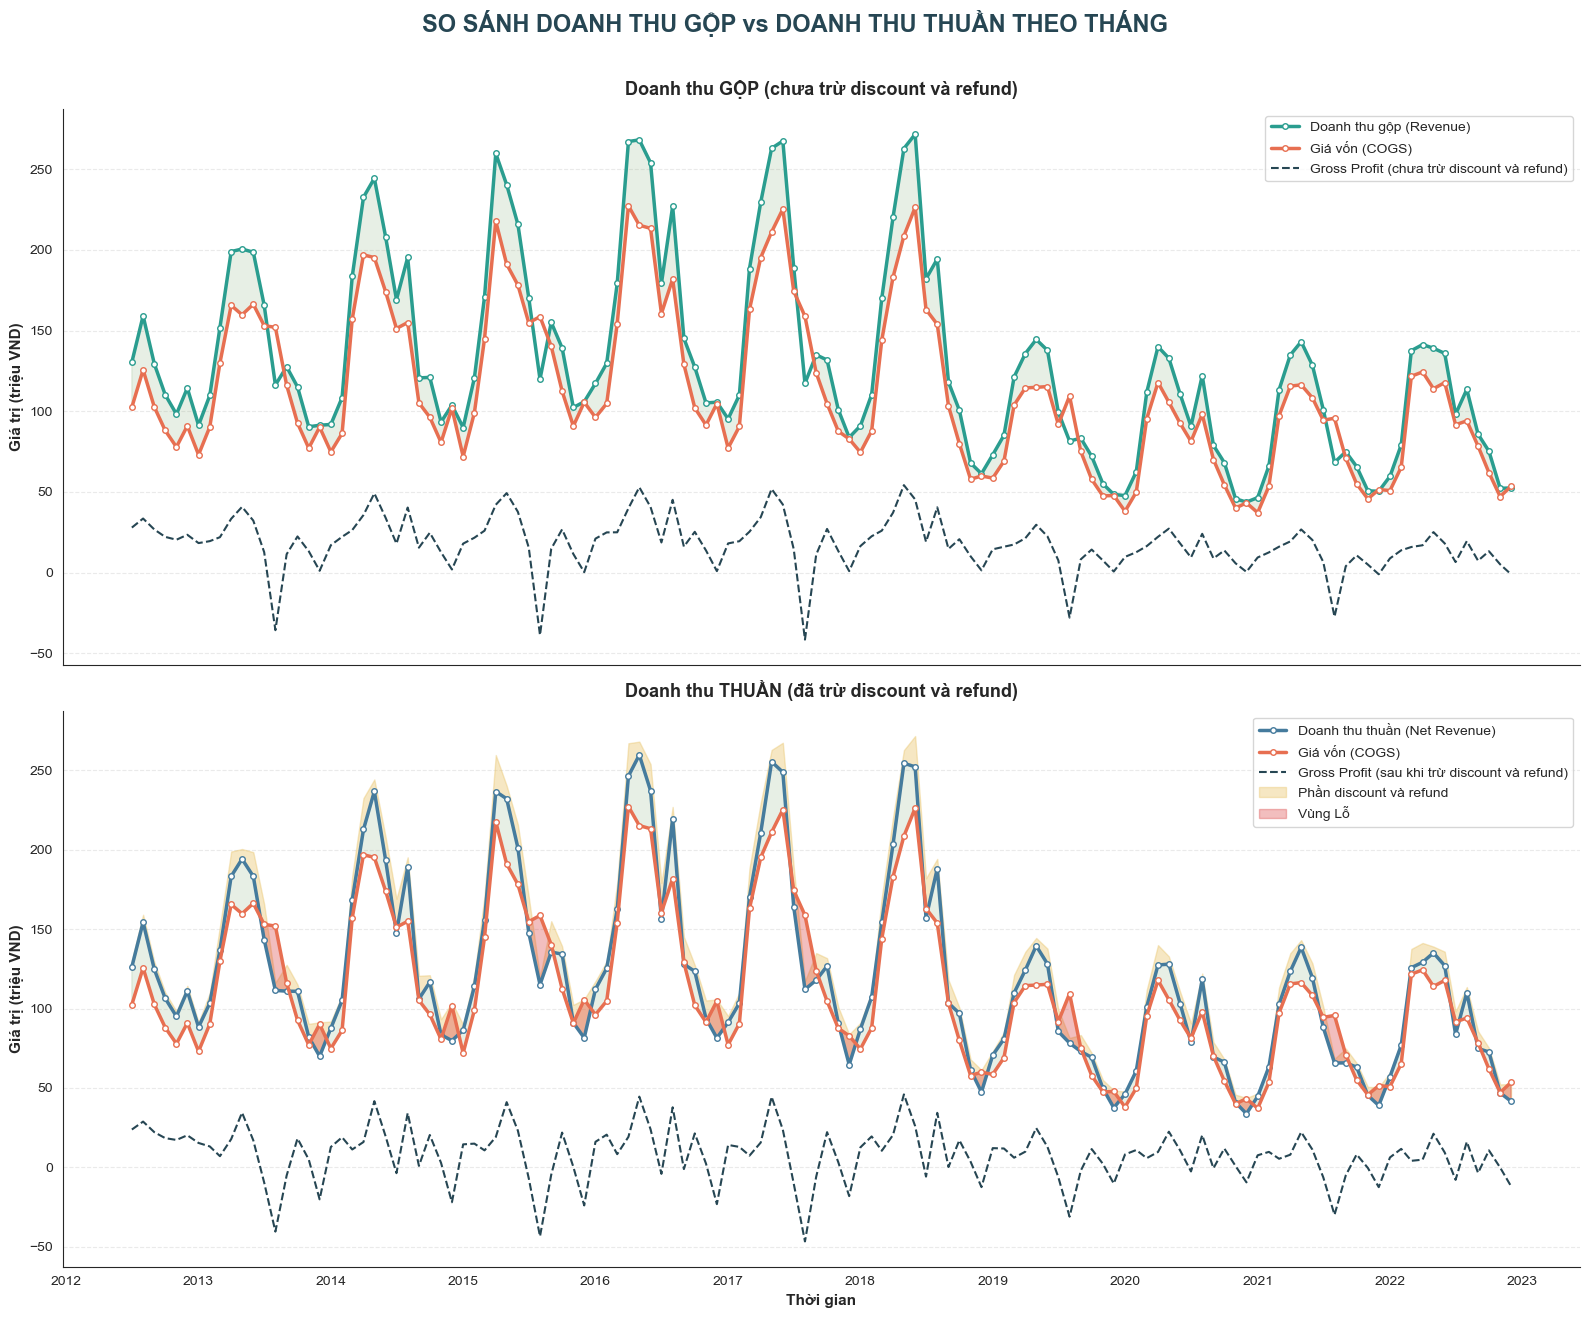

In [7]:
# Group theo tháng
df_monthly = sales_full.resample('MS', on='Date').agg({
    'Revenue': 'sum',
    'Net_Revenue': 'sum',
    'COGS': 'sum',
    'Total_Discount': 'sum',
    'Gross_Profit': 'sum'
}).reset_index()

# ================================= BẢNG MÀU =================================
color_rev      = '#2a9d8f'
color_net      = '#457b9d'
color_cogs     = '#e76f51'
color_profit   = '#264653'
color_discount = '#e9c46a'
color_fill_pos = '#8ab17d'
color_fill_neg = '#d62828'

sns.set_style("white")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 13), dpi=100, sharex=True)
fig.suptitle('SO SÁNH DOANH THU GỘP vs DOANH THU THUẦN THEO THÁNG',
             fontsize=17, fontweight='bold', color='#264653', y=1.01)

# =============== BIỂU ĐỒ TRÊN: Doanh thu gộp (Revenue gốc) ==================
ax1.plot(df_monthly['Date'], df_monthly['Revenue']/1e6,
         color=color_rev, linewidth=2.5, label='Doanh thu gộp (Revenue)',
         marker='o', markersize=4, markerfacecolor='white', markeredgewidth=1)
ax1.plot(df_monthly['Date'], df_monthly['COGS']/1e6,
         color=color_cogs, linewidth=2.5, label='Giá vốn (COGS)',
         marker='o', markersize=4, markerfacecolor='white', markeredgewidth=1)
ax1.plot(df_monthly['Date'], (df_monthly['Revenue'] - df_monthly['COGS'])/1e6,
         color=color_profit, linewidth=1.5, label='Gross Profit (chưa trừ discount và refund)',
         linestyle='--')
ax1.fill_between(df_monthly['Date'], df_monthly['COGS']/1e6, df_monthly['Revenue']/1e6,
                 where=(df_monthly['Revenue'] >= df_monthly['COGS']),
                 interpolate=True, color=color_fill_pos, alpha=0.2)

ax1.set_title('Doanh thu GỘP (chưa trừ discount và refund)', fontsize=13, fontweight='bold', pad=10)
ax1.set_ylabel('Giá trị (triệu VND)', fontsize=11, fontweight='bold')
ax1.legend(loc='upper right', frameon=True, fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.4, axis='y')
sns.despine(ax=ax1)

# =============== BIỂU ĐỒ DƯỚI: Doanh thu thuần (Net Revenue) ================
ax2.plot(df_monthly['Date'], df_monthly['Net_Revenue']/1e6,
         color=color_net, linewidth=2.5, label='Doanh thu thuần (Net Revenue)',
         marker='o', markersize=4, markerfacecolor='white', markeredgewidth=1)
ax2.plot(df_monthly['Date'], df_monthly['COGS']/1e6,
         color=color_cogs, linewidth=2.5, label='Giá vốn (COGS)',
         marker='o', markersize=4, markerfacecolor='white', markeredgewidth=1)
ax2.plot(df_monthly['Date'], df_monthly['Gross_Profit']/1e6,
         color=color_profit, linewidth=1.5, label='Gross Profit (sau khi trừ discount và refund)',
         linestyle='--')

# Vùng discount bị khấu trừ (phần chênh lệch giữa Revenue và Net_Revenue)
ax2.fill_between(df_monthly['Date'], df_monthly['Net_Revenue']/1e6, df_monthly['Revenue']/1e6,
                 interpolate=True, color=color_discount, alpha=0.4, label='Phần discount và refund')
ax2.fill_between(df_monthly['Date'], df_monthly['COGS']/1e6, df_monthly['Net_Revenue']/1e6,
                 where=(df_monthly['Net_Revenue'] >= df_monthly['COGS']),
                 interpolate=True, color=color_fill_pos, alpha=0.2)
ax2.fill_between(df_monthly['Date'], df_monthly['COGS']/1e6, df_monthly['Net_Revenue']/1e6,
                 where=(df_monthly['Net_Revenue'] < df_monthly['COGS']),
                 interpolate=True, color=color_fill_neg, alpha=0.3, label='Vùng Lỗ')

ax2.set_title('Doanh thu THUẦN (đã trừ discount và refund)', fontsize=13, fontweight='bold', pad=10)
ax2.set_ylabel('Giá trị (triệu VND)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Thời gian', fontsize=11, fontweight='bold')
ax2.legend(loc='upper right', frameon=True, fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.4, axis='y')
sns.despine(ax=ax2)

# Định dạng trục X dùng chung
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_minor_locator(mdates.MonthLocator())
plt.xticks(rotation=0, ha='center')

plt.tight_layout()
plt.show()

- **Hiệu quả lợi nhuận thấp**: Lợi nhuận gộp (Gross Profit) biến động cực kỳ bất ổn, thường xuyên rơi xuống mức âm (đặc biệt là giai đoạn 2013-2014, 2015-2016 và 2017-2018). Xuất hiện nhiều "Vùng lỗ" (màu đỏ) do giá vốn (COGS) vượt quá doanh thu thuần.

- **Sự phụ thuộc vào chiết khấu**: Khoảng cách giữa Doanh thu Gộp và Doanh thu Thuần (phần chiết khấu/hoàn hàng) khá lớn. Doanh nghiệp có dấu hiệu dùng khuyến mãi sâu để kích cầu nhưng không kiểm soát được điểm hòa vốn.

- **Quy mô đang thu hẹp**:
  + Giai đoạn 2013 - 2018: Quy mô lớn, đỉnh doanh thu cao (trên 250 triệu).

  + Giai đoạn 2019 - 2022: Quy mô giảm mạnh, các đỉnh doanh thu thấp dần và biên lợi nhuận ngày càng mỏng.

- **Tính chu kỳ cao**: Doanh thu biến động mạnh theo tháng nhưng nhìn chung xu hướng doanh thu có chu kì khoảng 1 năm với doanh thu tăng mạnh vào nửa đầu năm và đạt đỉnh vào khoảng tháng 4-6, doanh thu giảm vào cuối năm.

$\Rightarrow$ Kết luận: Doanh nghiệp đang gặp rủi ro về mô hình kinh doanh khi chi phí vốn và chiết khấu quá cao, dẫn đến tình trạng "bán nhiều nhưng không có lãi".

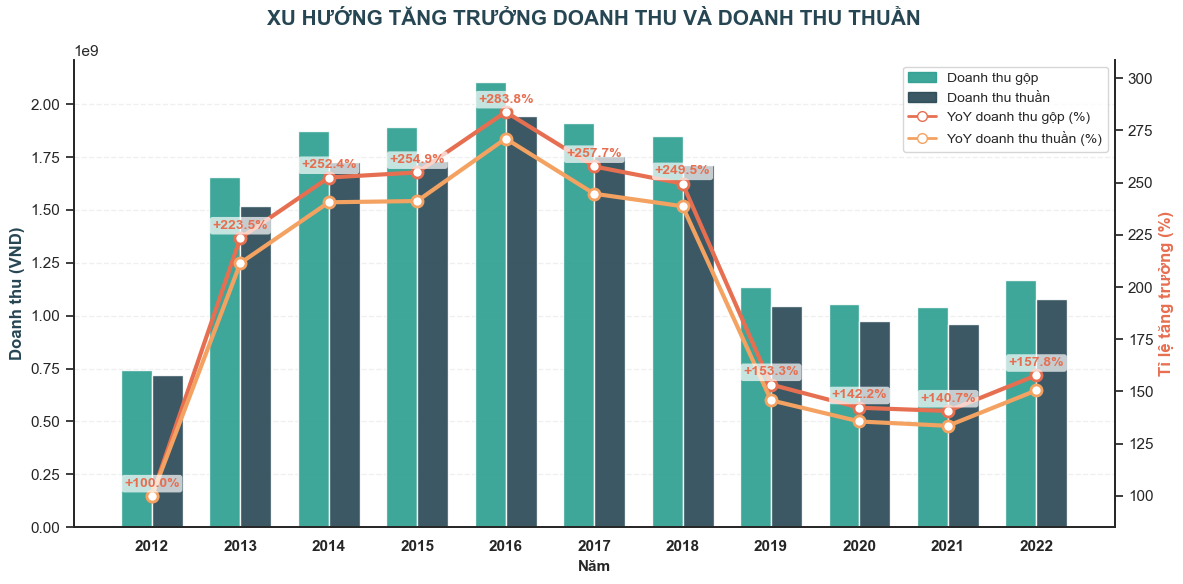

In [8]:
# ======================== Tính doanh thu theo từng năm ========================
sales_df = sales_full.copy()
sales_df['Year'] = pd.to_datetime(sales_df['Date']).dt.year
sales_df = sales_df.groupby('Year').agg({
    'Revenue':     'sum',
    'Net_Revenue': 'sum'
}).reset_index()
sales_df.rename(columns={'Revenue':     'Total_Revenue',
                         'Net_Revenue': 'Total_Net_Revenue'}, inplace=True)

# =================== Doanh thu từng năm so với năm đầu tiên(tổng thể dài hạn) ===================
beginning_revenue = sales_df['Total_Revenue'].iloc[0]
beginning_net_revenue = sales_df['Total_Net_Revenue'].iloc[0]
sales_df['YoY_Growth']     = sales_df['Total_Revenue'] / beginning_revenue * 100
sales_df['YoY_Growth_Net'] = sales_df['Total_Net_Revenue'] / beginning_net_revenue * 100

# ================================= Vẽ biểu đồ =================================
sns.set_theme(style="white")
fig, ax1 = plt.subplots(figsize=(12, 6), dpi=100)

x = np.arange(len(sales_df))
width = 0.35

color_bar     = '#2a9d8f'
color_net_rev = '#264653'
color_line     = '#e76f51'
color_line_net = '#f4a261'

# ================================= DOANH THU =================================
ax1.bar(x - width/2, sales_df['Total_Revenue'], width,
        color=color_bar, alpha=0.9)
ax1.bar(x + width/2, sales_df['Total_Net_Revenue'], width,
        color=color_net_rev, alpha=0.9)

ax1.set_ylabel('Doanh thu (VND)', fontsize=12, fontweight='bold', color='#264653')
ax1.set_xlabel('Năm', fontsize=11, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(sales_df['Year'], fontweight='bold')

# ========================== TỈ LỆ TĂNG TRƯỞNG =================================
ax2 = ax1.twinx()
ax2.plot(x, sales_df['YoY_Growth'], marker='o', markersize=8,
         color=color_line, linewidth=3, markerfacecolor='white', markeredgewidth=2)
ax2.plot(x, sales_df['YoY_Growth_Net'], marker='o', markersize=8,
         color=color_line_net, linewidth=3, markerfacecolor='white', markeredgewidth=2)

ax2.set_ylabel('Tỉ lệ tăng trưởng (%)', fontsize=12, fontweight='bold', color=color_line)
ax2.set_ylim(sales_df['YoY_Growth'].min() - 15, sales_df['YoY_Growth'].max() + 25)
ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

for i, val in enumerate(sales_df['YoY_Growth']):
    if not pd.isna(val):
        ax2.text(i, val + 3, f'{val:+.1f}%',
                 color=color_line, ha='center', va='bottom',
                 fontweight='bold', fontsize=10,
                 bbox=dict(facecolor='white', alpha=0.7,
                           edgecolor='none', boxstyle='round,pad=0.2'))

# Legend
handles = [
    mpatches.Patch(color=color_bar, alpha=0.9, label='Doanh thu gộp'),
    mpatches.Patch(color=color_net_rev, alpha=0.9, label='Doanh thu thuần'),
    mlines.Line2D([], [], color=color_line, marker='o', markersize=7,
                  markerfacecolor='white', linewidth=2, label='YoY doanh thu gộp (%)'),
    mlines.Line2D([], [], color=color_line_net, marker='o', markersize=7,
                  markerfacecolor='white', linewidth=2, label='YoY doanh thu thuần (%)')
]
ax1.legend(handles=handles, loc='upper right', frameon=True, fontsize=10)

sns.despine(right=False)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
plt.title('XU HƯỚNG TĂNG TRƯỞNG DOANH THU VÀ DOANH THU THUẦN',
          fontsize=15, fontweight='bold', pad=25, color='#264653')

plt.tight_layout()
plt.show()

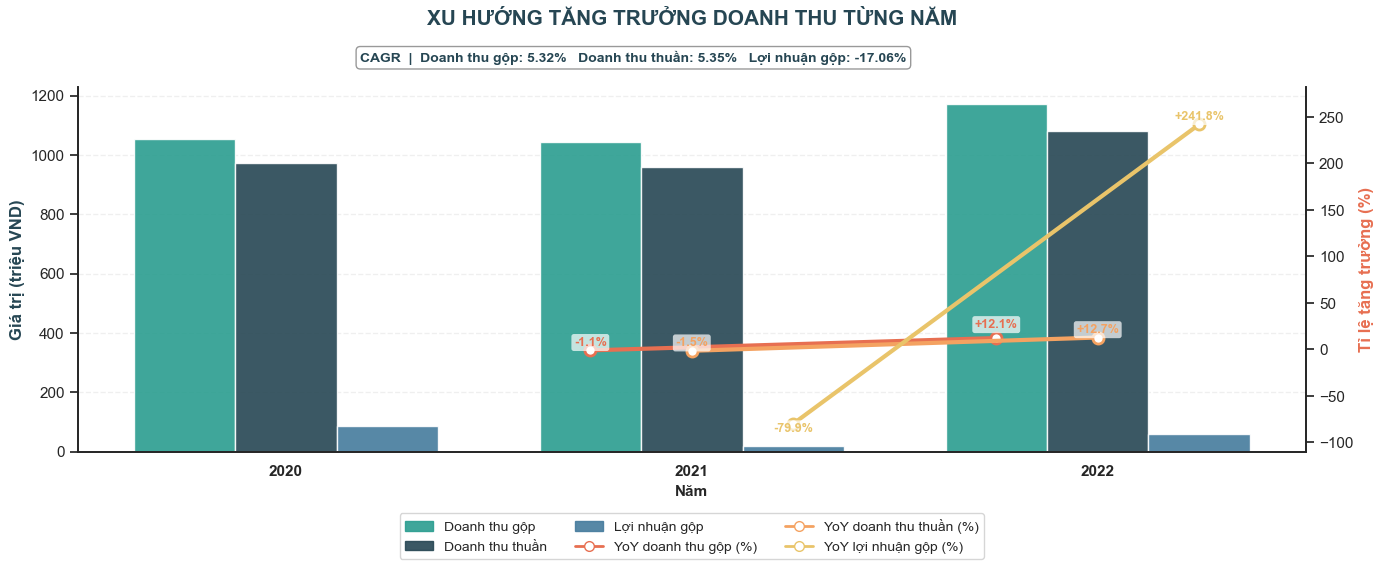

In [9]:
# ====================== Gộp doanh thu gộp + thuần + lợi nhuận gộp ========================
sales_after_2020 = sales_full[sales_full['Date'] >= '2020-01-01'].copy()
sales_after_2020['Year'] = pd.to_datetime(sales_after_2020['Date']).dt.year
sales_after_2020 = sales_after_2020.groupby('Year').agg({
    'Revenue':     'sum',
    'Net_Revenue': 'sum',
    'Gross_Profit':'sum'
}).reset_index()

sales_after_2020.rename(columns={
    'Revenue':     'Total_Revenue',
    'Net_Revenue': 'Total_Net_Revenue',
    'Gross_Profit':'Total_Gross_Profit'
}, inplace=True)

sales_after_2020['YoY_Revenue']     = sales_after_2020['Total_Revenue'].pct_change() * 100
sales_after_2020['YoY_Net_Revenue'] = sales_after_2020['Total_Net_Revenue'].pct_change() * 100
sales_after_2020['YoY_Gross_Profit']= sales_after_2020['Total_Gross_Profit'].pct_change() * 100

# ====================== Tính CAGR ========================
def calculate_cagr(data, value_col, start_year, end_year):
  start_value = data.loc[data['Year'] == start_year, value_col].values[0]
  end_value = data.loc[data['Year'] == end_year, value_col].values[0]

  n = end_year - start_year
  cagr_total = (end_value / start_value) ** (1 / n) - 1
  return cagr_total

# ==================================== CAGR ====================================
cagr_revenue     = calculate_cagr(sales_after_2020, 'Total_Revenue',     2020, 2022)
cagr_net_revenue = calculate_cagr(sales_after_2020, 'Total_Net_Revenue', 2020, 2022)
cagr_gross_profit= calculate_cagr(sales_after_2020, 'Total_Gross_Profit',2020, 2022)

# ================================= Vẽ biểu đồ =================================
sns.set_theme(style="white")
fig, ax1 = plt.subplots(figsize=(14, 6), dpi=100)

x     = np.arange(len(sales_after_2020))
width = 0.25

color_revenue      = '#2a9d8f'
color_net_revenue  = '#264653'
color_gross_profit = '#457b9d'
color_line_rev     = '#e76f51'
color_line_net     = '#f4a261'
color_line_profit  = '#e9c46a'

# ================================= BAR =================================
ax1.bar(x - width, sales_after_2020['Total_Revenue']/1e6,      width, color=color_revenue,      alpha=0.9, label='Doanh thu gộp')
ax1.bar(x,         sales_after_2020['Total_Net_Revenue']/1e6,  width, color=color_net_revenue,  alpha=0.9, label='Doanh thu thuần')
ax1.bar(x + width, sales_after_2020['Total_Gross_Profit']/1e6, width, color=color_gross_profit, alpha=0.9, label='Lợi nhuận gộp')

ax1.set_ylabel('Giá trị (triệu VND)', fontsize=12, fontweight='bold', color='#264653')
ax1.set_xlabel('Năm', fontsize=11, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(sales_after_2020['Year'], fontweight='bold')

# ================================= LINE YoY =================================
ax2 = ax1.twinx()

def plot_yoy_line(ax, x_offset, yoy_col, color, label, label_offsets=None):
    vals = sales_after_2020[yoy_col]
    ax.plot(x + x_offset, vals, marker='o', markersize=8,
            color=color, linewidth=3, markerfacecolor='white', markeredgewidth=2, label=label)

    for i, val in enumerate(vals):
        if pd.isna(val):
            continue
        dx, dy = (label_offsets or {}).get(i, (0, 2))
        ax.text(i + x_offset + dx, val + dy, f'{val:+.1f}%',
                color=color, ha='center', va='bottom',
                fontweight='bold', fontsize=9,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

plot_yoy_line(ax2, -width, 'YoY_Revenue',      color_line_rev,
              'YoY doanh thu gộp (%)',
              label_offsets={1: (0, 2), 2: (0, 8)})

plot_yoy_line(ax2,  0,     'YoY_Net_Revenue',  color_line_net,
              'YoY doanh thu thuần (%)',
              label_offsets={1: (0, 2), 2: (0, 2)})

plot_yoy_line(ax2, +width, 'YoY_Gross_Profit', color_line_profit,
              'YoY lợi nhuận gộp (%)',
              label_offsets={1: (0, -12),
                             2: (0, 2)})
all_yoy = pd.concat([
    sales_after_2020['YoY_Revenue'],
    sales_after_2020['YoY_Net_Revenue'],
    sales_after_2020['YoY_Gross_Profit']
]).dropna()
ax2.set_ylim(all_yoy.min() - 30, all_yoy.max() + 40)
ax2.set_ylabel('Tỉ lệ tăng trưởng (%)', fontsize=12, fontweight='bold', color=color_line_rev)

# ================================= LEGEND =================================
handles_bar = [
    mpatches.Patch(color=color_revenue,      alpha=0.9, label='Doanh thu gộp'),
    mpatches.Patch(color=color_net_revenue,  alpha=0.9, label='Doanh thu thuần'),
    mpatches.Patch(color=color_gross_profit, alpha=0.9, label='Lợi nhuận gộp'),
]
handles_line = [
    mlines.Line2D([], [], color=color_line_rev,    marker='o', markersize=7,
                  markerfacecolor='white', linewidth=2, label='YoY doanh thu gộp (%)'),
    mlines.Line2D([], [], color=color_line_net,    marker='o', markersize=7,
                  markerfacecolor='white', linewidth=2, label='YoY doanh thu thuần (%)'),
    mlines.Line2D([], [], color=color_line_profit, marker='o', markersize=7,
                  markerfacecolor='white', linewidth=2, label='YoY lợi nhuận gộp (%)'),
]
ax1.legend(handles=handles_bar + handles_line,
           loc='upper center', bbox_to_anchor=(0.5, -0.15),
           ncol=3, frameon=True, fontsize=10)

# ================================= TITLE & CAGR =================================
sns.despine(right=False)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
plt.title('XU HƯỚNG TĂNG TRƯỞNG DOANH THU TỪNG NĂM',
          fontsize=15, fontweight='bold', pad=45, color='#264653')

plt.text(
    0.23, 1.1,
    f"CAGR  |  Doanh thu gộp: {cagr_revenue:.2%}   Doanh thu thuần: {cagr_net_revenue:.2%}   Lợi nhuận gộp: {cagr_gross_profit:.2%}",
    transform=plt.gca().transAxes,
    fontsize=10, verticalalignment='top', weight='bold', color='#264653',
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.4)
)

plt.tight_layout()
plt.show()

In [10]:
def plot_stl_decomposition(df_sales, option='Net_Revenue'):
    """
    STL Decomposition: tách Revenue thành 3 thành phần
    -> Trả lời: Revenue tăng/giảm do TREND hay SEASONALITY?
    """
    ts_raw = df_sales.set_index('Date')[option].asfreq('D').fillna(0)
    ts = ts_raw / 1e6

    stl = STL(ts, period=365, robust=True)
    result = stl.fit()

    sns.set_style("white")
    fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True, dpi=100)
    fig.suptitle('PHÂN TÍCH CẤU TRÚC DOANH THU (STL DECOMPOSITION)',
                 fontsize=16, fontweight='bold', color='#264653', y=1.02)

    components = [
        (ts,              'OBSERVED: Doanh thu thực tế',   '#2a9d8f'),
        (result.trend,    'TREND: Xu hướng dài hạn',       '#e76f51'),
        (result.seasonal, 'SEASONAL: Tính chu kỳ mùa vụ', '#e9c46a'),
        (result.resid,    'RESIDUAL: Nhiễu hệ thống',      '#888888'),
    ]

    def annotate_peak_trough(ax, data, color, panel_idx):
        peak_idx   = data.idxmax()
        trough_idx = data.idxmin()
        peak_val   = data.max()
        trough_val = data.min()

        vert_offset_peak   = (+30, +15)[panel_idx == 2]
        vert_offset_trough = (-30, -15)[panel_idx == 2]
        arrow_kw = dict(arrowstyle='->', lw=1.2)

        ax.scatter(peak_idx, peak_val, color='#d62828', s=60, zorder=6, marker='^')
        ax.annotate(
            f'Đỉnh: {peak_idx.strftime("%m/%Y")}\n({peak_val:.1f}M)',
            xy=(peak_idx, peak_val),
            xytext=(20, vert_offset_peak),
            textcoords='offset points',
            fontsize=9, fontweight='bold', color='#d62828',
            arrowprops={**arrow_kw, 'color': '#d62828'},
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#d62828', alpha=0.8)
        )

        if panel_idx != 3:
            ax.scatter(trough_idx, trough_val, color='#1d3d8f', s=60, zorder=6, marker='v')
            ax.annotate(
                f'Đáy: {trough_idx.strftime("%m/%Y")}\n({trough_val:.1f}M)',
                xy=(trough_idx, trough_val),
                xytext=(20, vert_offset_trough),
                textcoords='offset points',
                fontsize=9, fontweight='bold', color='#1d3d8f',
                arrowprops={**arrow_kw, 'color': '#1d3d8f'},
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#1d3d8f', alpha=0.8)
            )

        if panel_idx == 3:
            sigma = data.std()
            ax.axhline(+2*sigma, color='#d62828', lw=1, ls='--', alpha=0.6,
                       label=f'+2σ = {2*sigma:.1f}M')
            ax.axhline(-2*sigma, color='#1d3d8f', lw=1, ls='--', alpha=0.6,
                       label=f'-2σ = {-2*sigma:.1f}M')
            ax.legend(fontsize=8, loc='upper right', framealpha=0.7)

    for i, (ax, (data, title, color)) in enumerate(zip(axes, components)):
        ax.plot(data.index, data.values, color=color, linewidth=1.5, alpha=0.9)
        ax.fill_between(data.index, data.values, color=color, alpha=0.1)
        ax.set_title(title, loc='left', fontsize=12, fontweight='bold', color='#264653')
        ax.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.2)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('#444444')
            spine.set_linewidth(0.8)
        ax.grid(axis='y', linestyle='--', alpha=0.3)

        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))

        annotate_peak_trough(ax, data, color, panel_idx=i)

    axes[-1].set_xlabel('Thời gian (Năm)', fontweight='bold', fontsize=11)
    plt.xticks(rotation=0, ha='center')
    plt.tight_layout()
    plt.show()

    # --- Kết luận định lượng  ---
    trend_pct_change   = (result.trend.iloc[-1] - result.trend.iloc[0]) / result.trend.iloc[0] * 100
    seasonal_amplitude = result.seasonal.max() - result.seasonal.min()
    noise_ratio        = result.resid.std() / ts.std() * 100

    print(f"{'='*50}")
    print(f"{'KẾT QUẢ PHÂN TÍCH STL':^50}")
    print(f"{'='*50}")
    print(f"- Xu hướng (Trend):     {trend_pct_change:+.1f}% (Toàn giai đoạn)")
    print(f"- Biên độ mùa vụ:       {seasonal_amplitude:.1f} Triệu VND")
    print(f"- Độ nhiễu (Residual):  {noise_ratio:.1f}%")

    if noise_ratio > 30:
        print("CẢNH BÁO: Độ nhiễu cao, doanh thu biến động thất thường khó dự báo.")
    else:
        print("TIN CẬY: Dữ liệu có tính quy luật tốt, phù hợp để lập kế hoạch tồn kho.")
    print(f"{'='*50}")

    return result

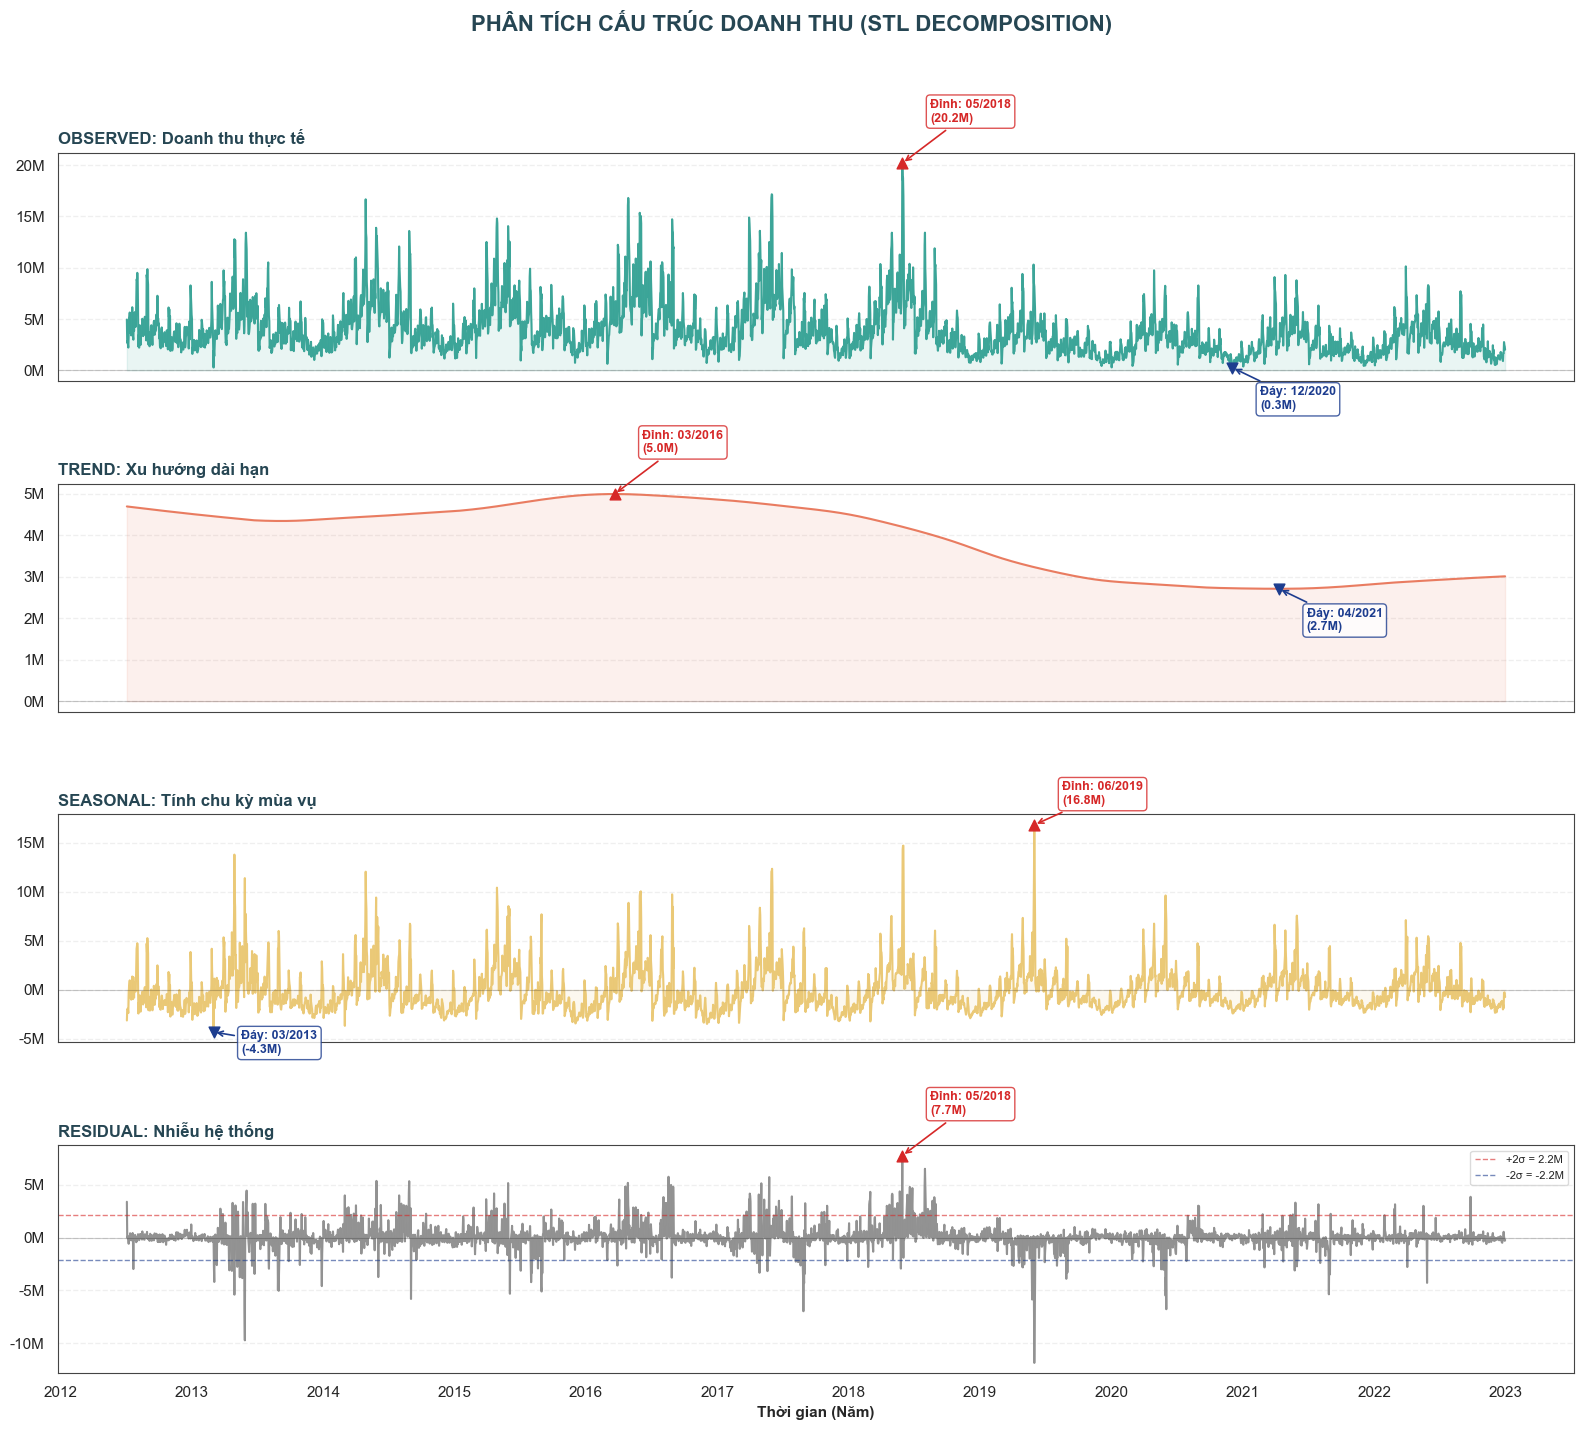

              KẾT QUẢ PHÂN TÍCH STL               
- Xu hướng (Trend):     -35.9% (Toàn giai đoạn)
- Biên độ mùa vụ:       21.1 Triệu VND
- Độ nhiễu (Residual):  43.3%
CẢNH BÁO: Độ nhiễu cao, doanh thu biến động thất thường khó dự báo.


In [11]:
# Doanh thu thuần
result = plot_stl_decomposition(sales_full, option='Net_Revenue')

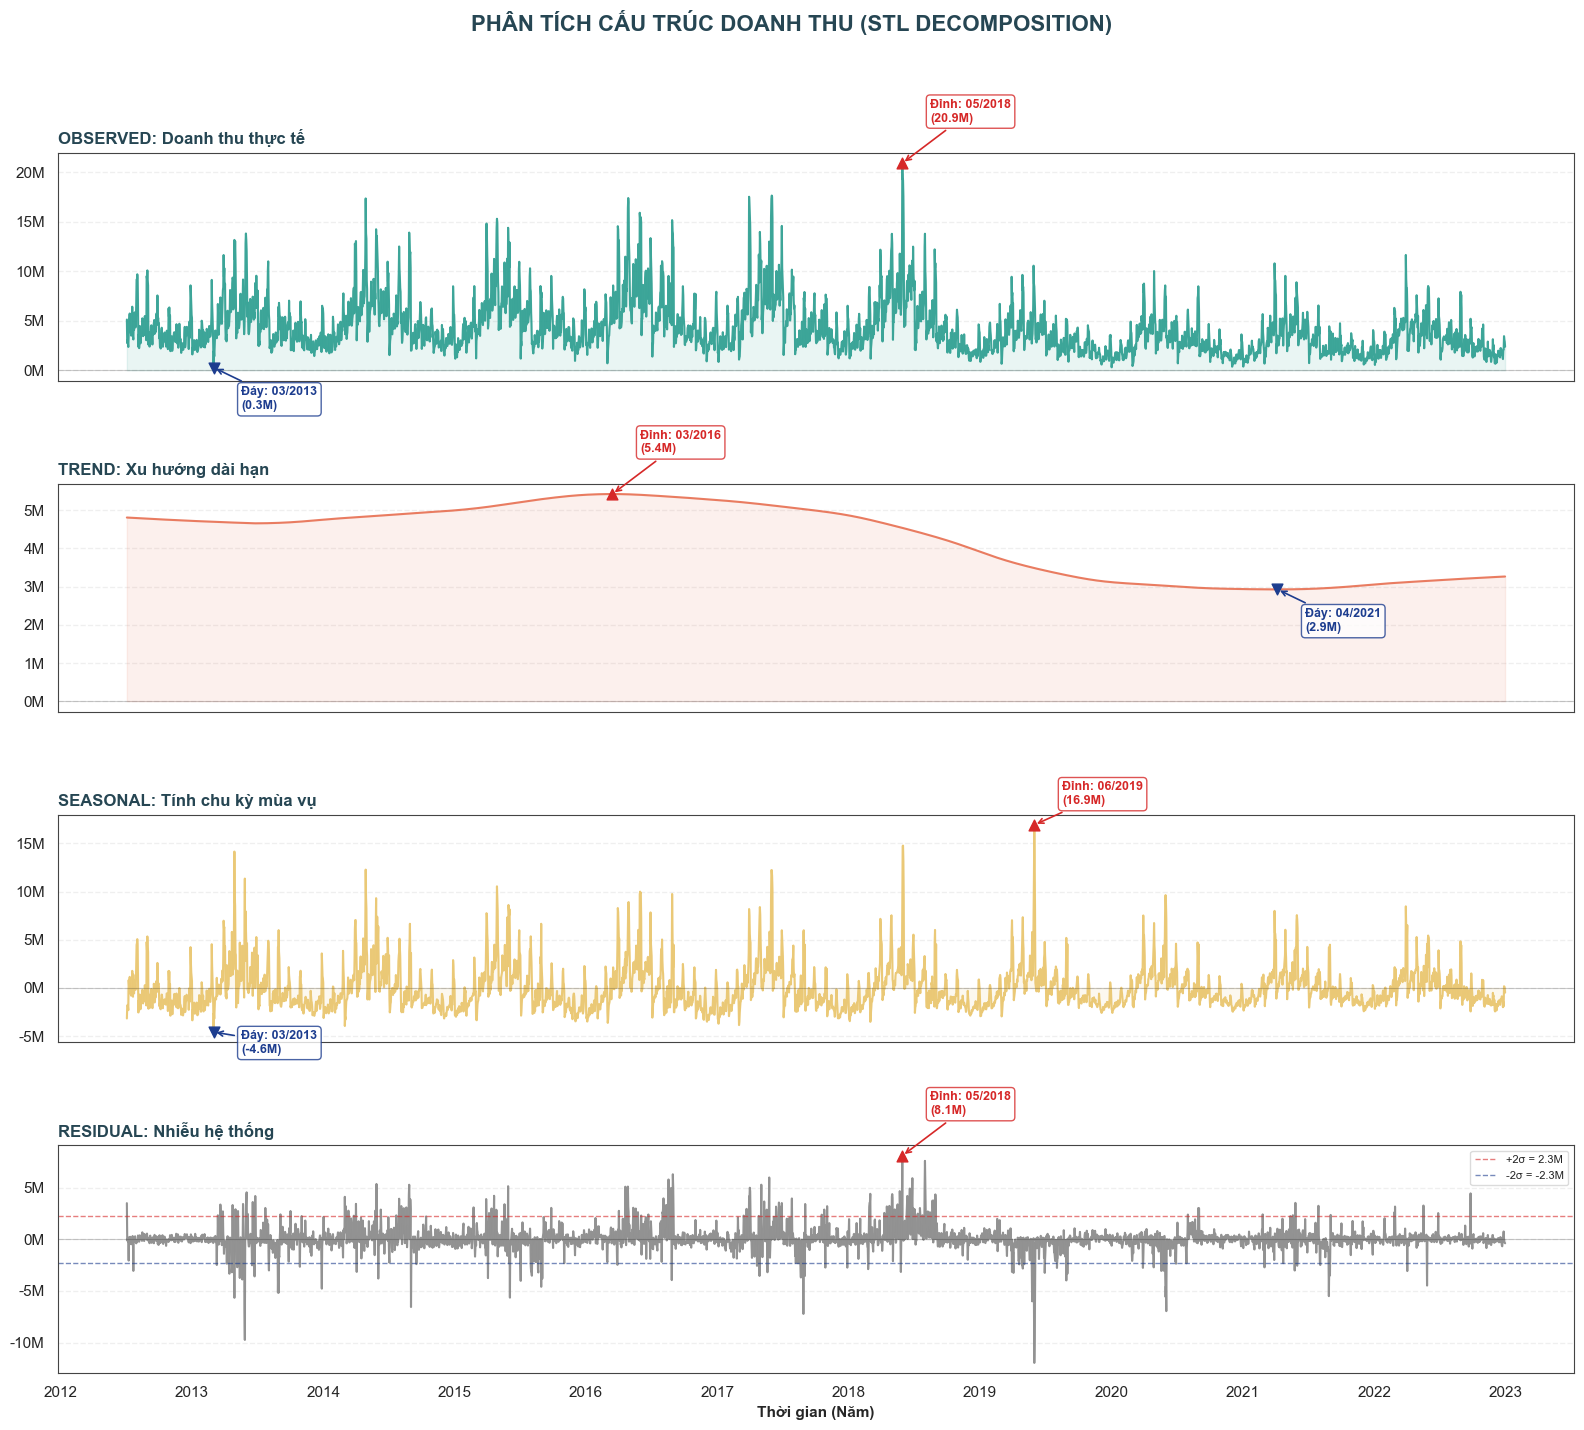

              KẾT QUẢ PHÂN TÍCH STL               
- Xu hướng (Trend):     -32.1% (Toàn giai đoạn)
- Biên độ mùa vụ:       21.5 Triệu VND
- Độ nhiễu (Residual):  43.1%
CẢNH BÁO: Độ nhiễu cao, doanh thu biến động thất thường khó dự báo.


In [12]:
# Doanh thu gộp
result = plot_stl_decomposition(sales_full, option='Revenue')

- Phân tích các thành phần:

  + Observed (Thực tế): Dữ liệu gốc có rất nhiều "gai" nhọn. Điều này cho thấy doanh thu biến động cực mạnh theo thời gian ngắn.

  + Trend (Xu hướng dài hạn): Đỉnh: 03/2016. Sau đỉnh này, xu hướng giảm khá mạnh cho đến năm 2020 rồi mới có dấu hiệu đi ngang và hồi phục nhẹ.

  + Seasonal (Mùa vụ): Biểu đồ cho thấy tính chu kỳ rất đều đặn. Cứ đến một thời điểm nhất định trong năm, doanh thu lại tăng vọt lên (các cột nhọn hoắt).

  + Residual (Nhiễu): Các điểm biến động không theo quy luật. Có một điểm rơi rất sâu vào khoảng năm 2019 (có thể là một sự cố kinh doanh hoặc dữ liệu bất thường)

- Trend dài hạn: -35.9%: Đây là một dấu hiệu cần lưu ý. Tổng thể từ đầu giai đoạn đến cuối giai đoạn, doanh thu thuần đang có xu hướng giảm hơn 30%. Đỉnh cao nhất là năm 2016 và hiện tại chưa quay lại được mức đó.

- Biên độ mùa vụ: 21.6 triệu VND: Sự chênh lệch giữa tháng cao điểm nhất và thấp điểm nhất do yếu tố mùa vụ là rất lớn. Điều này giúp lập kế hoạch kho bãi hoặc nhân sự: cần chuẩn bị nguồn lực cực lớn cho các tháng "đỉnh" vì nó cao hơn mức trung bình rất nhiều.

- Tỉ lệ nhiễu: 43.2%: Con số này hơi cao, có nghĩa là 43.2% biến động doanh thu là ngẫu nhiên, không giải thích được bằng quy luật thời gian hay mùa vụ.

-> Hệ quả: Việc dự báo doanh số trong tương lai sẽ có độ sai lệch khá lớn.

In [13]:
def plot_seasonality_profile(df_sales):
    """
    Heatmap doanh thu trung bình theo tuần × năm
    -> Cho thấy pattern mùa vụ nào lặp lại nhất quán
    """
    df = df_sales.copy()
    df['week'] = df['Date'].dt.isocalendar().week.astype(int)
    df['year'] = df['Date'].dt.year

    pivot = df.pivot_table(
        values='Net_Revenue', index='week', columns='year', aggfunc='mean'
    ) / 1e6

    fig, ax = plt.subplots(figsize=(16, 8))
    sns.heatmap(pivot,
                annot=False,
                cmap='YlGnBu',
                linewidths=.3,
                linecolor='#f0f0f0',
                cbar_kws={'label': 'Doanh thu thuần TB (triệu VND)'},
                ax=ax)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=0)
    ax.set_yticks(range(0, len(pivot.index), 4))
    ax.set_yticklabels([f'W{w}' for w in pivot.index[::4]], rotation=0)
    ax.set_xlabel('Năm', fontweight='bold')
    ax.set_ylabel('Tuần trong năm', fontweight='bold')
    ax.set_title('Heatmap Doanh thu thuần trung bình theo Tuần × Năm (triệu VND)',
                 fontsize=13, fontweight='bold', pad=15)

    plt.tight_layout()
    plt.show()

    # Xác định tuần cao điểm nhất quán
    weekly_mean = pivot.mean(axis=1)
    top_weeks = weekly_mean.nlargest(5)
    print("\nTop 5 tuần cao điểm (trung bình qua các năm):")
    for week, val in top_weeks.items():
        print(f"   Tuần {week:2d}: {val:.1f} triệu VND TB/ngày")

    # Tuần thấp điểm nhất
    bot_weeks = weekly_mean.nsmallest(5)
    print("\nTop 5 tuần thấp điểm (trung bình qua các năm):")
    for week, val in bot_weeks.items():
        print(f"   Tuần {week:2d}: {val:.1f} triệu VND TB/ngày")

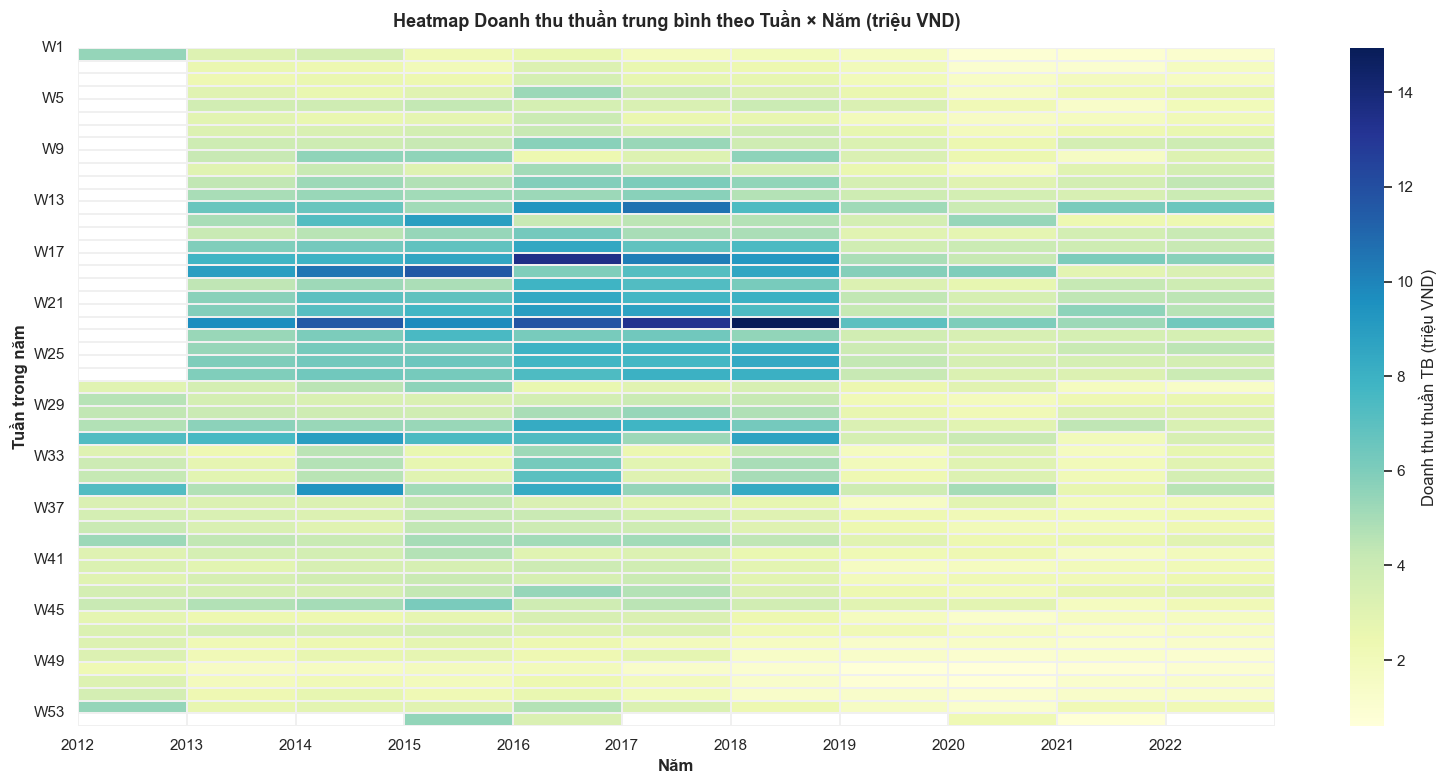


Top 5 tuần cao điểm (trung bình qua các năm):
   Tuần 22: 9.6 triệu VND TB/ngày
   Tuần 17: 7.8 triệu VND TB/ngày
   Tuần 18: 7.1 triệu VND TB/ngày
   Tuần 13: 6.8 triệu VND TB/ngày
   Tuần 21: 6.4 triệu VND TB/ngày

Top 5 tuần thấp điểm (trung bình qua các năm):
   Tuần 49: 1.3 triệu VND TB/ngày
   Tuần 50: 1.7 triệu VND TB/ngày
   Tuần 47: 2.0 triệu VND TB/ngày
   Tuần 51: 2.0 triệu VND TB/ngày
   Tuần 48: 2.0 triệu VND TB/ngày


In [14]:
plot_seasonality_profile(sales_full)

- Tính mùa vụ cực kỳ nhất quán: Điểm rơi doanh thu tập trung hoàn toàn vào Quý 2 (từ Tuần 13 đến Tuần 26). Đây là "mùa gặt" duy nhất trong năm.

  + Đỉnh nhọn: Tuần 22 là thời điểm vàng, cần dồn toàn bộ nguồn lực (hàng hóa, marketing, nhân sự) vào giai đoạn này để tối ưu lợi nhuận.

- Xu hướng suy giảm dài hạn: Dải màu xanh đậm (doanh thu cao) đang thưa dần và nhạt đi rõ rệt từ sau năm 2018.

  + Thực tế: Ngay cả trong mùa cao điểm, sức mua những năm gần đây đang yếu đi so với quá khứ (khớp với con số trend giảm -35.9%).

- Hiệu quả khai thác cuối năm kém: Toàn bộ nửa cuối năm (từ tháng 9 đến tháng 12) doanh thu rất thấp và không có đột biến.

  + Hành động: Cần xem xét lại việc duy trì chi phí cố định cao vào cuối năm, hoặc phải tìm kiếm dòng sản phẩm mới để "lấp đầy" khoảng trống doanh thu này.

## **PHÂN TÍCH HIỆU QUẢ CỦA CÁC CHIẾN DỊCH KHUYẾN MÃI**

In [15]:
# Chuẩn bị promotions
promotions['duration_days'] = (promotions['end_date'] - promotions['start_date']).dt.days
promotions['year']          = promotions['start_date'].dt.year
promotions['campaign_type'] = promotions['promo_name'].str.replace(r'\d+', '', regex=True).str.strip()

# Tính doanh thu từng item theo promo
df_promo = (
    order_items
    .merge(orders[['order_id', 'order_date']], on='order_id')
    .merge(returns[['order_id', 'product_id', 'refund_amount']], on=['order_id', 'product_id'], how='left')
    .merge(promotions[['promo_id', 'campaign_type', 'duration_days', 'year']],
           on='promo_id', how='inner')   # inner: chỉ lấy item có KM
)
df_promo['refund_amount'] = df_promo['refund_amount'].fillna(0)

df_promo['order_date']        = pd.to_datetime(df_promo['order_date'])
df_promo['gross_revenue_item'] = df_promo['quantity'] * df_promo['unit_price']
df_promo['net_revenue_item']   = (
    df_promo['gross_revenue_item']
    - df_promo['discount_amount']
    - df_promo['refund_amount']
).clip(lower=0)

# Aggregate theo campaign_type × year
campaign_performance = (
    df_promo
    .groupby(['campaign_type', 'year'])
    .agg(
        total_gross_revenue = ('gross_revenue_item', 'sum'),
        net_revenue         = ('net_revenue_item',   'sum'),
        total_discount      = ('discount_amount',    'sum'),
        duration_days       = ('duration_days',      'first'),
    )
    .reset_index()
)

campaign_performance['rev_per_day']      = campaign_performance['net_revenue'] / campaign_performance['duration_days']
campaign_performance['discount_rate']    = (
    campaign_performance['total_discount'] / campaign_performance['total_gross_revenue'] * 100
)
campaign_performance = campaign_performance.sort_values(['campaign_type', 'year'])

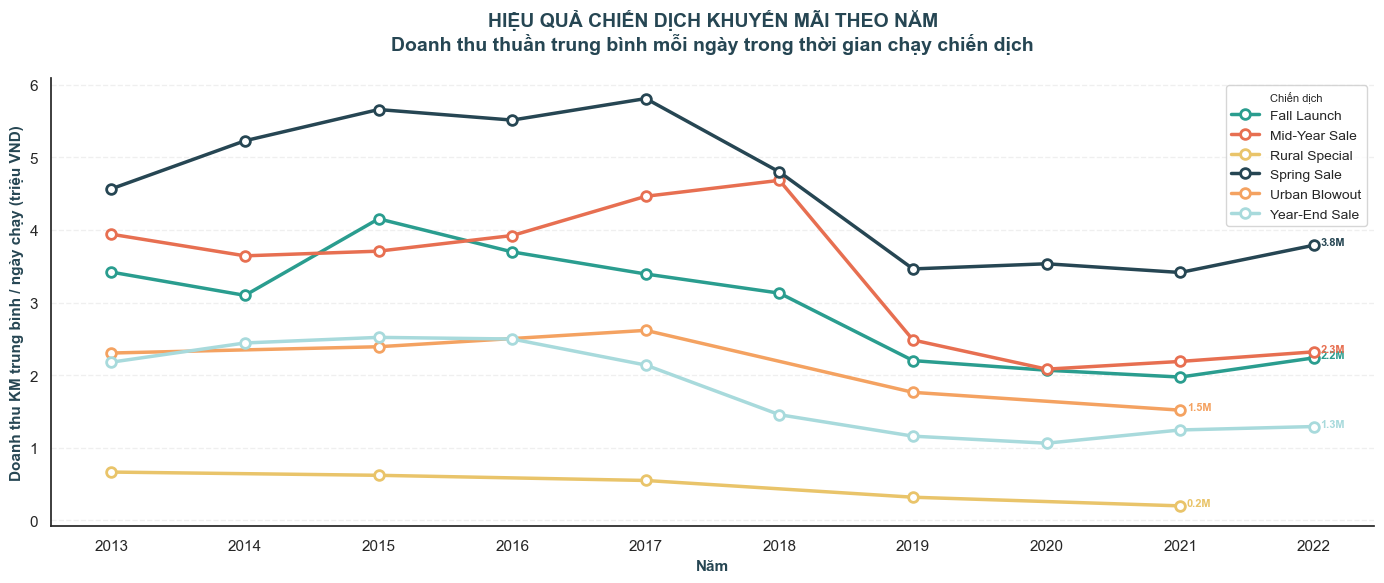

In [16]:
# =========================== Vẽ đồ thị ========================================
sns.set_style("white")
fig, ax = plt.subplots(figsize=(14, 6), dpi=100)

color_palette = ['#2a9d8f', '#e76f51', '#e9c46a', '#264653', '#f4a261', '#a8dadc']
campaigns     = campaign_performance['campaign_type'].unique()

for i, campaign in enumerate(campaigns):
    subset = campaign_performance[campaign_performance['campaign_type'] == campaign]
    color  = color_palette[i % len(color_palette)]
    ax.plot(subset['year'], subset['rev_per_day'] / 1e6,
            marker='o', markersize=7, linewidth=2.5,
            markerfacecolor='white', markeredgewidth=2,
            color=color, label=campaign)

    # Label điểm cuối
    last = subset.iloc[-1]
    ax.text(last['year'] + 0.05, last['rev_per_day'] / 1e6,
            f"{last['rev_per_day']/1e6:.1f}M",
            color=color, fontsize=8, va='baseline', fontweight='bold')

ax.set_xlabel('Năm', fontweight='bold', color='#264653', fontsize=11)
ax.set_ylabel('Doanh thu KM trung bình / ngày chạy (triệu VND)',
              fontweight='bold', color='#264653', fontsize=11)
ax.set_title('HIỆU QUẢ CHIẾN DỊCH KHUYẾN MÃI THEO NĂM\n'
             'Doanh thu thuần trung bình mỗi ngày trong thời gian chạy chiến dịch',
             fontsize=14, fontweight='bold', color='#264653', pad=20)

ax.set_xticks(campaign_performance['year'].unique())
ax.legend(loc='upper right', frameon=True, fontsize=10, title='Chiến dịch', title_fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

**Đánh giá tổng quan**
- Đa số các chiến dịch chủ lực (Spring Sale, Mid-Year Sale, Fall Launch) đều đạt đỉnh vào trong khoảng 3-5 năm xây dựng và có dấu hiệu sụt giảm mạnh sau 2018. Cho thấy thị trường đang trở nên cạnh tranh khốc liệt hơn khiến mật độ doanh thu không còn cao như trước, đòi hỏi phải thay đổi phương thức tiếp cận thay vì duy trì lối mòn
- Spring Sale là chiến dịch hiệu quả nhất(đỉnh cao đạt gần 6 triệu/ngày). Tuy đã giảm mạnh vào năm 2019 nhưng có dấu hiệu phục hồi từ năm 2021-2022
- Việc dừng chiến dịch Rural Special và Urban Blowout đã giúp tập trung nguồn lực kích thích các chiến dịch còn lại tăng trưởng trở lại(2021-2022)

**Định hướng chiến lược**
- Áp dụng các mô hình '20+10' hoặc 'Flash-Week' để tạo đột biến doanh thu vào cuối kỳ và tối ưu tỷ lệ chuyển đổi
- Vẫn tập trung đầu tư tập trung vào Spring Sale và Mid-Year Sale để giữ vững thị phần
- Khai phá Year-End Sale: tăng nhẹ ngân sách cho chiến dịch này (15-20%) vì đây là giai đoạn khách hàng có tâm lý chi tiêu mạnh

In [17]:
# Join web_traffic với sales_full
web_traffic['date'] = pd.to_datetime(web_traffic['date'])
df_web_traffic_sales = pd.merge(web_traffic, sales_full, left_on='date', right_on='Date', how='right')

# Kiểm tra xem ngày đang xét có nằm trong chiến dịch nào không
promo_dates = set()
for _, row in promotions.iterrows():
    dates = pd.date_range(row['start_date'], row['end_date'])
    promo_dates.update(dates)
df_web_traffic_sales['has_promotion'] = df_web_traffic_sales['Date'].isin(promo_dates).astype(int)

# Tính số lượng đơn trong 1 ngày
orders['order_date'] = pd.to_datetime(orders['order_date'])
df_daily_orders = orders.groupby('order_date')['order_id'].nunique().reset_index()
df_daily_orders.columns = ['date', 'order_count']
df_daily_orders['date'] = pd.to_datetime(df_daily_orders['date'])

# Join thêm bảng daily_orders và Net_Revenue
df_web_traffic_sales = pd.merge(df_web_traffic_sales, df_daily_orders, left_on='Date', right_on='date', how='left')

In [18]:
df_monthly = df_web_traffic_sales.set_index('Date').resample('MS').agg({
    'Net_Revenue': 'sum',       # Tổng doanh thu thuần tháng
    'sessions': 'sum',          # Tổng traffic tháng
    'order_count': 'sum',       # Tổng đơn hàng tháng
    'has_promotion': 'mean'     # Tỷ lệ ngày có KM trong tháng (0 đến 1)
}).reset_index()

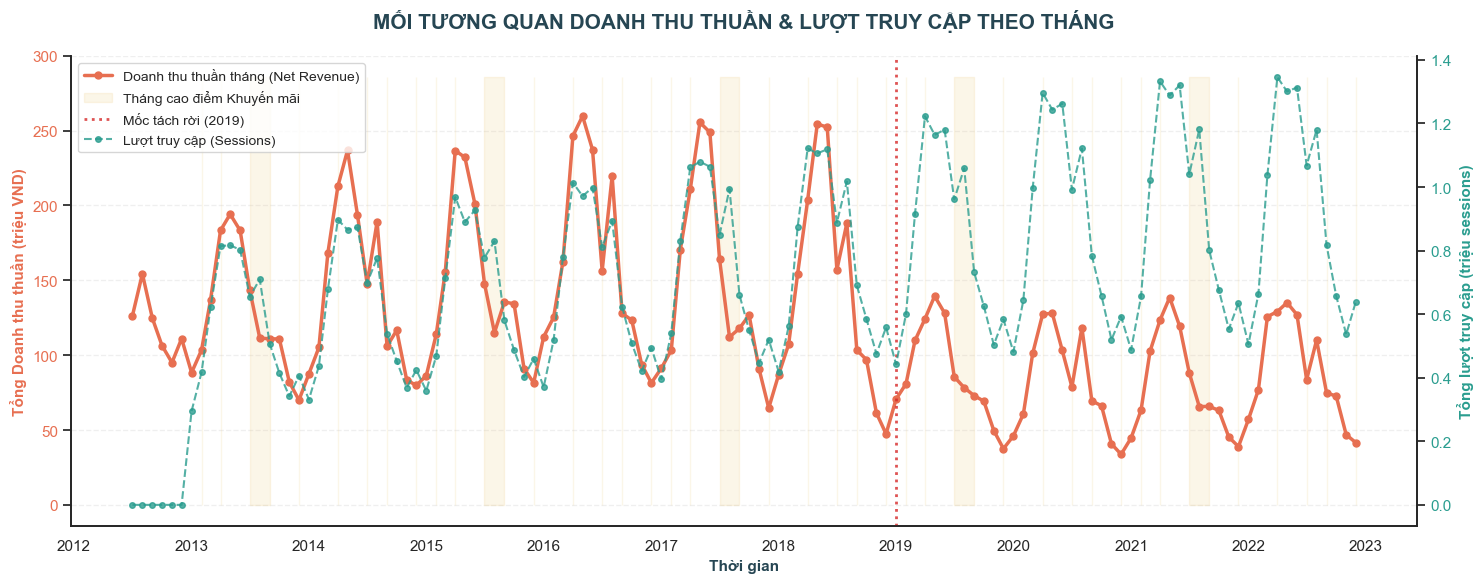

In [19]:
# Vẽ biểu đồ
sns.set_style("white")
fig, ax1 = plt.subplots(figsize=(15, 6), dpi=100)

# --- BẢNG MÀU  ---
color_rev   = '#e76f51'   # (Doanh thu)
color_ses   = '#2a9d8f'   # (Sessions)
color_promo = '#e9c46a'   # (Khuyến mãi)
color_text  = '#264653'   # (Text/Title)
color_drop  = '#d62828'   # (Mốc doanh thu giảm)

# ================= Vẽ Net Revenue (Trục trái) =================================
ax1.plot(df_monthly['Date'], df_monthly['Net_Revenue']/1e6,
         color=color_rev, marker='o', markersize=5,
         label='Doanh thu thuần tháng (Net Revenue)', linewidth=2.5, zorder=3)
ax1.set_ylabel('Tổng Doanh thu thuần (triệu VND)', color=color_rev, fontweight='bold', fontsize=11)
ax1.tick_params(axis='y', labelcolor=color_rev)

# ================= Vẽ Sessions (Trục phải) ====================================
ax2 = ax1.twinx()
ax2.plot(df_monthly['Date'], df_monthly['sessions']/1e6,
         color=color_ses, marker='o', markersize=4,
         label='Lượt truy cập (Sessions)', linewidth=1.5, alpha=0.8, linestyle='--')
ax2.set_ylabel('Tổng lượt truy cập (triệu sessions)', color=color_ses, fontweight='bold', fontsize=11)
ax2.tick_params(axis='y', labelcolor=color_ses)

# ================= Vẽ vùng Khuyến mãi =========================================
ax1.fill_between(df_monthly['Date'], 0, (df_monthly['Net_Revenue']/1e6).max() * 1.1,
                 where=(df_monthly['has_promotion'] > 0.5),
                 color=color_promo, alpha=0.15, label='Tháng cao điểm Khuyến mãi', zorder=1)

# Mốc tách rời 2019
ax1.axvline(pd.to_datetime('2019-01-01'), color=color_drop,
            linestyle=':', linewidth=2, alpha=0.8, zorder=4,
            label='Mốc tách rời (2019)')

# Định dạng trục X (Thời gian)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax1.set_xlabel('Thời gian', fontweight='bold', color=color_text, fontsize=11)

sns.despine(right=False)
ax1.grid(True, linestyle='--', alpha=0.3, axis='y')
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', frameon=True, fontsize=10)
plt.title('MỐI TƯƠNG QUAN DOANH THU THUẦN & LƯỢT TRUY CẬP THEO THÁNG',
          fontsize=15, fontweight='bold', color=color_text, pad=20)

plt.tight_layout()
plt.show()

- **Điểm gãy 2019**: Mốc 2019 đánh dấu sự thay đổi hoàn toàn về bản chất kinh doanh. Doanh nghiệp đã đánh mất khả năng biến sự quan tâm của khách hàng thành giá trị tài chính thực tế.

  + Trước 2019: Lượt truy cập và doanh thu song hành.

  + Sau 2019: Lượt truy cập tăng vọt (chạm đỉnh 1.4M) nhưng doanh thu lại lao dốc. Điều này cho thấy lượt truy cập sau 2019 có chất lượng rất thấp hoặc không đúng đối tượng mục tiêu.

- **Tỷ lệ chuyển đổi (CR) sụt giảm nghiêm trọng**: Doanh nghiệp đang tốn rất nhiều nguồn lực/chi phí để kéo khách vào (Marketing) nhưng lại thất bại trong việc chốt đơn (Vận hành/Sản phẩm). Khách chỉ "xem" chứ không "mua".

- **Khuyến mãi không hiệu quả**: Các tháng cao điểm khuyến mãi (vùng vàng) sau năm 2019 vẫn tạo ra đỉnh truy cập nhưng không còn tạo ra đỉnh doanh thu tương xứng như giai đoạn trước.

$\Rightarrow$ Kết luận: Chiến lược kéo traffic hiện tại đang vô nghĩa về mặt tài chính. Cần kiểm tra ngay chất lượng nguồn quảng cáo và tỷ lệ chuyển đổi trên website/sàn.

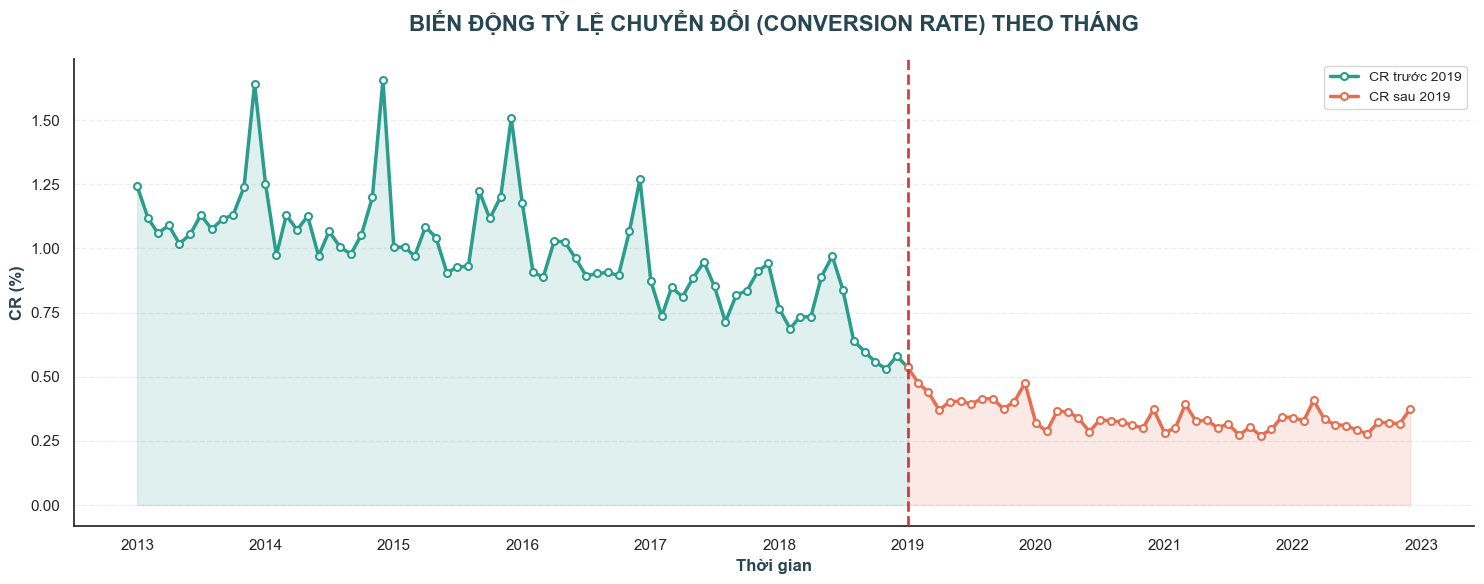

In [20]:
# Tính toán CR
df_monthly['CR'] = (df_monthly['order_count'] / df_monthly['sessions']) * 100

sns.set_style("white")
plt.figure(figsize=(15, 6), dpi=100)

# --- BẢNG MÀU ĐỒNG BỘ ---
color_before = '#2a9d8f'  # (Trước 2019 — giai đoạn tăng trưởng)
color_after  = '#e76f51'  # (Sau 2019 — giai đoạn suy giảm)
color_line   = '#264653'  # (Text/Title)
color_event  = '#d62828'  # (Mốc 2019)

cutoff = pd.to_datetime('2019-01-01')
df_before = df_monthly[df_monthly['Date'] <= cutoff]
df_after  = df_monthly[df_monthly['Date'] >= cutoff]

# Vùng tô màu trước 2019
plt.fill_between(df_before['Date'], df_before['CR'],
                 color=color_before, alpha=0.15)
plt.plot(df_before['Date'], df_before['CR'],
         color=color_before, marker='o', markersize=5,
         markerfacecolor='white', markeredgewidth=1.5,
         linewidth=2.5, label='CR trước 2019')

# Vùng tô màu sau 2019
plt.fill_between(df_after['Date'], df_after['CR'],
                 color=color_after, alpha=0.15)
plt.plot(df_after['Date'], df_after['CR'],
         color=color_after, marker='o', markersize=5,
         markerfacecolor='white', markeredgewidth=1.5,
         linewidth=2.5, label='CR sau 2019')

# Mốc 2019
plt.axvline(cutoff, color=color_event, linestyle='--', linewidth=2, alpha=0.9, zorder=4)

plt.title('BIẾN ĐỘNG TỶ LỆ CHUYỂN ĐỔI (CONVERSION RATE) THEO THÁNG',
          fontsize=16, pad=20, fontweight='bold', color=color_line)
plt.xlabel('Thời gian', fontweight='bold', color=color_line)
plt.ylabel('CR (%)', fontweight='bold', color=color_line)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')
sns.despine()
plt.legend(loc='upper right', frameon=True, fontsize=10)

plt.tight_layout()
plt.show()

- Trước 2017, CR duy trì ở mức cao (hầu như trên 1%) có nghĩa là cứ 100 người ghé thăm web thì có 1 đến 2 người mua hàng.

- Trong giai đoạn 2017 - 2019, CR bắt đầu giảm xuống 0.5%.

- Sau 2019, CR giảm mạnh và duy trì ở mức khoảng 0.25% - 0.4%.

$\Rightarrow$ Sau 2019, số lượng truy cập tăng cao nhưng lại không mang đến số lượng đơn hàng tăng tương ứng. Khách hàng chỉ vào xem nhưng không mua hàng. Cần kiểm tra lại các chiến lược marketing hoặc kiểm tra các trải nghiệm người dùng.

In [21]:
# Chuẩn bị dữ liệu
orders_labeled = orders[['order_id', 'order_date']].copy()
orders_labeled['order_date'] = pd.to_datetime(orders_labeled['order_date'])
orders_labeled['returned']   = orders_labeled['order_id'].isin(set(returns['order_id'])).astype(int)

df_daily = orders_labeled.groupby('order_date').agg(
    total_orders  = ('order_id', 'count'),
    total_returns = ('returned', 'sum')
).reset_index().rename(columns={'order_date': 'Date'})

df_daily['Date']  = pd.to_datetime(df_daily['Date'])
df_daily['month'] = df_daily['Date'].dt.to_period('M').dt.to_timestamp()

df_monthly = df_daily.groupby('month').agg(
    total_orders  = ('total_orders', 'sum'),
    total_returns = ('total_returns', 'sum'),
).reset_index().rename(columns={'month': 'Date'})

df_monthly['Return_Rate'] = df_monthly['total_returns'] / df_monthly['total_orders'] * 100

# has_promotion theo tháng
promo_dates = set()
for _, row in promotions.iterrows():
    promo_dates.update(pd.date_range(row['start_date'], row['end_date']))

all_dates = pd.DataFrame({'Date': pd.date_range(
    orders_labeled['order_date'].min(),
    orders_labeled['order_date'].max()
)})
all_dates['has_promotion'] = all_dates['Date'].isin(promo_dates).astype(int)
all_dates['month'] = all_dates['Date'].dt.to_period('M').dt.to_timestamp()
promo_monthly = all_dates.groupby('month')['has_promotion'].mean().reset_index()
promo_monthly.rename(columns={'month': 'Date'}, inplace=True)

df_monthly = df_monthly.merge(promo_monthly, on='Date', how='left')
df_monthly['Nhóm'] = df_monthly['has_promotion'].apply(
    lambda x: 'Có KM' if x > 0.3 else 'Không KM'
)

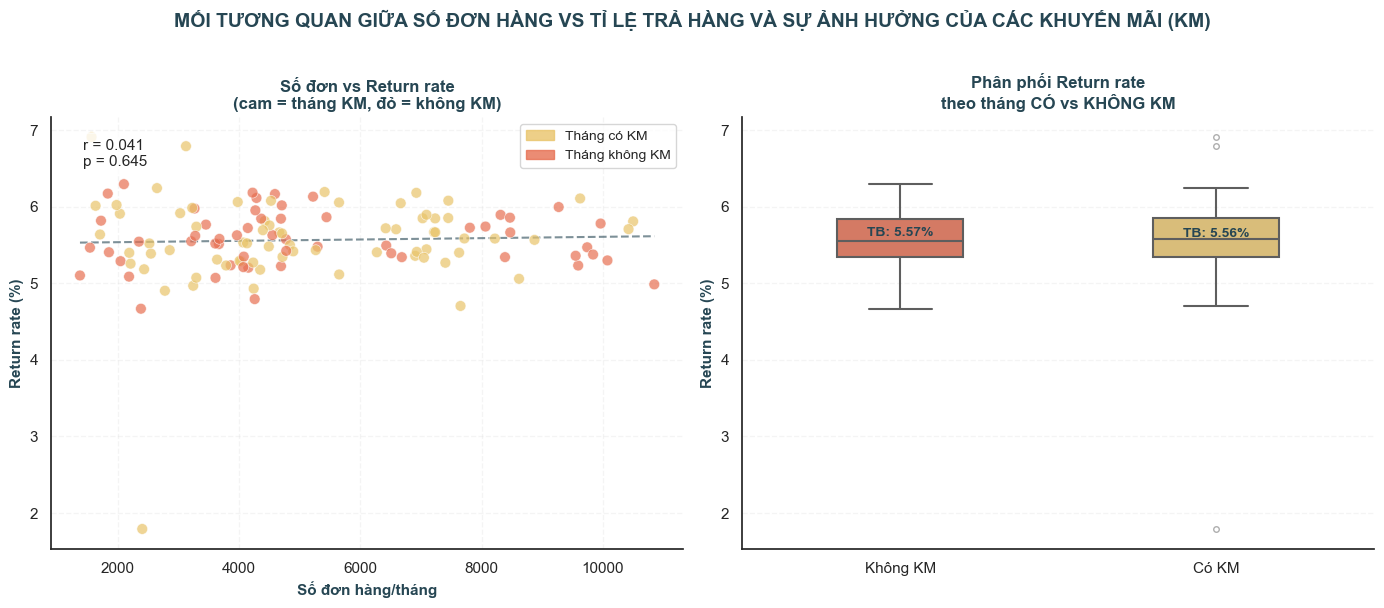

In [22]:
# Màu sắc
color_orders = '#e76f51'
color_return = '#2a9d8f'
color_promo  = '#e9c46a'
color_text   = '#264653'

#  Vẽ biểu đồ
sns.set_style("white")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=100)

# Scatter
ax = axes[0]
colors_dot = df_monthly['has_promotion'].apply(
    lambda x: color_promo if x > 0.3 else color_orders
)
ax.scatter(df_monthly['total_orders'], df_monthly['Return_Rate'],
           c=colors_dot, alpha=0.7, s=60,
           edgecolors='white', linewidths=0.5, zorder=3)

slope, intercept, r, p, _ = linregress(
    df_monthly['total_orders'], df_monthly['Return_Rate']
)
x_line = np.linspace(df_monthly['total_orders'].min(),
                     df_monthly['total_orders'].max(), 100)
ax.plot(x_line, slope * x_line + intercept,
        color=color_text, linewidth=1.5, linestyle='--', alpha=0.6)
ax.text(0.05, 0.95, f'r = {r:.3f}\np = {p:.3f}',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

# Legend scatter
patch_km     = mpatches.Patch(color=color_promo,  alpha=0.8, label='Tháng có KM')
patch_no_km  = mpatches.Patch(color=color_orders, alpha=0.8, label='Tháng không KM')
ax.legend(handles=[patch_km, patch_no_km], fontsize=10, frameon=True)

ax.set_xlabel('Số đơn hàng/tháng', fontweight='bold', color=color_text, fontsize=11)
ax.set_ylabel('Return rate (%)',    fontweight='bold', color=color_text, fontsize=11)
ax.set_title('Số đơn vs Return rate\n(cam = tháng KM, đỏ = không KM)',
             fontweight='bold', color=color_text)
ax.grid(linestyle='--', alpha=0.2)
sns.despine(ax=ax)

# Boxplot
ax = axes[1]
sns.boxplot(data=df_monthly, x='Nhóm', y='Return_Rate', ax=ax,
            palette={'Có KM': color_promo, 'Không KM': color_orders},
            order=['Không KM', 'Có KM'],
            width=0.4, linewidth=1.5,
            flierprops=dict(marker='o', markersize=4, alpha=0.5))

for i, group in enumerate(['Không KM', 'Có KM']):
    mean = df_monthly[df_monthly['Nhóm'] == group]['Return_Rate'].mean()
    ax.text(i, mean + 0.05, f'TB: {mean:.2f}%',
            ha='center', fontsize=10,
            fontweight='bold', color=color_text)

ax.set_title('Phân phối Return rate\ntheo tháng CÓ vs KHÔNG KM',
             fontweight='bold', color=color_text)
ax.set_xlabel('')
ax.set_ylabel('Return rate (%)', fontweight='bold', color=color_text, fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.2)
sns.despine(ax=ax)

plt.suptitle('MỐI TƯƠNG QUAN GIỮA SỐ ĐƠN HÀNG VS TỈ LỆ TRẢ HÀNG VÀ SỰ ẢNH HƯỞNG CỦA CÁC KHUYẾN MÃI (KM)',
             fontsize=14, fontweight='bold', color=color_text, y=1.01)
plt.tight_layout()
plt.show()

- Khuyến mãi không ảnh hưởng đến trả hàng: Tỷ lệ trả hàng trung bình giữa tháng Có KM (5.56%) và Không KM (5.57%) gần như bằng nhau tuyệt đối. Khuyến mãi chỉ giúp tăng doanh số chứ không làm tăng rủi ro bị trả hàng.

- Tỷ lệ trả hàng rất ổn định: Bất kể số lượng đơn hàng ít hay nhiều (từ 2,000 đến 10,000 đơn), tỷ lệ trả hàng vẫn duy trì ổn định quanh mức 5.5%. Hệ số tương quan $r = 0.041$ cực thấp xác nhận hai đại lượng này không liên quan đến nhau.

- Vận hành có sự kiểm soát tốt: Việc tỷ lệ trả hàng không tăng theo quy mô đơn hàng cho thấy khâu đóng gói và kiểm soát chất lượng sản phẩm đang hoạt động rất tốt và đồng nhất.

- Các điểm ngoại lệ (Outliers): Các tháng có khuyến mãi thỉnh thoảng xuất hiện các giá trị cực đoan (trả hàng rất thấp hoặc rất cao), nhưng đây chỉ là hiện tượng đơn lẻ, không phản ánh xu hướng chung của hệ thống.

Kết luận: Doanh nghiệp có thể tự tin đẩy mạnh quy mô đơn hàng và các chiến dịch khuyến mãi mà không cần lo lắng về việc làm biến động tỷ lệ trả hàng.

In [23]:
def plot_promo_effectiveness_tradeoff(df_web_traffic_sales, order_items, returns, orders, promotions):
    """
    Phân tích đánh đổi: Promo tăng doanh thu bao nhiêu vs chi phí thực tế
    """
    sns.set_style("white")
    df = df_web_traffic_sales.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df['month'] = df['Date'].dt.to_period('M').dt.to_timestamp()

    df_monthly = df.groupby('month').agg(
        Revenue=('Revenue', 'sum'),
        has_promotion=('has_promotion', 'mean'),
        order_count=('order_count', 'sum'),
    ).reset_index()

    df_monthly['is_promo_month'] = (df_monthly['has_promotion'] > 0.3).astype(int)
    df_monthly['avg_order_value'] = df_monthly['Revenue'] / df_monthly['order_count'].replace(0, np.nan)

    #  Tính discount_cost thực từ order_items
    oi = order_items.merge(orders[['order_id', 'order_date']], on='order_id')
    oi['order_date'] = pd.to_datetime(oi['order_date'])
    promo_order_ids = oi[oi['promo_id'].notna()]['order_id'].unique()
    oi['is_promo_order'] = oi['order_id'].isin(promo_order_ids).astype(int)
    oi['month'] = oi['order_date'].dt.to_period('M').dt.to_timestamp()

    discount_monthly = oi.groupby('month').agg(
        total_discount=('discount_amount', 'sum'),
        promo_discount=('discount_amount', lambda x: x[oi.loc[x.index, 'is_promo_order'] == 1].sum())
    ).reset_index()

    # Tính return_cost thực từ returns
    ret = returns.merge(orders[['order_id', 'order_date']], on='order_id', how='left')
    ret['order_date'] = pd.to_datetime(ret['order_date'])
    ret['month'] = ret['order_date'].dt.to_period('M').dt.to_timestamp()

    return_monthly = ret.groupby('month').agg(
        total_refund=('refund_amount', 'sum')
    ).reset_index()

    # Merge vào df_monthly
    df_monthly = df_monthly.merge(discount_monthly, on='month', how='left')
    df_monthly = df_monthly.merge(return_monthly,   on='month', how='left')
    df_monthly['total_discount'] = df_monthly['total_discount'].fillna(0)
    df_monthly['total_refund']   = df_monthly['total_refund'].fillna(0)

    # Tính month_of_year để phân tích timing
    df_monthly['month_of_year'] = pd.to_datetime(df_monthly['month']).dt.month
    months_timing = df_monthly.groupby('month_of_year').agg(
        Revenue=('Revenue', 'mean'),
        promo_rate=('is_promo_month', 'mean')
    ).reset_index()

    promo     = df_monthly[df_monthly['is_promo_month'] == 1]
    non_promo = df_monthly[df_monthly['is_promo_month'] == 0]

    # Tính các chỉ số so sánh
    means      = [non_promo['Revenue'].mean() / 1e6, promo['Revenue'].mean() / 1e6]
    means_aov  = [non_promo['avg_order_value'].mean() / 1e3, promo['avg_order_value'].mean() / 1e3]
    uplift     = (means[1] - means[0]) / means[0] * 100
    aov_change = (means_aov[1] - means_aov[0]) / means_aov[0] * 100

    rev_uplift    = (means[1] - means[0]) * 1e6
    discount_cost = max(promo['total_discount'].mean() - non_promo['total_discount'].mean(), 0)
    return_cost   = max(promo['total_refund'].mean()   - non_promo['total_refund'].mean(),   0)
    net_benefit   = rev_uplift - discount_cost - return_cost

    # Biểu đồ 1
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=100)
    fig.suptitle('PHÂN TÍCH ĐÁNH ĐỔI HIỆU QUẢ KHUYẾN MÃI',
                 fontsize=16, fontweight='bold', color='#264653', y=1)
    colors_main = ['#2a9d8f', '#e76f51']

    # Revenue
    ax = axes[0]
    bars = ax.bar(['Không KM', 'Có KM'], means,
                  color=colors_main, edgecolor='#444444', alpha=0.8, width=0.6)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{val:.0f}M', ha='center', fontweight='bold', fontsize=11)
    ax.set_title(f'Doanh thu TB/Tháng\n(Uplift: {uplift:+.1f}%)', fontweight='bold', pad=15)
    ax.set_ylabel('Triệu VND', fontweight='bold')
    sns.despine(ax=ax)

    # AOV
    ax = axes[1]
    bars2 = ax.bar(['Không KM', 'Có KM'], means_aov,
                   color=colors_main, edgecolor='#444444', alpha=0.8, width=0.6)
    for bar, val in zip(bars2, means_aov):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val:.0f}K', ha='center', fontweight='bold', fontsize=11)
    ax.set_title(f'Giá trị đơn hàng TB (AOV)\n(Biến động: {aov_change:+.1f}%)', fontweight='bold', pad=15)
    ax.set_ylabel('Nghìn VND', fontweight='bold')
    sns.despine(ax=ax)

    # Waterfall
    ax = axes[2]
    data      = [rev_uplift/1e6, -discount_cost/1e6, -return_cost/1e6, net_benefit/1e6]
    labels_wf = ['Revenue', 'Chi phí\nDiscount', 'Chi phí\nReturn', 'Lợi ích\nThuần']
    bottoms   = [0, rev_uplift/1e6, (rev_uplift - discount_cost)/1e6, 0]
    colors_wf = ['#76a5af', '#e9c46a', '#d98b73',
                 '#2a9d8f' if net_benefit > 0 else '#e76f51']

    for i, (val, bot, col, lab) in enumerate(zip(data, bottoms, colors_wf, labels_wf)):
        ax.bar(lab, val, bottom=bot, color=col, edgecolor='#444444', linewidth=1, width=0.6)
        y_text = bot + val + (max(abs(v) for v in data) * 0.03 * (1 if val >= 0 else -1))
        ax.text(i, y_text, f'{val:+.1f}M', ha='center', fontsize=9,
                fontweight='bold', color=col)

    ax.axhline(0, color='black', linewidth=1)
    ax.set_title('Waterfall: Lợi ích ròng/Tháng', fontweight='bold', pad=15)
    ax.set_ylabel('Triệu VND', fontweight='bold')
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

    # Biểu đồ 2: Timing
    fig2, ax2 = plt.subplots(figsize=(12, 5))
    month_labels = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']
    colors_bar   = ['#e76f51' if p >= 0.5 else '#2a9d8f' for p in months_timing['promo_rate']]

    bars3 = ax2.bar(month_labels, months_timing['Revenue'] / 1e6,
                    color=colors_bar, alpha=0.8, edgecolor='#444444', width=0.6)
    for bar, rate in zip(bars3, months_timing['promo_rate']):
        if rate >= 0.5:
            color = '#e76f51'
        else:
            color = '#2a9d8f'
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                  f'KM\n{rate*100:.0f}%', ha='center', fontsize=7.5,
                  color=color, fontweight='bold')

    ax2.set_title('DOANH THU TRUNG BÌNH THEO THÁNG & TỶ LỆ CÓ KHUYẾN MÃI',
                  fontsize=13, fontweight='bold')
    ax2.set_ylabel('Triệu VND / Tháng', fontweight='bold')
    ax2.set_xlabel('Tháng trong năm', fontweight='bold')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}M'))
    sns.despine(ax=ax2)
    plt.tight_layout()
    plt.show()

    # Print insights
    print(f"{'='*55}")
    print(f"{'NHẬN ĐỊNH HIỆU QUẢ KHUYẾN MÃI':^55}")
    print(f"{'='*55}")
    print(f"  Số tháng có KM / không KM:       {len(promo):>4} / {len(non_promo)}")
    print(f"  Doanh thu uplift:                {uplift:>+8.1f}%")
    print(f"  AOV thay đổi:                    {aov_change:>+8.1f}%")
    print(f"  Chi phí Discount tăng thêm:  {discount_cost/1e6:>8.1f} triệu/tháng")
    print(f"  Chi phí Return tăng thêm:    {return_cost/1e6:>8.1f} triệu/tháng")
    print(f"  Lợi ích ròng ước tính:       {net_benefit/1e6:>8.1f} triệu/tháng")
    status = "CÓ HIỆU QUẢ RÒNG" if net_benefit > 0 else "KHÔNG HIỆU QUẢ RÒNG"
    print(f"  Kết luận:                        {status}")
    print(f"{'='*55}")

    #  Diagnostic timing
    peak_no_promo = months_timing[months_timing['month_of_year'].isin([5,6])]['Revenue'].mean()
    peak_promo    = months_timing[months_timing['month_of_year'].isin([3,4])]['Revenue'].mean()
    low_promo     = months_timing[months_timing['month_of_year'].isin([11,12])]['Revenue'].mean()
    diff          = (peak_no_promo - peak_promo) / peak_promo * 100

    print(f"\n[Phân tích timing Khuyến Mãi]")
    print(f"  Cao điểm KHÔNG KM (T5-T6):   {peak_no_promo/1e6:.0f}M/tháng")
    print(f"  Cao điểm CÓ KM    (T3-T4):   {peak_promo/1e6:.0f}M/tháng")
    print(f"  Thấp điểm CÓ KM   (T11-T12): {low_promo/1e6:.0f}M/tháng")
    print(f"\n  -> T5-T6 (không KM) cao hơn T3-T4 (có KM) {diff:.0f}%")
    print(f"    KM chưa đủ mạnh để tạo ra mùa cao điểm")
    print(f"  -> KM cuối năm (T11-T12) chỉ đạt {low_promo/1e6:.0f}M —")
    print(f"    không kích cầu hiệu quả ở mùa thấp điểm")
    print(f"  -> Đề xuất: tập trung KM vào T5-T6 khi nhu cầu tự nhiên cao,")
    print(f"    cắt giảm KM T11-T12 vì ROI thấp.")

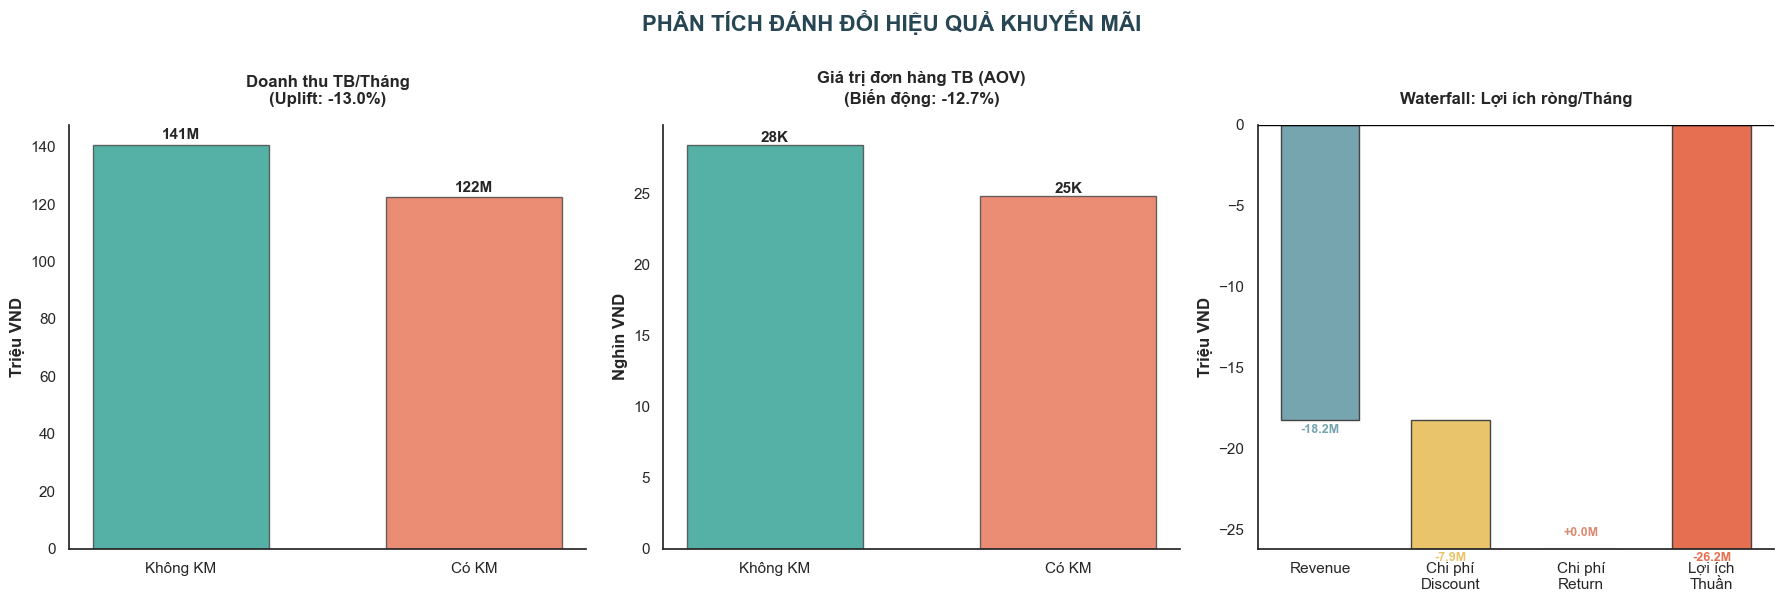

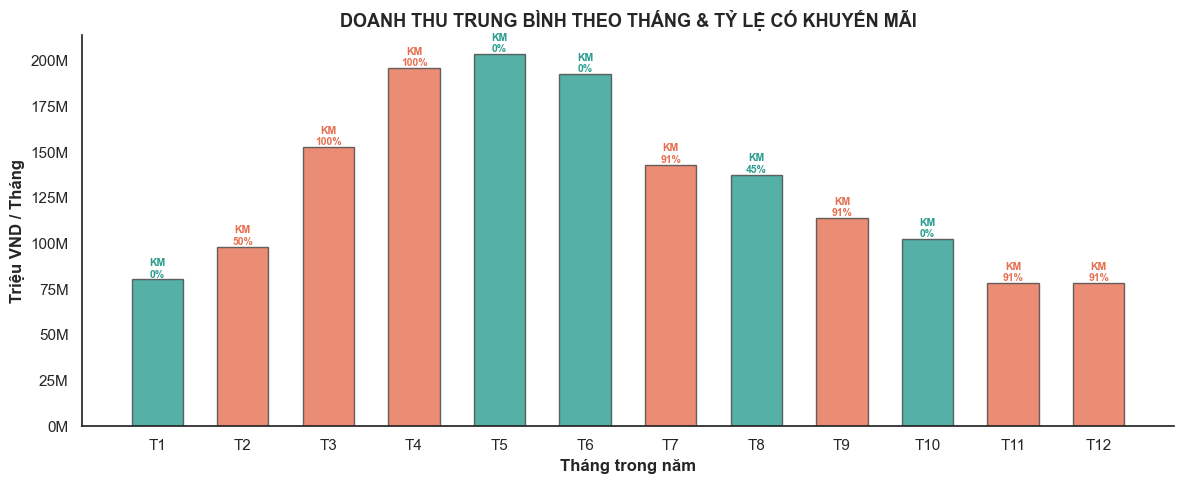

             NHẬN ĐỊNH HIỆU QUẢ KHUYẾN MÃI             
  Số tháng có KM / không KM:         70 / 56
  Doanh thu uplift:                   -13.0%
  AOV thay đổi:                       -12.7%
  Chi phí Discount tăng thêm:       7.9 triệu/tháng
  Chi phí Return tăng thêm:         0.0 triệu/tháng
  Lợi ích ròng ước tính:          -26.2 triệu/tháng
  Kết luận:                        KHÔNG HIỆU QUẢ RÒNG

[Phân tích timing Khuyến Mãi]
  Cao điểm KHÔNG KM (T5-T6):   198M/tháng
  Cao điểm CÓ KM    (T3-T4):   174M/tháng
  Thấp điểm CÓ KM   (T11-T12): 78M/tháng

  -> T5-T6 (không KM) cao hơn T3-T4 (có KM) 14%
    KM chưa đủ mạnh để tạo ra mùa cao điểm
  -> KM cuối năm (T11-T12) chỉ đạt 78M —
    không kích cầu hiệu quả ở mùa thấp điểm
  -> Đề xuất: tập trung KM vào T5-T6 khi nhu cầu tự nhiên cao,
    cắt giảm KM T11-T12 vì ROI thấp.


In [24]:
plot_promo_effectiveness_tradeoff(df_web_traffic_sales, order_items, returns, orders, promotions)

## **PHÂN CỤM KHÁCH HÀNG**

In [25]:
df = pd.merge(order_items, orders[['order_id', 'order_date', 'customer_id', 'order_status']], on='order_id', how='left')
df = pd.merge(df, products[['product_id', 'product_name', 'price', 'cogs']], on='product_id', how='left')
df = pd.merge(df, returns[['return_id', 'order_id', 'product_id', 'return_quantity', 'refund_amount']], on=['order_id', 'product_id'], how='left')

# Điền giá trị 0 cho những đơn không hoàn trả
df['refund_amount'] = df['refund_amount'].fillna(0)
df['return_quantity'] = df['return_quantity'].fillna(0)

# Gắn cờ cho những đơn hàng hoàn lại toàn bộ số lượng
df['is_fully_returned'] = df['return_quantity'] == df['quantity']

### **Phân tích theo độ tuổi khách hàng**

In [26]:
customers['age_group'].value_counts()

age_group
25-34    36342
35-44    31920
45-54    23172
18-24    17039
55+      13457
Name: count, dtype: int64

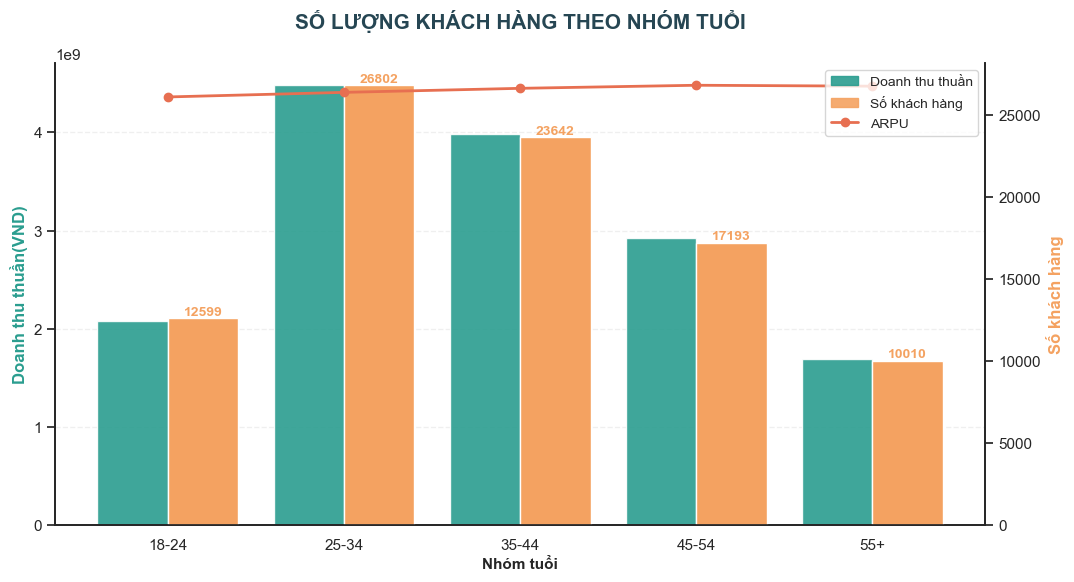

In [27]:
df1 = df[['order_id', 'customer_id', 'product_id', 'unit_price', 'quantity', 'refund_amount', 'discount_amount']].copy()
df_merge = pd.merge(df1, customers[['customer_id', 'age_group']], on='customer_id', how='left')
df_merge['net_revenue'] = df_merge['unit_price'] * df_merge['quantity'] - df_merge['discount_amount'] - df_merge['refund_amount']

df_merge = df_merge.groupby('age_group').agg({
    'net_revenue': 'sum',
    'customer_id': 'nunique'
}).rename(columns={'customer_id': 'customer_count'}).reset_index()

df_merge['arpu'] = df_merge['net_revenue'] / df_merge['customer_count']
df_merge['arpu_scaled'] = df_merge['arpu'] / df_merge['arpu'].max() * df_merge['customer_count'].max()

# plot
# ================================= Vẽ biểu đồ =================================
sns.set_theme(style="white")
fig, ax1 = plt.subplots(figsize=(12, 6), dpi=100)

x = np.arange(len(df_merge['age_group']))
width = 0.4

color_rev     = '#2a9d8f'
color_count = '#f4a261'

# bar net revenue (trục trái)
ax1 = plt.gca()
ax1.bar(x - width/2, df_merge['net_revenue'], width, color=color_rev, alpha=0.9)

ax1.set_ylabel('Doanh thu thuần(VND)', fontsize=12, fontweight='bold', color=color_rev)
ax1.set_xlabel('Nhóm tuổi', fontsize=11, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(df_merge['age_group'])

# bar customer count (trục phải)
ax2 = ax1.twinx()
ax2.bar(x + width/2, df_merge['customer_count'], width, color=color_count)

ax2.set_ylabel('Số khách hàng', fontsize=12, fontweight='bold', color=color_count)

ax2.plot(x, df_merge['arpu_scaled'],
         color='#e76f51',
         marker='o',
         linewidth=2,
         label='ARPU')

for i, val in enumerate(df_merge['customer_count']):
    if not pd.isna(val):
        ax2.text(i + width/2, val + 3, f'{int(val)}',
                 color=color_count, ha='center', va='bottom',
                 fontweight='bold', fontsize=10)

# Legend
handles = [
    mpatches.Patch(color=color_rev, alpha=0.9, label='Doanh thu thuần'),
    mpatches.Patch(color=color_count, alpha=0.9, label='Số khách hàng'),
    mlines.Line2D([], [], color='#e76f51', marker='o', linewidth=2, label='ARPU')
]
ax2.legend(handles=handles, loc='upper right', frameon=True, fontsize=10)

sns.despine(right=False)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
plt.title('SỐ LƯỢNG KHÁCH HÀNG THEO NHÓM TUỔI',
          fontsize=15, fontweight='bold', pad=25, color='#264653')
plt.show()

**Đánh giá tổng quan**
- Khách hàng từ độ tuổi 25-34 và 35-44 dẫn đầu về cả doanh thu thuần và số lượng khách hàng. Do độ cao của 2 cột ở mỗi nhóm tuổi khá đồng đều nên có thể kết luận rằng giá trị chi tiêu trung bình không có sự đột biến quá lớn giữa các lứa tuổi. Sự khác biệt về doanh thu chủ yếu đến từ quy mô khách hàng của mỗi nhóm
- Phân tích ARPU cho thấy sức mua cá nhân là đồng nhất(biến thiên nhỏ). Điều này chứng tỏ đặc thù sản phẩm phù hợp đa dạng lứa tuổi và dư địa tăng trưởng nằm ở việc mở rộng tệp khách hàng tại các nhóm tuổi đang có tỷ trọng thấp

### **Recency**

In [28]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
# Lần mua hàng gần nhất của một khách hàng
orders['order_day'] = orders['order_date'].dt.date

# Tìm ngày mua hàng gần nhất
customer_data = orders.groupby('customer_id')['order_day'].max().reset_index()

# Ngày mua được cập nhất mới nhất từ tập dữ liệu
most_recent_date = orders['order_day'].max()

# chuyển đổi kiểu dữ liệu trước khi trừ
customer_data['order_day'] = pd.to_datetime(customer_data['order_day'])
most_recent_date = pd.to_datetime(most_recent_date)

# Tính số ngày từ lần cuối mua hàng
customer_data['days_since_last_purchase'] = (most_recent_date - customer_data['order_day']).dt.days

#  Bỏ cột
customer_data.drop(columns=['order_day'], inplace=True)

customer_data.head()

,customer_id,days_since_last_purchase
0,1,616
1,2,178
2,3,3442
3,4,916
4,5,1375


### **Frequency**

In [29]:
# Lọc những đơn hàng không hoàn trả lại toàn bộ
valid_orders = df[df['is_fully_returned'] == False].copy()
total_transactions = valid_orders.groupby('customer_id')['order_id'].nunique().reset_index()
total_transactions.rename(columns={'order_id': 'total_transactions'}, inplace=True)

df1 = df.copy()
df1['net_quantity'] = df1['quantity'] - df1['return_quantity']

# Số sản phẩm đã mua của mỗi khách hàng
total_products_purchased = df1.groupby('customer_id')['net_quantity'].sum().reset_index()
total_products_purchased.rename(columns={'net_quantity': 'total_products_purchased'}, inplace=True)

# Merge
customer_data = pd.merge(customer_data, total_transactions, on='customer_id', how='left')
customer_data = pd.merge(customer_data, total_products_purchased, on='customer_id', how='left')

customer_data['total_transactions'] = customer_data['total_transactions'].fillna(0)
customer_data['total_products_purchased'] = customer_data['total_products_purchased'].fillna(0)

# Display
customer_data.head()

,customer_id,days_since_last_purchase,total_transactions,total_products_purchased
0,1,616,5.0,25.0
1,2,178,4.0,23.0
2,3,3442,3.0,12.0
3,4,916,1.0,8.0
4,5,1375,5.0,23.0


### **Monetary**

In [30]:
# Vẫn lấy những đơn hàng hoàn trả toàn bộ số lượng
df1['total_spend'] = df1['quantity'] * df1['unit_price'] - df1['discount_amount'] - df1['refund_amount']
total_spend = df1.groupby('customer_id')['total_spend'].sum().reset_index()

# Tính giá trị trung bình đơn hàng
avg_order_value = total_spend.merge(total_transactions, on='customer_id')
avg_order_value['avg_order_value'] = avg_order_value['total_spend'] / avg_order_value['total_transactions']

# Merge
customer_data = pd.merge(customer_data, total_spend, on='customer_id')
customer_data = pd.merge(customer_data, avg_order_value[['customer_id', 'avg_order_value']], on='customer_id')

# Display
customer_data.head()

,customer_id,days_since_last_purchase,total_transactions,total_products_purchased,total_spend,avg_order_value
0,1,616,5.0,25.0,141404.83,28280.9660
1,2,178,4.0,23.0,204693.89,51173.4725
2,3,3442,3.0,12.0,52093.47,17364.4900
3,4,916,1.0,8.0,10939.06,10939.0600
4,5,1375,5.0,23.0,64179.86,12835.9720


### **Behavior**

In [31]:
df1['order_date'] = pd.to_datetime(df1['order_date'])
df1['order_day'] = df1['order_date'].dt.date
df1['day_of_week'] = df1['order_date'].dt.day_of_week

days_between_purchases = df1.groupby('customer_id')['order_day'].apply(lambda x: (x.diff().dropna()).apply(lambda y: y.days))
avg_days_between_purchases = days_between_purchases.groupby('customer_id').mean().reset_index()
avg_days_between_purchases.rename(columns={'order_day': 'avg_days_between_purchases'}, inplace=True)

# Tìm ngày mua yêu thích trong tuần
favorite_day_shopping = df1.groupby(['customer_id', 'day_of_week']).size().reset_index(name='Count')
favorite_day_shopping = favorite_day_shopping.loc[favorite_day_shopping.groupby('customer_id')['Count'].idxmax()][['customer_id', 'day_of_week']]

# Merge
customer_data = pd.merge(customer_data, avg_days_between_purchases, on='customer_id')
customer_data = pd.merge(customer_data, favorite_day_shopping, on='customer_id')

# Display
customer_data.head()

,customer_id,days_since_last_purchase,total_transactions,total_products_purchased,total_spend,avg_order_value,avg_days_between_purchases,day_of_week
0,1,616,5.0,25.0,141404.83,28280.9660,532.500000,0
1,2,178,4.0,23.0,204693.89,51173.4725,1070.333333,0
2,3,3442,3.0,12.0,52093.47,17364.4900,168.000000,0
3,5,1375,5.0,23.0,64179.86,12835.9720,605.250000,5
4,6,559,10.0,41.0,148527.26,14852.7260,350.777778,3


In [32]:
# Overall
overall = df1['day_of_week'].value_counts()

# Per customer
per_customer = favorite_day_shopping['day_of_week'].value_counts()

# Heavy users
dfc = df1.copy()
dfc['order_count'] = dfc.groupby('customer_id')['order_id'].transform('count')

top_users = dfc[dfc['order_count'] > dfc['order_count'].quantile(0.9)]
heavy = top_users['day_of_week'].value_counts()

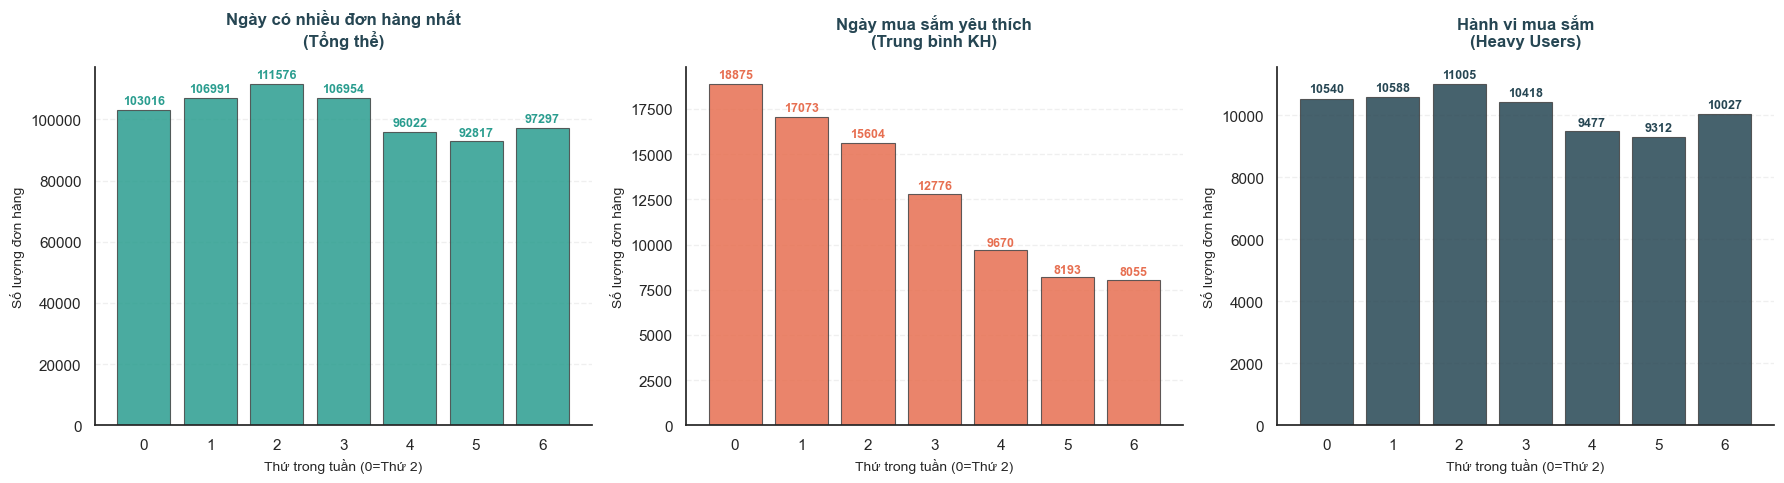

In [33]:
sns.set_style("white")
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=100)

# --- BẢNG MÀU ---
colors = ['#2a9d8f', '#e76f51', '#264653']
titles = ['Ngày có nhiều đơn hàng nhất\n(Tổng thể)',
          'Ngày mua sắm yêu thích\n(Trung bình KH)',
          'Hành vi mua sắm\n(Heavy Users)']
data_sources = [overall, per_customer, heavy]

for i, ax in enumerate(axes):
    bars = ax.bar(data_sources[i].index, data_sources[i].values,
                  color=colors[i], alpha=0.85, edgecolor='#444444', linewidth=0.8)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + (height*0.01),
                f'{int(height)}', ha='center', va='bottom',
                fontsize=9, fontweight='bold', color=colors[i])

    ax.set_title(titles[i], fontsize=12, fontweight='bold', color='#264653', pad=15)
    ax.set_xlabel('Thứ trong tuần (0=Thứ 2)', fontsize=10)
    ax.set_ylabel('Số lượng đơn hàng', fontsize=10)

    # Tinh chỉnh khung viền
    sns.despine(ax=ax)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Đánh giá tổng quan**
- Khách hàng có xu hướng mua sắm vào đầu tuần(đạt đỉnh vào Thứ 2) với hơn 18000 khách hàng. Điều này cho thấy khách hàng có thói quan lên kế hoạch mua sắm hoặc tìm hiểu sản phẩm vào các ngày nghỉ cuối tuần
- Nhóm khách hàng giá trị cao mua hàng nhiều nhất vào Thứ 4(Index 2), hoàn toàn đồng nhất với xu hướng của tổng thể thị trường
- Decision Lag: kéo dài khoảng 48h, khách hàng ghé thăm vào Thứ 2 nhưng cần thời gian cân nhắc hoặc chờ đợi các chương trình kích càu để chốt đơn vào Thứ 4

**Định hướng chiến lược**
- Kho vận cần chuẩn bị sẵn sàng nhân sự đóng gói và đơn vị vận chuyển từ sáng Thứ 4 để xử lý lượng đơn hàng khổng lồ(hơn 111k đơn)
- Dự phòng hàng hóa: hàng tồn kho phải được kiểm kê và đưa lên kệ trước 1-2 ngày để tránh tình trạng hết hàng ngay thời điểm khách hàng chi tiêu mạnh nhất.
- Triển khai các chiến dịch Retargeting hoặc tập trung ngân sách quảng cáo và mã giảm giá ngắn hạn vào Thứ 4 để thu hẹp Decision Lag

**Cancellation & Returning Insights**

In [34]:
cancelled_transactions = df1[df1['order_status'] == 'cancelled']
cancellation_frequency = cancelled_transactions.groupby('customer_id')['order_id'].nunique().reset_index()
cancellation_frequency.rename(columns={'order_id': 'cancellation'}, inplace=True)

# Merge
customer_data = pd.merge(customer_data, cancellation_frequency, on='customer_id', how='left')

# Điền 0 cho những khách hàng không hủy đơn
customer_data['cancellation'].fillna(0, inplace=True)

# Tính tỉ lệ hủy đơn của khách hàng
customer_data['cancellation_rate'] = customer_data['cancellation'] / customer_data['total_transactions']

# Display
customer_data.head()

,customer_id,days_since_last_purchase,total_transactions,total_products_purchased,total_spend,avg_order_value,avg_days_between_purchases,day_of_week,cancellation,cancellation_rate
0,1,616,5.0,25.0,141404.83,28280.9660,532.500000,0,0.0,0.000000
1,2,178,4.0,23.0,204693.89,51173.4725,1070.333333,0,2.0,0.500000
2,3,3442,3.0,12.0,52093.47,17364.4900,168.000000,0,1.0,0.333333
3,5,1375,5.0,23.0,64179.86,12835.9720,605.250000,5,0.0,0.000000
4,6,559,10.0,41.0,148527.26,14852.7260,350.777778,3,1.0,0.100000


In [35]:
returned_transactions = df1[df1['order_status'] == 'returned']
returning_frequency = returned_transactions.groupby('customer_id')['order_id'].nunique().reset_index()
returning_frequency.rename(columns={'order_id': 'returning'}, inplace=True)

# Merge
customer_data = pd.merge(customer_data, returning_frequency, on='customer_id', how='left')

# Điền 0 cho những khách hàng không hoàn hàng
customer_data['returning'].fillna(0, inplace=True)

# Tính tỉ lệ hủy đơn của khách hàng
customer_data['returning_rate'] = customer_data['returning'] / customer_data['total_transactions']

# Display
customer_data.head()

,customer_id,days_since_last_purchase,total_transactions,total_products_purchased,total_spend,avg_order_value,avg_days_between_purchases,day_of_week,cancellation,cancellation_rate,returning,returning_rate
0,1,616,5.0,25.0,141404.83,28280.9660,532.500000,0,0.0,0.000000,1.0,0.2
1,2,178,4.0,23.0,204693.89,51173.4725,1070.333333,0,2.0,0.500000,0.0,0.0
2,3,3442,3.0,12.0,52093.47,17364.4900,168.000000,0,1.0,0.333333,0.0,0.0
3,5,1375,5.0,23.0,64179.86,12835.9720,605.250000,5,0.0,0.000000,0.0,0.0
4,6,559,10.0,41.0,148527.26,14852.7260,350.777778,3,1.0,0.100000,0.0,0.0


### **Seasonality & Trend**

In [36]:
df1['year'] = df1['order_date'].dt.year
df1['month'] = df1['order_date'].dt.month

# Chi tiêu hàng tháng của khách hàng
mothly_spending = df1.groupby(['customer_id', 'year', 'month'])['total_spend'].sum().reset_index()

# Tính mean và std
seasonal_buying_patterns = mothly_spending.groupby('customer_id')['total_spend'].agg(['mean', 'std']).reset_index()
seasonal_buying_patterns.rename(columns={'mean':'monthly_spending_mean', 'std':'monthly_spending_std'}, inplace=True)

# Thay thế giá trị NaN ở Monthly_Spending_Std bằng 0(những khách hàng chỉ mua trong 1 tháng duy nhất)
seasonal_buying_patterns['monthly_spending_std'] = seasonal_buying_patterns['monthly_spending_std'].fillna(0)

# Xu hướng trong chi tiêu
def calculate_trend(spend_data):
    if len(spend_data) > 1:
        x = np.arange(len(spend_data))
        slope, _, _, _, _ = linregress(x, spend_data)
        return slope
    else:
        return 0

# Apply
spending_trends = mothly_spending.groupby('customer_id')['total_spend'].apply(calculate_trend).reset_index()
spending_trends.rename(columns={'total_spend': 'spending_trend'}, inplace=True)

# Merge
customer_data = pd.merge(customer_data, seasonal_buying_patterns, on='customer_id')
customer_data = pd.merge(customer_data, spending_trends, on='customer_id')

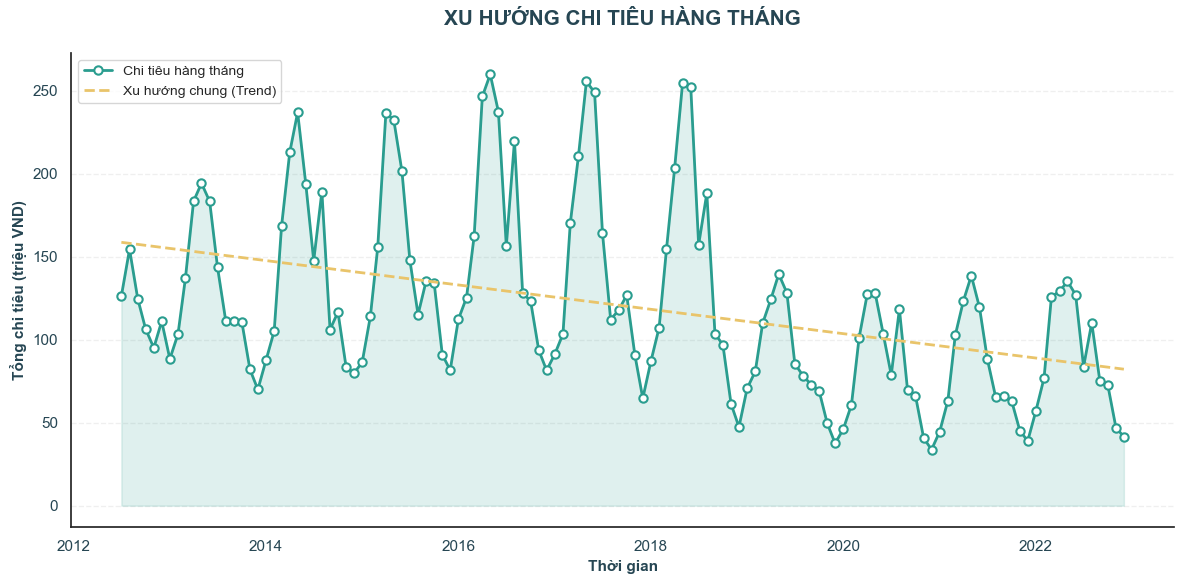

In [37]:
monthly_spending = df1.groupby(
    ['year', 'month']
)['total_spend'].sum().reset_index()
monthly_spending['date'] = pd.to_datetime(
    monthly_spending['year'].astype(str) + '-' + monthly_spending['month'].astype(str)
)

x = monthly_spending['date']
y = monthly_spending['total_spend']

sns.set_style("white")
plt.figure(figsize=(12, 6), dpi=100)

# --- BẢNG MÀU ---
color_main = '#2a9d8f'  # (Chi tiêu thực tế)
color_trend = '#e9c46a' # (Đường xu hướng)
color_text = '#264653'  # (Tiêu đề & Nhãn)

plt.plot(x, y/1e6, marker='o', markersize=6, color=color_main,
         linewidth=2, label='Chi tiêu hàng tháng',
         markerfacecolor='white', markeredgewidth=1.5, zorder=3)
plt.fill_between(x, y/1e6, color=color_main, alpha=0.15, zorder=2)

# Trend line
z = np.polyfit(range(len(y)), y/1e6, 1)
trend_line = np.poly1d(z)
plt.plot(x, trend_line(range(len(y))), color=color_trend,
         linestyle='--', linewidth=2, label='Xu hướng chung (Trend)', zorder=4)

ax = plt.gca()
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.xticks(rotation=0, ha='center', color=color_text)
plt.yticks(color=color_text)

plt.xlabel('Thời gian', fontsize=11, fontweight='bold', color=color_text)
plt.ylabel('Tổng chi tiêu (triệu VND)', fontsize=11, fontweight='bold', color=color_text)
plt.title('XU HƯỚNG CHI TIÊU HÀNG THÁNG', fontsize=15,
          fontweight='bold', pad=20, color=color_text)
plt.legend(loc='upper left', frameon=True, shadow=False, fontsize=10)

plt.tight_layout()
plt.show()

- Tính chu kì mạnh mẽ: biểu đồ có các đỉnh và đáy lặp lại rất đều đặn hàng năm
- Thường vào giữa năm chi tiêu trung bình tăng mạnh(tháng 5-6-7) - tối ưu kho hàng trước 1-2 tháng để có sự chuẩn bị tốt cho đợt mua sắm. Các tháng cuối năm trước - đầu năm sau là đáy của chi tiêu trung bình - đẩy mạnh chương trình thu hút khách hàng để tăng lượt mua trong giai đoạn này
- Sự chênh lệch giữa đỉnh và đáy rất mạnh mẽ, cho thấy doanh thu phụ thuộc rất lớn vào các dịp khuyến mãi(đặc biệt là dịp tháng 7-tháng 9 đã phân tích ở promotions).

-> Đề xuất: Thay vì chỉ mong chờ sự đột biến doanh thu từ các chương trình khuyến mãi, có thể xây dựng hệ thống 'Member-Only Deals' để thu hút và giữ chân khách hàng, đồng thời nâng đáy của biểu đồ chi tiêu

### **Feature Scaling**

In [38]:
scaler = StandardScaler()
customer_data_scaled = customer_data.copy()

excluding_cols = ['customer_id', 'day_of_week']
scaling_cols = customer_data.columns.difference(excluding_cols)

customer_data_scaled[scaling_cols] = scaler.fit_transform(customer_data_scaled[scaling_cols])
customer_data_scaled.head()

,customer_id,days_since_last_purchase,total_transactions,total_products_purchased,total_spend,avg_order_value,avg_days_between_purchases,day_of_week,cancellation,cancellation_rate,returning,returning_rate,monthly_spending_mean,monthly_spending_std,spending_trend
0,1,-0.428188,-0.424382,-0.397184,-0.303567,0.435421,0.081667,0,-0.689338,-0.645246,0.588436,0.983140,-0.080636,0.065851,0.213282
1,2,-0.935091,-0.536772,-0.441352,-0.020434,2.483248,1.176909,0,0.988687,2.793253,-0.583460,-0.443717,2.269378,0.511780,0.142192
2,3,2.842373,-0.649162,-0.684273,-0.703115,-0.541102,-0.660600,0,0.149674,1.647087,-0.583460,-0.443717,-0.608676,0.026431,1.017007
3,5,0.450211,-0.424382,-0.441352,-0.649045,-0.946197,0.229815,5,-0.689338,-0.645246,-0.583460,-0.443717,-0.994175,-0.872721,-0.221937
4,6,-0.494155,0.137569,-0.043844,-0.271704,-0.765790,-0.288392,3,0.149674,0.042454,-0.583460,-0.443717,-0.682010,0.422364,-0.336266


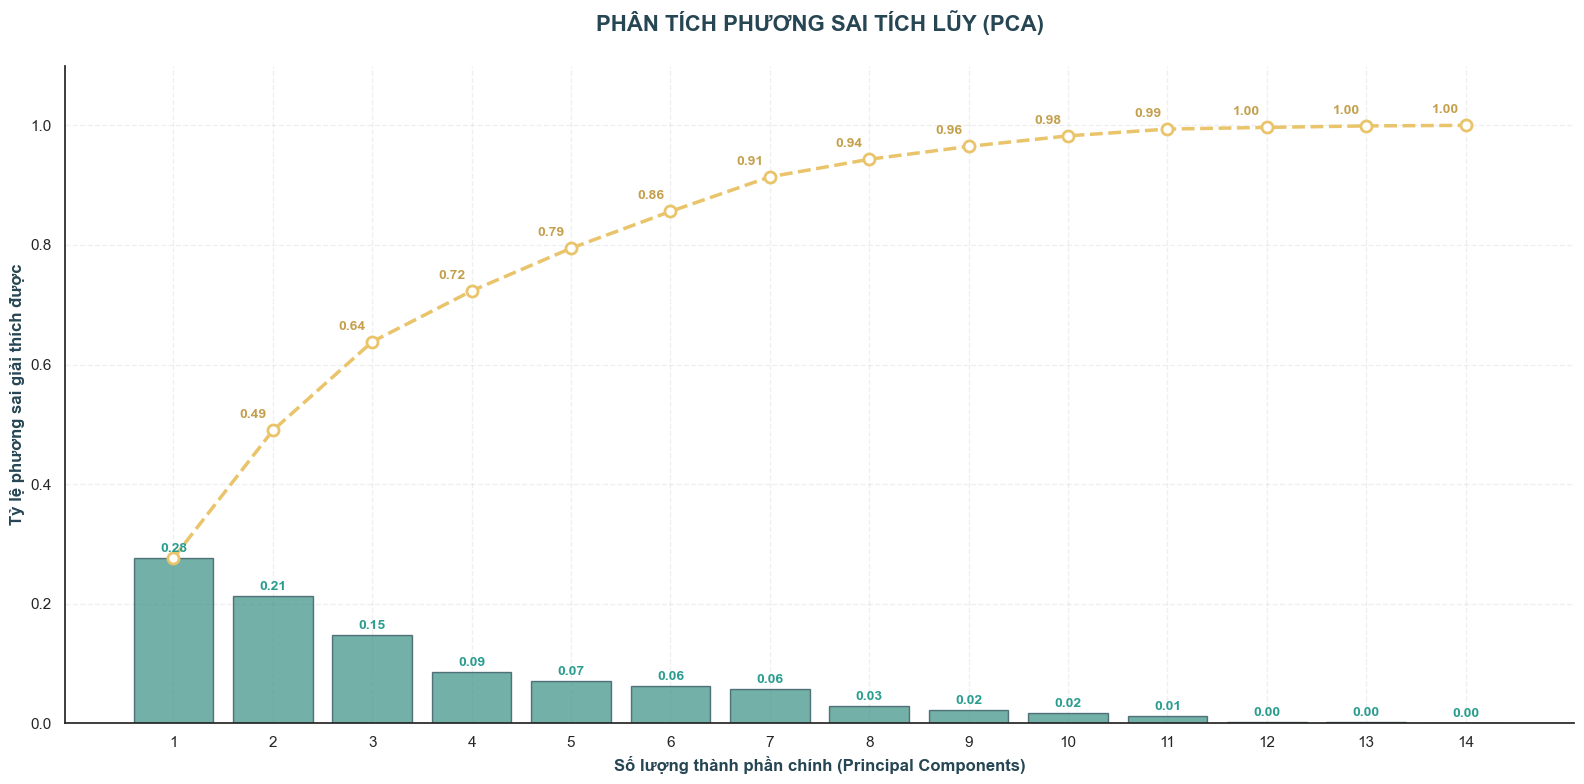

In [39]:
customer_data_scaled.set_index('customer_id', inplace=True)

# Apply PCA
pca = PCA().fit(customer_data_scaled)

# Tính tổng cộng cồn của explained variance
explained_variance_ratio = pca.explained_variance_ratio_ # mỗi trục giữ được bnhieu % thông tin
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Đồ thị
sns.set_style("white")
plt.figure(figsize=(16, 8), dpi=100)

# --- BẢNG MÀU ---
color_bar = '#2a9d8f'   # (Phương sai từng thành phần)
color_line = '#e9c46a'  # (Tổng tích lũy)
color_text = '#264653'  # (Chữ và số)

# Bar chart
barplot = sns.barplot(
    x=list(range(1, len(cumulative_explained_variance) + 1)),
    y=explained_variance_ratio,
    color=color_bar, alpha=0.7, edgecolor=color_text, linewidth=1
)

# Line plot
plt.plot(
    range(0, len(cumulative_explained_variance)),
    cumulative_explained_variance,
    marker='o', markersize=8, color=color_line,
    linestyle='--', linewidth=2.5, markerfacecolor='white', markeredgewidth=2,
    label='Cumulative Variance'
)

# Nhãn và tiêu đề
for i, (ev_ratio, cum_ev_ratio) in enumerate(zip(explained_variance_ratio, cumulative_explained_variance)):
    # Nhãn cho Bar
    plt.text(i, ev_ratio + 0.005, f'{ev_ratio:.2f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold', color=color_bar)

    # Nhãn cho Line
    if i > 0:
        plt.text(i - 0.2, cum_ev_ratio + 0.015, f'{cum_ev_ratio:.2f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#c4a04d')

sns.despine()
plt.xlabel('Số lượng thành phần chính (Principal Components)', fontsize=12, fontweight='bold', color=color_text)
plt.ylabel('Tỷ lệ phương sai giải thích được', fontsize=12, fontweight='bold', color=color_text)
plt.title('PHÂN TÍCH PHƯƠNG SAI TÍCH LŨY (PCA)', fontsize=16, fontweight='bold', pad=25, color=color_text)
plt.grid(axis='both', linestyle='--', alpha=0.3)
plt.ylim(0, 1.1)

plt.tight_layout()
plt.show()

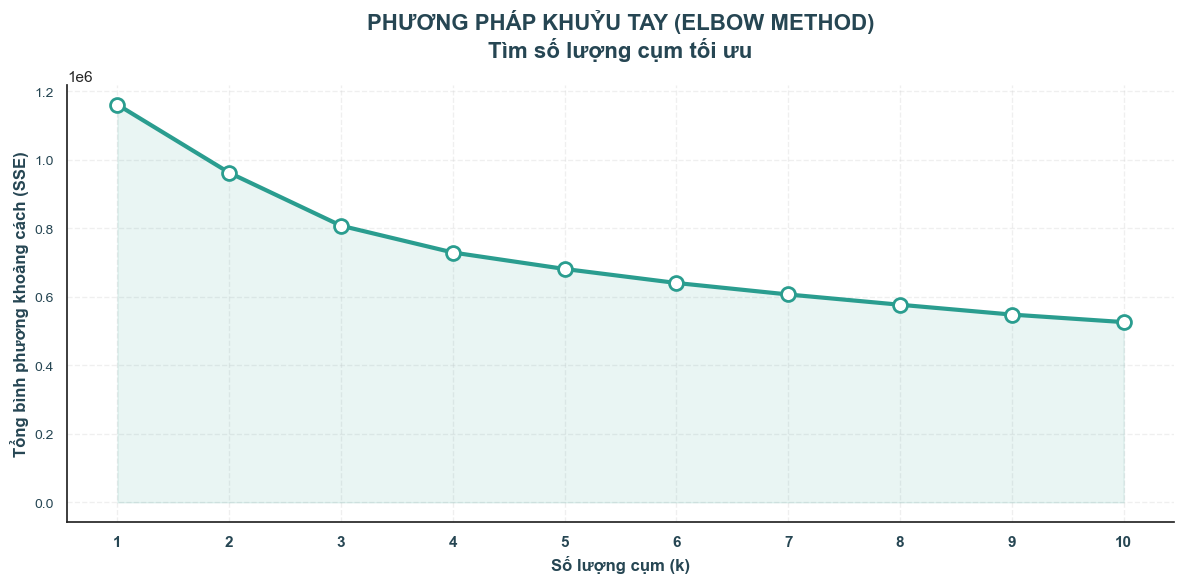

In [40]:
sse = []
for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(customer_data_scaled)
  sse.append(kmeans.inertia_)

sns.set_style("white")
plt.figure(figsize=(12, 6), dpi=100)

# --- BẢNG MÀU ---
color_main = '#2a9d8f' # (Màu chủ đạo)
color_text = '#264653' # (Chữ và số)

plt.plot(range(1, 11), sse,
         marker='o', markersize=10,
         color=color_main, linewidth=3,
         markerfacecolor='white', markeredgewidth=2,
         zorder=3)
plt.fill_between(range(1, 11), sse, color=color_main, alpha=0.1, zorder=2)

ax = plt.gca()
sns.despine()

plt.xticks(range(1, 11), fontsize=11, fontweight='bold', color=color_text)
plt.yticks(fontsize=10, color=color_text)

plt.xlabel('Số lượng cụm (k)', fontsize=12, fontweight='bold', color=color_text)
plt.ylabel('Tổng bình phương khoảng cách (SSE)', fontsize=12, fontweight='bold', color=color_text)
plt.title('PHƯƠNG PHÁP KHUỶU TAY (ELBOW METHOD)\nTìm số lượng cụm tối ưu',
          fontsize=16, fontweight='bold', pad=20, color=color_text)
plt.grid(axis='both', linestyle='--', alpha=0.3, zorder=1)

plt.tight_layout()
plt.show()

In [41]:
pca = PCA(n_components=7, random_state=0)

# Fitting and transforming dữ liệu ban đầu
customer_data_pca = pca.fit_transform(customer_data_scaled)
customer_data_pca = pd.DataFrame(customer_data_pca, columns=['PC'+str(i+1) for i in range(pca.n_components)])

# Thêm vào cột CustomerID
customer_data_pca.index = customer_data_scaled.index

In [42]:
# Chọn k = 3 
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=100, random_state=0)
kmeans.fit(customer_data_pca)
customer_data_pca['cluster'] = kmeans.labels_
customer_data['cluster'] = kmeans.labels_

In [43]:
data = customer_data.copy()
data = data.drop(columns='day_of_week')

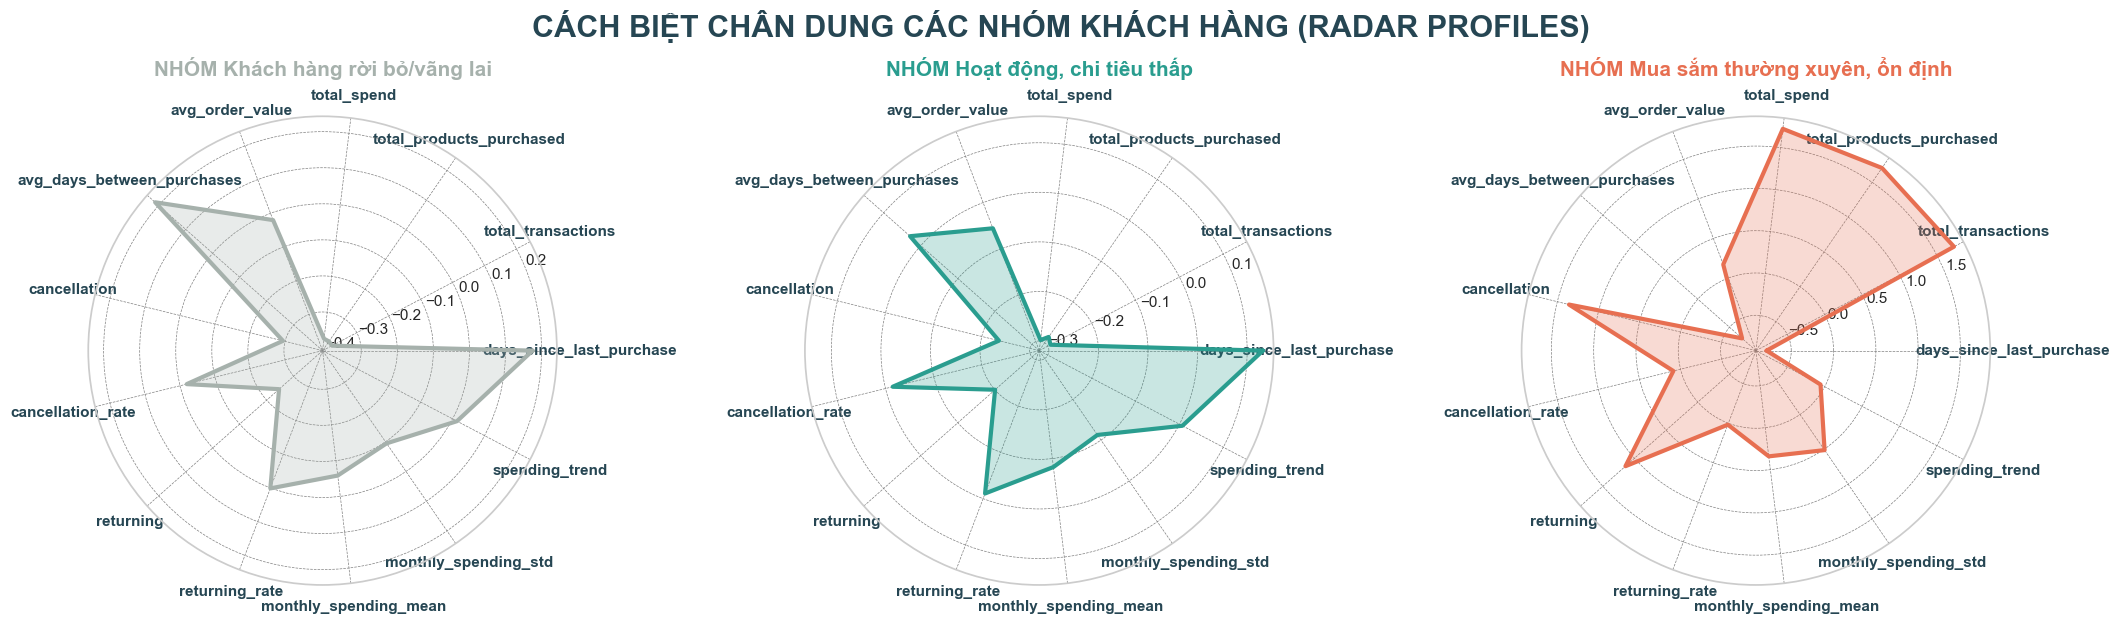

In [44]:
# --- RADAR CHART ---
if 'customer_id' in data.columns:
    data.set_index('customer_id', inplace=True)

scaler = StandardScaler()
# Sử dụng errors='ignore' để an toàn nếu chạy lại nhiều lần
features = data.drop(columns=['cluster'], errors='ignore')
df_standardized = pd.DataFrame(scaler.fit_transform(features), columns=features.columns, index=data.index)
df_standardized['cluster'] = data['cluster']

# Tính tâm của mỗi cụm
cluster_centroids = df_standardized.groupby('cluster').mean()

dashboard_colors = ['#a6b1ac', '#2a9d8f', '#e76f51']
text_color = '#264653'

def create_radar_chart(ax, angles, data, color):
    ax.fill(angles, data, color=color, alpha=0.25)
    ax.plot(angles, data, color=color, linewidth=3, linestyle='solid')

labels = np.array(cluster_centroids.columns)
num_vars = len(labels)
angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()

# Đóng vòng tròn
labels_display = np.concatenate((labels, [labels[0]]))
angles += angles[:1]

sns.set_style("whitegrid")
fig, axes = plt.subplots(figsize=(22, 10), subplot_kw=dict(polar=True), nrows=1, ncols=3, dpi=100)
fig.suptitle('CÁCH BIỆT CHÂN DUNG CÁC NHÓM KHÁCH HÀNG (RADAR PROFILES)',
             fontsize=22, fontweight='bold', color=text_color, y=0.8)

# Danh sách mô tả để gán vào tiêu đề
cluster_titles = [
    'NHÓM Khách hàng rời bỏ/vãng lai',
    'NHÓM Hoạt động, chi tiêu thấp',
    'NHÓM Mua sắm thường xuyên, ổn định'
]

# Vẽ radar chart cho mỗi cụm
for i, color in enumerate(dashboard_colors):
    ax = axes[i]
    d = cluster_centroids.loc[i].tolist()
    d += d[:1]

    create_radar_chart(ax, angles, d, color)

    # Thiết lập nhãn trục
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=11, fontweight='bold', color=text_color)

    # Sử dụng set_title để hiển thị tên nhóm phía trên mỗi biểu đồ
    ax.set_title(cluster_titles[i], size=15, color=color, fontweight='bold', pad=30)

    # Thêm lưới mờ cho tất cả các biểu đồ
    ax.grid(True, color='grey', linewidth=0.5, linestyle='--')

plt.tight_layout(pad=3.0)
plt.show()

**Nhóm vẫn còn hoạt động nhưng chi tiêu thấp**
- Tần suất mua hàng không ổn định, chủ yếu phát sinh đơn hàng theo nhu cầu đột xuất hoặc các đợt khuyến mãi lớn
- Biên lợi nhuận đóng góp thấp, chi tiêu hàng tháng ở mức âm, không có quá nhiều biến động

**Chiến lược: re-marketing nhóm khách hàng này, dùng các chương trình giảm giá sâu, khảo sát sự hài lòng, gợi ý sản phẩm theo lịch sử,... để kéo họ trở lại**

**Nhóm rời bỏ/vãng lai**
- Tần suất tương tác cực thấp, thời gian kể từ lần mua cuối quá dài, cho thấy sự đứt gãy kết nối với thương hiệu
- Giá trị đơn hàng trung bình ghi nhận mức thấp, xu hướng chi tiêu không còn tiềm năng

**Chiến lược: tối ưu chi phí và tự động hóa(đưa vào danh sách nhận tin khuyến mãi chung vào các dịp sale lớn thông qua kênh chi phí thấp như email marketing). Nếu sau 6-12 tháng họ vẫn không phản hồi/ghi nhận quay lại, nên loại bỏ khỏi danh sách chạy quảng cáo**


**Nhóm khách hàng mua sắm thường xuyên, nhưng tỉ lệ hủy đơn và hoàn hàng cao**
- Tần suất mua hàng cao, tốc độ quay lại nhanh, đóng góp lớn vào số lượng giao dịch, tổng chi tiêu, số sản phẩm đã mua của hệ thống
- Tuy nhiên, xu hướng chi tiêu ở mức trung bình, cho thấy đây là nhóm khách hàng trung thành, chi tiêu ổn định, ít có sự đột phá
- Tỷ lệ hủy/hoàn hàng ở mức báo động, đây có thể là nhóm khách hàng săn deal hoặc có thói quen đặt nhiều phương án để chọn lọc thực tế
- Giá trị dài hạn: mặc dù chi tiêu ổn định nhưng biên lợi nhuận bị bào mòn bởi chi phí vận hàng và logistics do việc hoàn hàng

**Chiến lược: thực hiện các chương trình như khách hàng thân thiết, tối đa hóa trải nghiệm cá nhân, có chiến lược chăm sóc đặc quyền,... để khách hàng tiếp tục mua hàng**

## **CÁC MẶT HÀNG BÁN CHẠY VÀ CÁC MẶT HÀNG ÍT ĐƯỢC QUAN TÂM**

In [45]:
df1 = df.copy()
df1['net_quantity'] = df1['quantity'] - df1['return_quantity']
df1 = pd.merge(df1, products[['product_id', 'category']], on='product_id', how='left')

In [46]:
# Lấy top 10 sản phẩm có lượt đặt hàng cao nhất
top_products = df1.groupby('product_name')['net_quantity'].sum()
top_10_largest = top_products.nlargest(10)

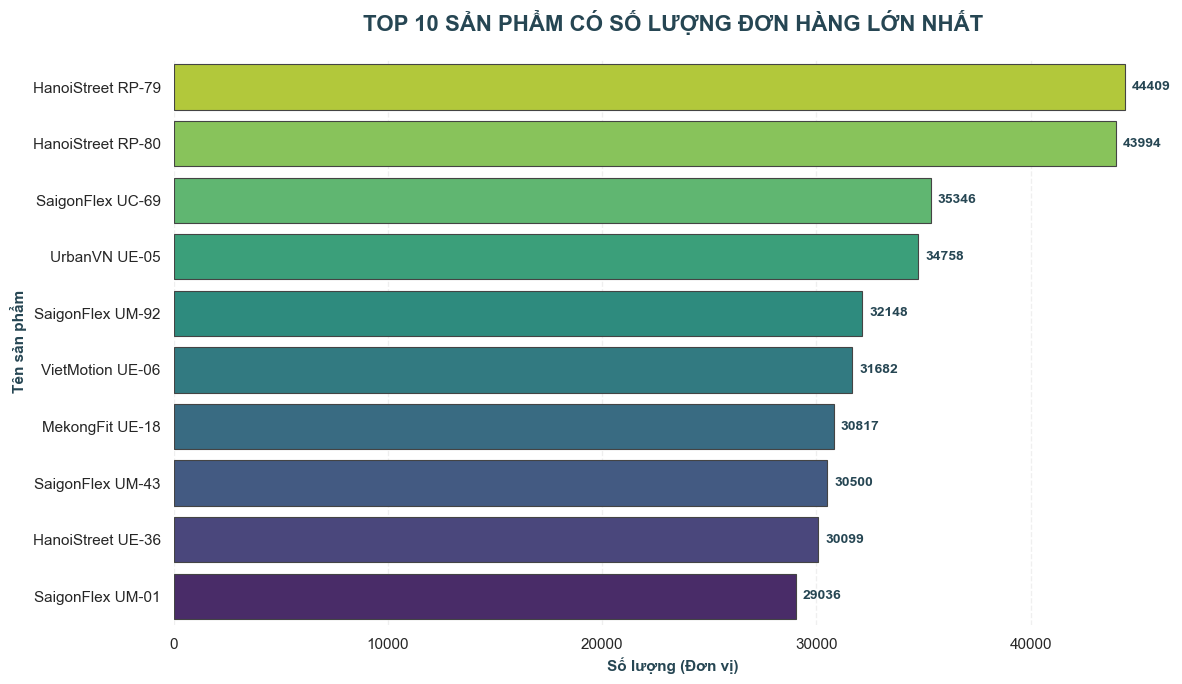

In [47]:
# Chuẩn bị dữ liệu
df_top_10 = top_10_largest.reset_index()
df_top_10.columns = ['Product', 'Quantity']

sns.set_style("white")
plt.figure(figsize=(12, 7), dpi=100)
colors = sns.color_palette("viridis_r", n_colors=10)

# Vẽ biểu đồ ngang (Horizontal Bar Chart)
barplot = sns.barplot(
    x='Quantity',
    y='Product',
    data=df_top_10,
    palette=colors,
    edgecolor='#444444',
    linewidth=0.8
)

plt.title('TOP 10 SẢN PHẨM CÓ SỐ LƯỢNG ĐƠN HÀNG LỚN NHẤT',
          fontsize=16, fontweight='bold', color='#264653', pad=20)
plt.xlabel('Số lượng (Đơn vị)', fontsize=11, fontweight='bold', color='#264653')
plt.ylabel('Tên sản phẩm', fontsize=11, fontweight='bold', color='#264653')

# Hiển thị số lượng cụ thể trên mỗi cột (Data Labels)
for i in barplot.containers:
    barplot.bar_label(i, padding=5, fontweight='bold', color='#264653', fontsize=10)

sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
# Lấy top 10 sản phẩm có lượt đặt hàng thấp nhất
top_10_smallest = top_products.nsmallest(10)

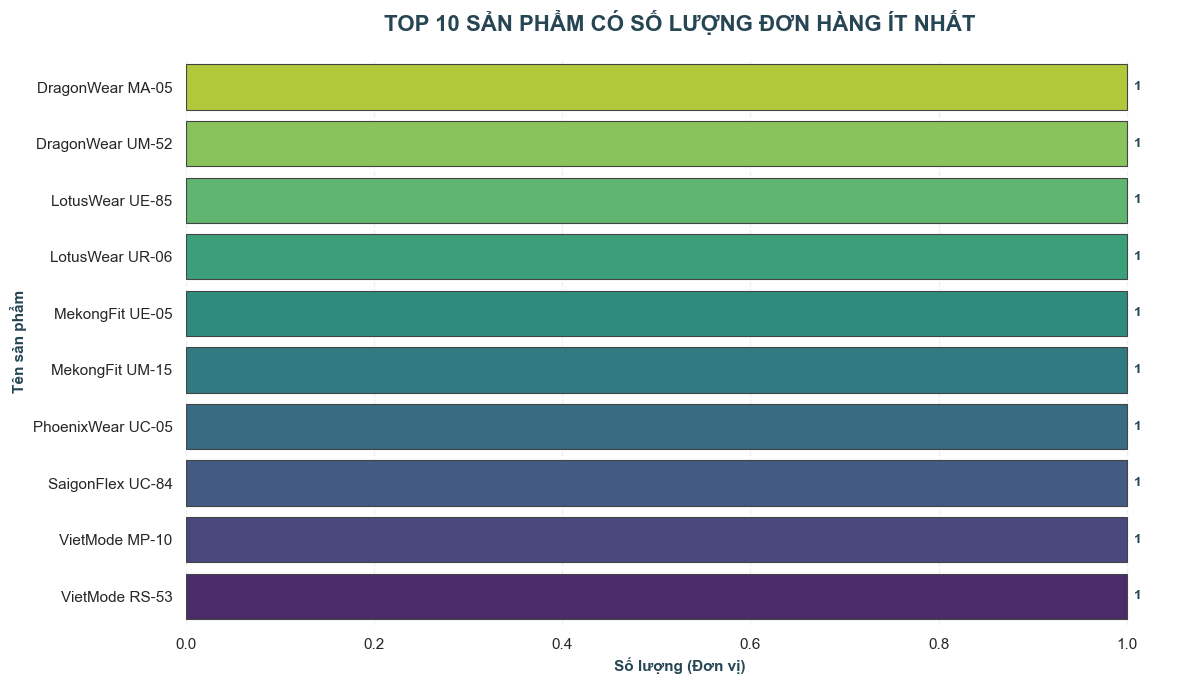

In [49]:
# Trực quan
df_top_10 = top_10_smallest.reset_index()
df_top_10.columns = ['Product', 'Quantity']

plt.figure(figsize=(12, 7), dpi=100)
colors = sns.color_palette("viridis_r", n_colors=10)

# Vẽ biểu đồ ngang (Horizontal Bar Chart)
barplot = sns.barplot(
    x='Quantity',
    y='Product',
    data=df_top_10,
    palette=colors,
    edgecolor='#444444',
    linewidth=0.8
)

plt.title('TOP 10 SẢN PHẨM CÓ SỐ LƯỢNG ĐƠN HÀNG ÍT NHẤT',
          fontsize=16, fontweight='bold', color='#264653', pad=20)
plt.xlabel('Số lượng (Đơn vị)', fontsize=11, fontweight='bold', color='#264653')
plt.ylabel('Tên sản phẩm', fontsize=11, fontweight='bold', color='#264653')

# Hiển thị số lượng cụ thể trên mỗi cột (Data Labels)
for i in barplot.containers:
    barplot.bar_label(i, padding=5, fontweight='bold', color='#264653', fontsize=10)

sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()

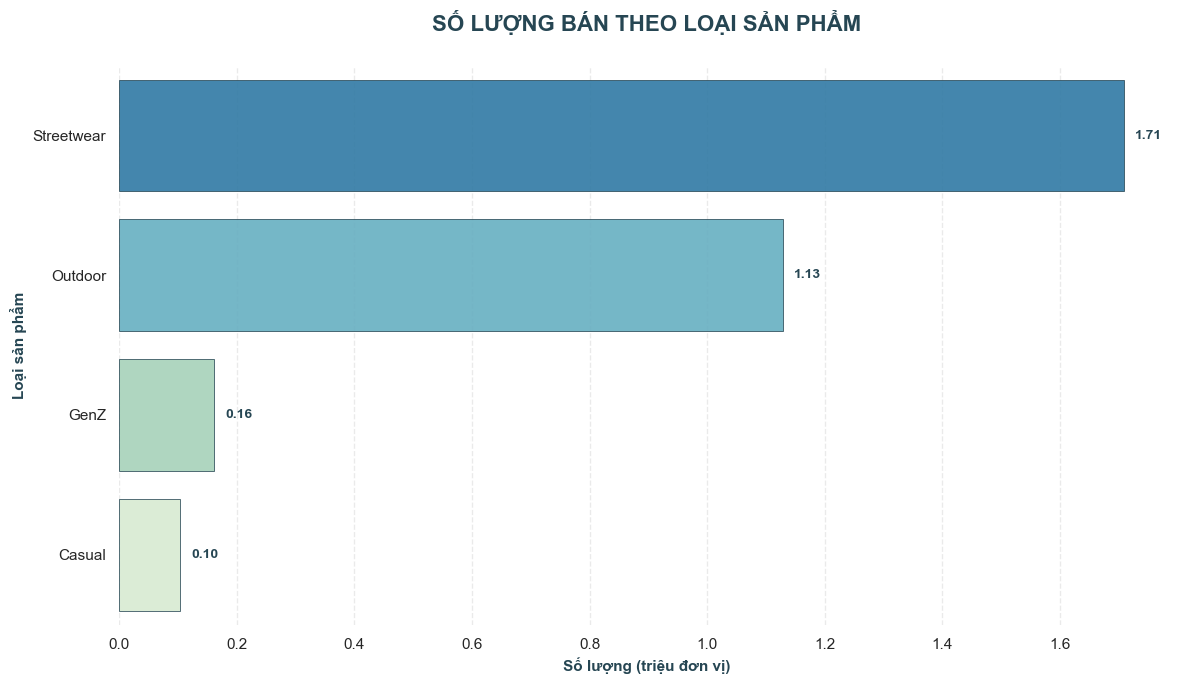

In [50]:
# Top các loại hàng mua nhiều
df_category_sold = df1.groupby('category')['net_quantity'].sum().sort_values(ascending=False)
df_category_sold = df_category_sold.reset_index()
df_category_sold.columns = ['Category', 'Quantity']
df_category_sold['Quantity'] = df_category_sold['Quantity']/1e6

sns.set_style("white") # Nền trắng hiện đại
plt.figure(figsize=(12, 7), dpi=100)
colors = sns.color_palette("GnBu_r", n_colors=len(df_category_sold))

# Vẽ biểu đồ ngang (Horizontal Bar Chart)
barplot = sns.barplot(
    x='Quantity',
    y='Category',
    data=df_category_sold,
    palette=colors,
    edgecolor='#264653',
    linewidth=0.6,
    alpha=0.9
)

plt.title('SỐ LƯỢNG BÁN THEO LOẠI SẢN PHẨM',
          fontsize=16, fontweight='bold', color='#264653', pad=25)
plt.xlabel('Số lượng (triệu đơn vị)', fontsize=11, fontweight='bold', color='#264653')
plt.ylabel('Loại sản phẩm', fontsize=11, fontweight='bold', color='#264653')

for i in barplot.containers:
    barplot.bar_label(i, fmt='%.2f', padding=8, fontweight='bold', color='#264653', fontsize=10)

sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## **QUẢN LÍ TỒN KHO**

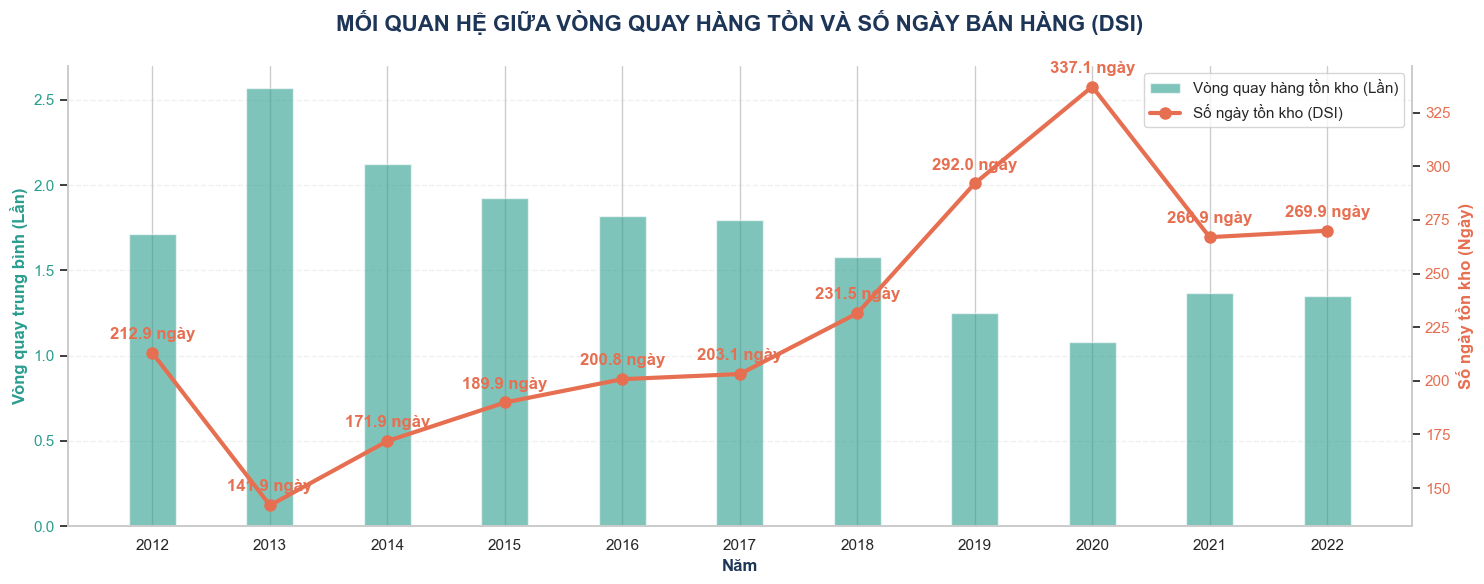

In [51]:
# Tính hiệu suất kho, chỉ dựa trên số hàng tồn ghi nhận, chưa tính những trường hợp hoàn hàng chưa được cập nhật
inventory_products = pd.merge(inventory, products[['product_id', 'cogs']], on='product_id', how='left')

inventory_products['total_cogs'] = inventory_products['units_sold'] * inventory_products['cogs']
inventory_products['inventory_value'] = inventory_products['stock_on_hand'] * inventory_products['cogs']

yearly_inventory = inventory_products.groupby(['year', 'product_id']).agg({
    'total_cogs': 'sum',
    'inventory_value': 'mean'
})

yearly_inventory['turnover'] = yearly_inventory['total_cogs'] / yearly_inventory['inventory_value']
yearly_performance = yearly_inventory.groupby('year')['turnover'].mean().reset_index()
yearly_performance['dsi'] = 365.0 / yearly_performance['turnover']

color_turnover = '#2a9d8f'
color_dsi = '#e76f51'
color_text = '#1d3557'

sns.set_style("whitegrid")
fig, ax1 = plt.subplots(figsize=(15, 6), dpi=100)

# vẽ vòng quay hàng tồn
bars = ax1.bar(yearly_performance['year'].astype(str), yearly_performance['turnover'],
               color=color_turnover, alpha=0.6, width=0.4, label='Vòng quay hàng tồn kho (Lần)')

ax1.set_ylabel('Vòng quay trung bình (Lần)', color=color_turnover, fontweight='bold', fontsize=12)
ax1.set_xlabel('Năm', fontweight='bold', color=color_text)
ax1.tick_params(axis='y', labelcolor=color_turnover)

# Vẽ dsi
ax2 = ax1.twinx()
ax2.grid(False)
ax2.plot(yearly_performance['year'].astype(str), yearly_performance['dsi'],
         color=color_dsi, marker='o', markersize=8, linewidth=3, label='Số ngày tồn kho (DSI)')

ax2.set_ylabel('Số ngày tồn kho (Ngày)', color=color_dsi, fontweight='bold', fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_dsi)

for i, txt in enumerate(yearly_performance['dsi']):
    ax2.annotate(f'{txt:.1f} ngày', (i, yearly_performance['dsi'][i]),
                 textcoords="offset points", xytext=(0,10), ha='center',
                 color=color_dsi, fontweight='bold')

sns.despine(right=False)
plt.title('MỐI QUAN HỆ GIỮA VÒNG QUAY HÀNG TỒN VÀ SỐ NGÀY BÁN HÀNG (DSI)',
          fontsize=16, fontweight='bold', color=color_text, pad=25)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=True)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

- Vòng quay hàng tồn kho có xu hướng giảm liên tục từ 2013 đến 2020, thời gian giải phóng kho tăng từ 141.9 ngày lên mức cao kỷ lục 337.1 ngày(2020) trước khi ổn định ở mức 270 ngày(2022).
- Không chỉ ảnh hưởng đến lượng vốn lưu động còn đọng lại trong kho, cần tính đến sức khỏe tồn kho để kiếm tra tình trạng "thừa hàng cũ - thiếu hàng mới"
- Đề xuất xử lý hàng tồn kho bằng các chương trình khuyến mãi, xả hàng với những sản phẩm có dsi cao để thu hồi vốn

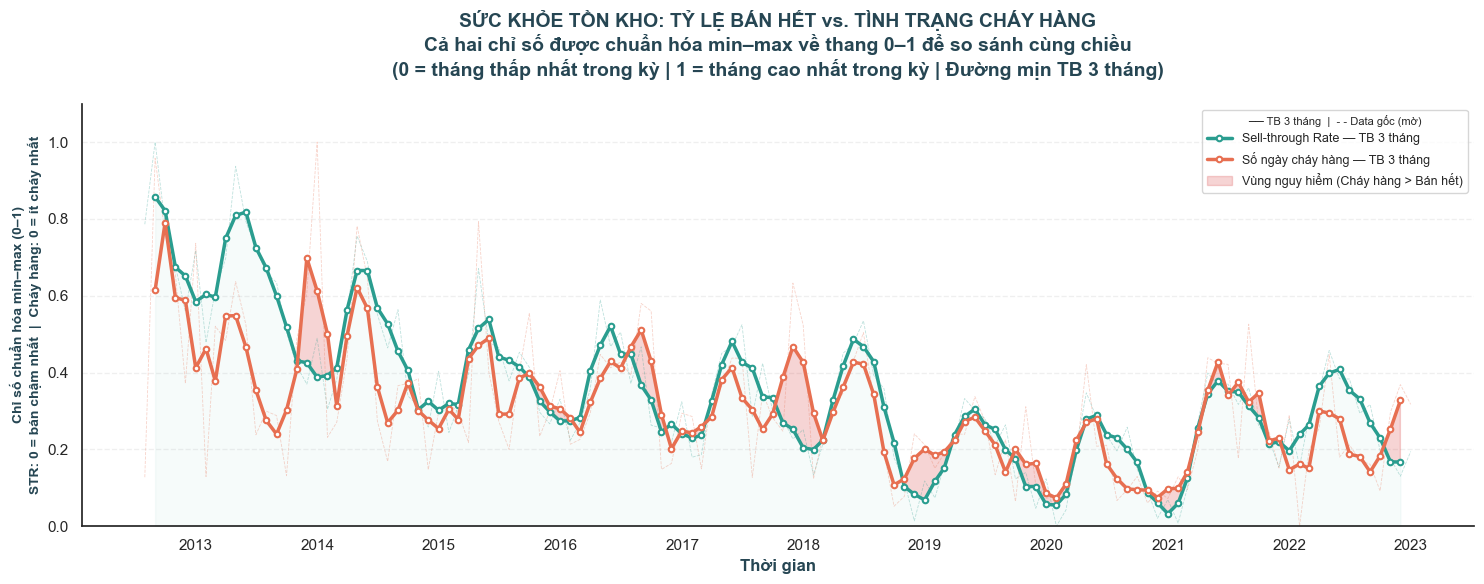

In [52]:
df_inv_monthly = inventory.groupby('snapshot_date').agg({
    'stockout_days': 'mean',
    'fill_rate': 'mean',
    'sell_through_rate': 'mean',
    'stockout_flag': 'sum'
}).reset_index()
df_inv_monthly['snapshot_date'] = pd.to_datetime(df_inv_monthly['snapshot_date'])

# Chuẩn hóa về thang 0-1
df_inv_monthly['STR_norm'] = (
    (df_inv_monthly['sell_through_rate'] - df_inv_monthly['sell_through_rate'].min()) /
    (df_inv_monthly['sell_through_rate'].max() - df_inv_monthly['sell_through_rate'].min())
)
df_inv_monthly['stockout_norm'] = (
    (df_inv_monthly['stockout_days'] - df_inv_monthly['stockout_days'].min()) /
    (df_inv_monthly['stockout_days'].max() - df_inv_monthly['stockout_days'].min())
)

# Rolling average 3 tháng
df_inv_monthly['STR_rolling']      = df_inv_monthly['STR_norm'].rolling(3, center=True).mean()
df_inv_monthly['stockout_rolling'] = df_inv_monthly['stockout_norm'].rolling(3, center=True).mean()

# --- THIẾT LẬP MÀU SẮC ---
color_str  = '#2a9d8f'
color_out  = '#e76f51'
color_text = '#264653'
color_danger = '#d62828'

sns.set_style("white")
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)

# Vẽ data gốc (mờ, làm nền) — có label rõ ràng
ax.plot(df_inv_monthly['snapshot_date'], df_inv_monthly['STR_norm'],
        color=color_str, linewidth=0.6, alpha=0.3, linestyle='--',
        label='STR theo tháng (data gốc)')
ax.plot(df_inv_monthly['snapshot_date'], df_inv_monthly['stockout_norm'],
        color=color_out, linewidth=0.6, alpha=0.3, linestyle='--',
        label='Cháy hàng theo tháng (data gốc)')

# Vẽ rolling average (đường chính)
ax.plot(df_inv_monthly['snapshot_date'], df_inv_monthly['STR_rolling'],
        color=color_str, linewidth=2.5, marker='o', markersize=4,
        markerfacecolor='white', markeredgewidth=1.5,
        label='Sell-through Rate — TB 3 tháng')
ax.fill_between(df_inv_monthly['snapshot_date'], df_inv_monthly['STR_rolling'],
                color=color_str, alpha=0.04)

ax.plot(df_inv_monthly['snapshot_date'], df_inv_monthly['stockout_rolling'],
        color=color_out, linewidth=2.5, marker='o', markersize=4,
        markerfacecolor='white', markeredgewidth=1.5,
        label='Số ngày cháy hàng — TB 3 tháng')

# Vùng nguy hiểm — màu đỏ
ax.fill_between(df_inv_monthly['snapshot_date'],
                df_inv_monthly['STR_rolling'], df_inv_monthly['stockout_rolling'],
                where=(df_inv_monthly['stockout_rolling'] > df_inv_monthly['STR_rolling']),
                interpolate=True, color=color_danger, alpha=0.2,
                label='Vùng nguy hiểm (Cháy hàng > Bán hết)')

# Định dạng trục X
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
plt.xticks(rotation=0, ha='center')

ax.set_ylim(0, 1.1)
ax.set_ylabel(
    'Chỉ số chuẩn hóa min–max (0–1)\n'
    'STR: 0 = bán chậm nhất  |  Cháy hàng: 0 = ít cháy nhất',
    fontweight='bold', color=color_text, fontsize=10
)
ax.set_xlabel('Thời gian', fontweight='bold', color=color_text)
ax.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()

# Legend 
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[2:], labels[2:],
          loc='upper right', frameon=True, fontsize=9,
          title='── TB 3 tháng  |  - - Data gốc (mờ)',
          title_fontsize=8)

plt.title(
    'SỨC KHỎE TỒN KHO: TỶ LỆ BÁN HẾT vs. TÌNH TRẠNG CHÁY HÀNG\n'
    'Cả hai chỉ số được chuẩn hóa min–max về thang 0–1 để so sánh cùng chiều\n'
    '(0 = tháng thấp nhất trong kỳ | 1 = tháng cao nhất trong kỳ | Đường mịn TB 3 tháng)',
    fontsize=14, fontweight='bold', color=color_text, pad=20
)

plt.tight_layout()
plt.show()

- Xu hướng dài hạn — Cả 2 chỉ số đều giảm: STR và stockout_days đều giảm dần từ 2012 → 2021, cho thấy doanh nghiệp bán được ít hàng hơn so với lượng tồn kho, nhưng đồng thời cũng ít cháy hàng hơn — dấu hiệu của tình trạng tồn kho dư thừa tích lũy theo thời gian.

- Các giai đoạn nguy hiểm (vùng đỏ): Xuất hiện rải rác tại 2014, 2016–2017, 2018, 2019, 2022 — đây là các tháng cháy hàng vượt tỉ lệ bán, tức là nhu cầu bùng phát đột ngột mà tồn kho không kịp đáp ứng, thường trùng với các đợt khuyến mãi lớn hoặc mùa cao điểm.

- Giai đoạn 2019–2021 đáng chú ý: Cả STR lẫn stockout đều xuống rất thấp và gần như bằng nhau — doanh nghiệp vừa bán chậm vừa không cháy hàng, đây là dấu hiệu nhu cầu suy yếu toàn diện.

=> Doanh nghiệp đang có xu hướng over-stock dài hạn — nên cân nhắc tối ưu lại chính sách nhập hàng, tập trung tồn kho vào các SKU có STR cao thay vì nhập đều tất cả danh mục. Các đợt cháy hàng ngắn hạn (vùng đỏ) cần được dự báo sớm hơn, đặc biệt trước các chiến dịch khuyến mãi.

In [53]:
# Gross revenue + discount theo tháng + product 
order_items_dated = order_items.merge(
    orders[['order_id', 'order_date']], on='order_id'
)
order_items_dated['snapshot_date'] = (
    order_items_dated['order_date']
    .dt.to_period('M').dt.to_timestamp()
)
order_items_dated['gross_revenue'] = (
    order_items_dated['quantity'] * order_items_dated['unit_price']
)

product_monthly = (
    order_items_dated
    .groupby(['snapshot_date', 'product_id'], as_index=False)
    .agg(
        gross_revenue  = ('gross_revenue',   'sum'),
        discount_total = ('discount_amount', 'sum'),
    )
)

# Refund theo order_date 
product_monthly_refund = (
    returns
    .merge(orders[['order_id', 'order_date']], on='order_id')
    .assign(
        snapshot_date=lambda x: pd.to_datetime(x['order_date']).dt.to_period('M').dt.to_timestamp()
    )
    .groupby(['snapshot_date', 'product_id'], as_index=False)
    .agg(total_refund=('refund_amount', 'sum'))
)

# Gắn vào inventory 
inv = inventory.copy()
inv['snapshot_date'] = inv['snapshot_date'].dt.to_period('M').dt.to_timestamp()

inv = (
    inv
    .merge(product_monthly,        on=['snapshot_date', 'product_id'], how='left')
    .merge(product_monthly_refund, on=['snapshot_date', 'product_id'], how='left')
)
inv['gross_revenue']  = inv['gross_revenue'].fillna(0)
inv['discount_total'] = inv['discount_total'].fillna(0)
inv['total_refund']   = inv['total_refund'].fillna(0)

# net_revenue = gross − discount − refund
inv['net_revenue'] = (
    inv['gross_revenue'] - inv['discount_total'] - inv['total_refund']
).clip(lower=0)

# Tính lost_sales trên net_revenue 
inv['days_in_month'] = inv['snapshot_date'].dt.days_in_month
inv['active_days']   = (inv['days_in_month'] - inv['stockout_days']).clip(lower=1)

inv['daily_revenue'] = np.where(
    (inv['net_revenue'] > 0) & (inv['stockout_days'] > 0),
    inv['net_revenue'] / inv['active_days'],
    inv['net_revenue'] / inv['days_in_month']
)

inv['lost_sales'] = np.where(
    inv['stockout_days'] > 0,
    (inv['daily_revenue'] * inv['stockout_days']).clip(upper=inv['net_revenue']),
    0
)

# Gộp lên tháng 
df_inv_monthly = (
    inv
    .groupby('snapshot_date', as_index=False)
    .agg(
        stockout_days     = ('stockout_days',     'mean'),
        fill_rate         = ('fill_rate',         'mean'),
        sell_through_rate = ('sell_through_rate', 'mean'),
        stockout_flag     = ('stockout_flag',     'sum'),
        Gross_Revenue     = ('gross_revenue',     'sum'),
        Discount          = ('discount_total',    'sum'),
        Refund            = ('total_refund',      'sum'),
        Net_Revenue       = ('net_revenue',       'sum'),
        lost_sales        = ('lost_sales',        'sum'),
    )
)
df_inv_monthly['potential_revenue'] = (
    df_inv_monthly['Net_Revenue'] + df_inv_monthly['lost_sales']
)

# Gộp lên năm 
df_yearly = (
    df_inv_monthly
    .assign(year=df_inv_monthly['snapshot_date'].dt.year)
    .groupby('year', as_index=False)
    .agg(
        Gross_Revenue = ('Gross_Revenue', 'sum'),
        Discount      = ('Discount',      'sum'),
        Refund        = ('Refund',        'sum'),
        Net_Revenue   = ('Net_Revenue',   'sum'),
        lost_sales    = ('lost_sales',    'sum'),
    )
)
df_yearly['discount_rate']  = df_yearly['Discount']    / df_yearly['Gross_Revenue'] * 100
df_yearly['return_rate']    = df_yearly['Refund']      / df_yearly['Gross_Revenue'] * 100
df_yearly['lost_sales_pct'] = df_yearly['lost_sales']  / df_yearly['Net_Revenue']  * 100

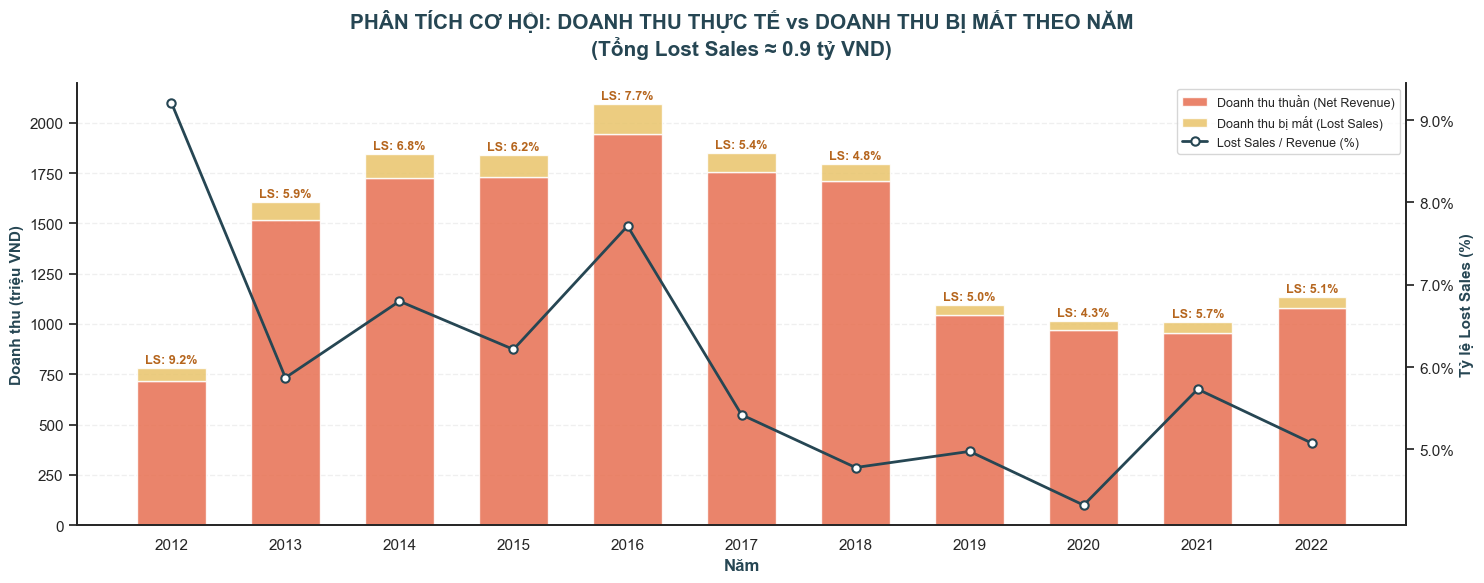

In [54]:
# --- THIẾT LẬP MÀU SẮC ---
color_actual = '#e76f51'
color_lost   = '#e9c46a'
color_text   = '#264653'

sns.set_style("white")
fig, ax1 = plt.subplots(figsize=(15, 6), dpi=100)

# Stacked bar
bars1 = ax1.bar(df_yearly['year'], df_yearly['Net_Revenue']/1e6,
                width=0.6, color=color_actual, alpha=0.85, label='Doanh thu thuần (Net Revenue)')
bars2 = ax1.bar(df_yearly['year'], df_yearly['lost_sales']/1e6,
                width=0.6, color=color_lost, alpha=0.85, label='Doanh thu bị mất (Lost Sales)',
                bottom=df_yearly['Net_Revenue']/1e6)
ax1.set_xlabel('Năm', fontweight='bold', color=color_text)
ax1.set_xticks(df_yearly['year'])
ax1.set_xticklabels(df_yearly['year'], rotation=0)
ax1.set_ylabel('Doanh thu (triệu VND)', fontweight='bold', color=color_text, fontsize=11)

# Thêm label % lên trên mỗi cột
for bar1, bar2, pct in zip(bars1, bars2, df_yearly['lost_sales_pct']):
    total_height = bar1.get_height() + bar2.get_height()
    ax1.text(bar1.get_x() + bar1.get_width()/2, total_height + 10,
             f'LS: {pct:.1f}%',  
             ha='center', va='bottom',
             fontsize=9, fontweight='bold', color='#b5651d')

# Trục phải: % Lost Sales
ax2 = ax1.twinx()
ax2.plot(df_yearly['year'], df_yearly['lost_sales_pct'],
         color=color_text, linewidth=2, marker='o', markersize=6,
         markerfacecolor='white', markeredgewidth=1.5,
         label='Lost Sales / Revenue (%)')
ax2.set_ylabel('Tỷ lệ Lost Sales (%)', fontweight='bold', color=color_text, fontsize=11)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

sns.despine(right=False)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=True, fontsize=9)

plt.title('PHÂN TÍCH CƠ HỘI: DOANH THU THỰC TẾ vs DOANH THU BỊ MẤT THEO NĂM\n'
          f'(Tổng Lost Sales ≈ {df_yearly["lost_sales"].sum()/1e9:.1f} tỷ VND)',
          fontsize=15, fontweight='bold', color=color_text, pad=20)

plt.tight_layout()
plt.show()

- Xu hướng doanh thu (cột đỏ): Đỉnh cao nhất tại 2016, sau đó giảm mạnh từ 2017 trở đi — nhất quán với phân tích CR và Revenue ở các biểu đồ trước 2019 – 2022 duy trì ở mức thấp, chưa phục hồi về mức 2013 – 2018

- Lost Sales (phần vàng): Tỷ lệ Lost Sales cao nhất 2012 (9.2%) và 2016 (7.7%) — trùng với các giai đoạn doanh thu tăng mạnh, tức là cầu vượt cung khi bán tốt. Sau 2017, tỷ lệ giảm xuống 4–6% — không phải vì quản lý tồn kho tốt hơn mà vì nhu cầu suy yếu.

=> Nghịch lý quan trọng: khi doanh thu cao thì Lost Sales cũng cao → doanh nghiệp chưa dự báo được nhu cầu đỉnh điểm để chuẩn bị tồn kho. Giai đoạn 2013–2016 nếu tối ưu tồn kho có thể thu thêm đáng kể doanh thu.

In [55]:
def plot_lost_sales_quantification(df_inv_monthly):
    """
    Định lượng Lost Sales và ROI của việc cải thiện tồn kho
    """
    df_inv = df_inv_monthly.copy()
    df_inv['month'] = pd.to_datetime(df_inv['snapshot_date'])

    total_lost  = df_inv['lost_sales'].sum()
    annual_lost = total_lost / df_inv['month'].nunique() * 12
    annual_rev  = df_inv['Net_Revenue'].sum() / df_inv['month'].nunique() * 12

    reductions     = [0.1, 0.25, 0.5, 0.75, 1.0]
    recovered      = [annual_lost * r for r in reductions]
    carrying_rates = [0.60, 0.70, 0.80, 1.00, 1.30]
    costs          = [r * cr for r, cr in zip(recovered, carrying_rates)]

    sns.set_style("white")
    fig = plt.figure(figsize=(16, 11))
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.25)

    # Biểu đồ 1: Lost Sales theo tháng
    ax1 = fig.add_subplot(gs[0, :])
    ax1.fill_between(df_inv['month'], df_inv['lost_sales'] / 1e6,
                     color='#e76f51', alpha=0.2, label='Doanh thu bị mất (Lost Sales)')
    ax1.plot(df_inv['month'], df_inv['lost_sales'] / 1e6,
             color='#e76f51', linewidth=2.5, marker='o', markersize=4)
    ax1.plot(df_inv['month'], df_inv['Net_Revenue'] / 1e6,
             color='#264653', linewidth=1.5, linestyle='--', alpha=0.5, label='Doanh thu thuần thực tế')
    ax1.set_title('BIẾN ĐỘNG DOANH THU BỊ MẤT (LOST SALES) THEO THÁNG',
                  fontsize=14, fontweight='bold', pad=15)
    ax1.set_ylabel('Triệu VND', fontweight='bold')
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}M'))
    ax1.set_xlabel('Thời gian', fontweight='bold')
    ax1.legend(frameon=True, loc='upper left')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # Biểu đồ 2: Sensitivity — doanh thu có thể thu hồi
    ax2 = fig.add_subplot(gs[1, 0])
    labels = [f'Giảm {int(r*100)}%' for r in reductions]
    bars = ax2.barh(labels, [r / 1e6 for r in recovered],
                    color=sns.color_palette("viridis_r", 5), height=0.6)
    ax2.set_title('TIỀN CÓ THỂ THU HỒI NẾU CẢI THIỆN TỒN KHO\n(Ước tính doanh thu hồi phục/năm)',
                  fontsize=12, fontweight='bold', pad=15)
    for bar in bars:
        width = bar.get_width()
        ax2.text(width + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{width:,.0f} Tr', va='center', fontweight='bold', color='#264653')
    ax2.set_xlabel('Triệu VND / Năm')
    ax2.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)

    # Biểu đồ 3: Thu hồi vs Chi phí
    ax3 = fig.add_subplot(gs[1, 1])
    x     = np.arange(len(labels))
    width = 0.35

    bars_r = ax3.bar(x - width/2, [r / 1e6 for r in recovered],
                     width, label='Doanh thu thu hồi',
                     color='#2a9d8f', edgecolor='#264653', linewidth=0.5)
    bars_c = ax3.bar(x + width/2, [c / 1e6 for c in costs],
                     width, label='Chi phí đầu tư ước tính',
                     color='#e76f51', alpha=0.7, edgecolor='#264653', linewidth=0.5)

    # Nhãn giá trị trên mỗi bar
    for bar in bars_r:
        h = bar.get_height()
        if h > 2:  # chỉ hiện khi bar > 2 triệu
            ax3.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                    f'{h:,.0f}Tr', ha='center', va='bottom', fontsize=8, color='#264653')

    for bar in bars_c:
        h = bar.get_height()
        if h > 2:
            ax3.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                    f'{h:,.0f}Tr', ha='center', va='bottom', fontsize=8, color='#264653')

    ax3.set_title('THU HỒI vs CHI PHÍ ĐẦU TƯ TỒN KHO\n',
                  fontsize=12, fontweight='bold', pad=15)
    ax3.set_ylabel('Triệu VND / Năm', fontweight='bold')
    ax3.set_xlabel('Mức giảm Stockout', fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(labels)
    ax3.legend(frameon=True)
    sns.despine(ax=ax3)

    plt.suptitle('PHÂN TÍCH TỐI ƯU HÓA TỒN KHO & CƠ HỘI DOANH THU',
                 fontsize=18, fontweight='bold', y=0.98, color='#264653')
    plt.tight_layout()
    plt.show()

    # Nhận định
    optimal_idx = max(i for i, (r, c) in enumerate(zip(recovered, costs)) if r > c)
    optimal_pct = int(reductions[optimal_idx] * 100)

    print(f"{'='*55}")
    print(f"{'NHẬN ĐỊNH VỀ CƠ HỘI TỒN KHO':^55}")
    print(f"{'='*55}")
    print(f"- Doanh thu thuần trung bình/năm:  {annual_rev/1e6:>8.0f} triệu VND")
    print(f"- Tổng thất thoát (Lost Sales):    {total_lost/1e9:>8.2f} tỷ VND")
    print(f"- Thất thoát trung bình/năm:       {annual_lost/1e6:>8.0f} triệu VND")
    print(f"- Lost sales / Doanh thu:          {annual_lost/annual_rev*100:>8.2f}%")
    print(f"- Kịch bản tối ưu: Giảm {optimal_pct}% Stockout")
    print(f"  => Thu hồi: ~{recovered[optimal_idx]/1e6:,.0f} triệu VND/năm")
    print(f"  => Chi phí ước tính: ~{costs[optimal_idx]/1e6:,.0f} triệu VND/năm")
    print(f"  => Lợi nhuận ròng: ~{(recovered[optimal_idx]-costs[optimal_idx])/1e6:,.0f} triệu VND/năm")
    print(f"{'='*55}")

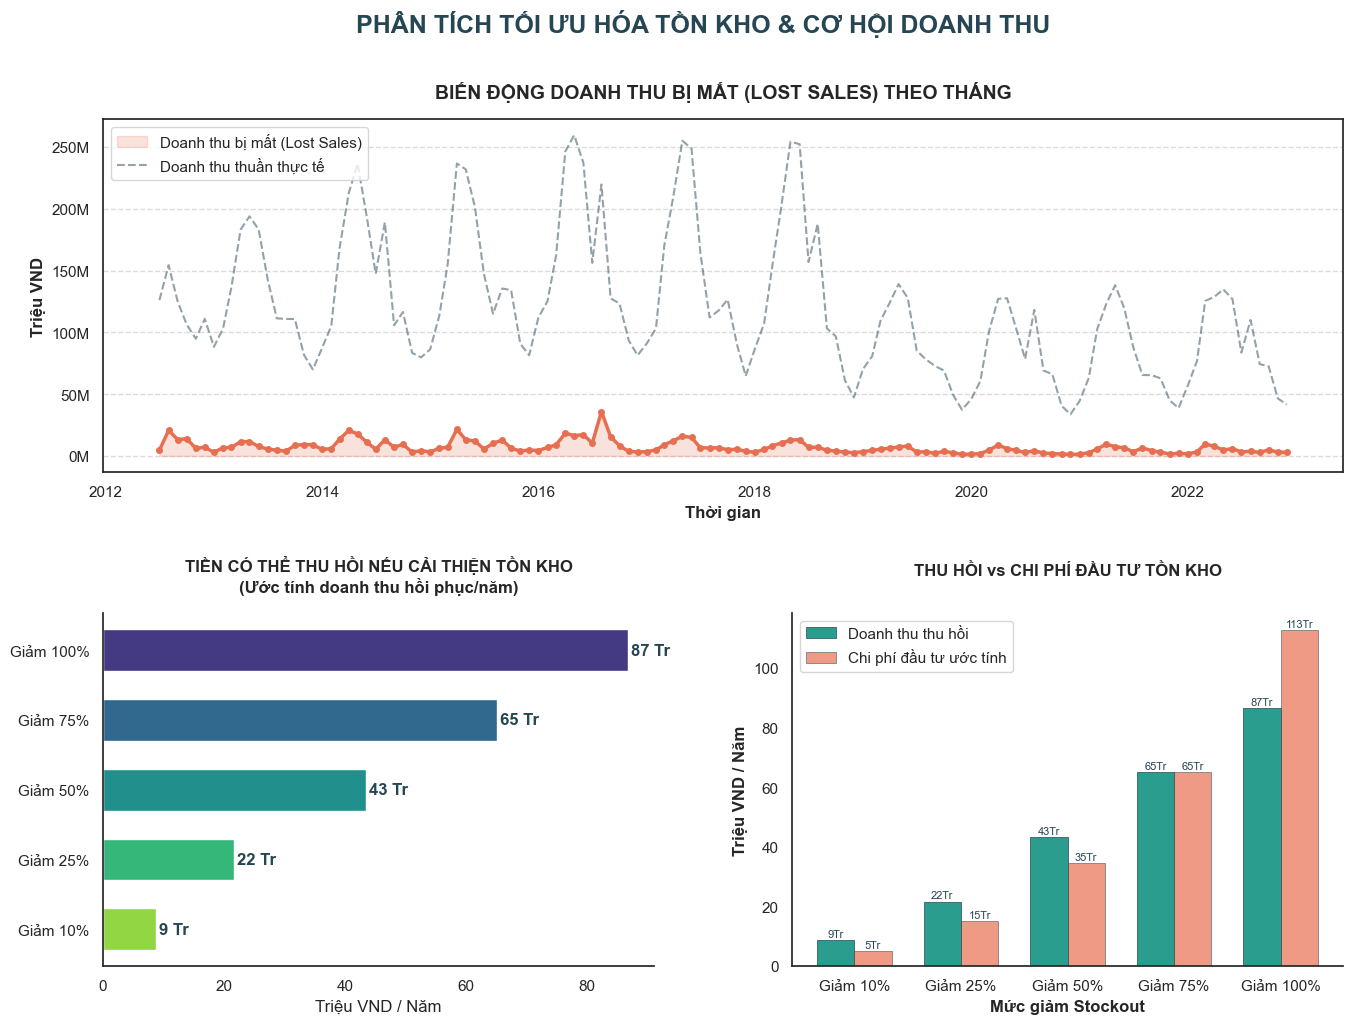

              NHẬN ĐỊNH VỀ CƠ HỘI TỒN KHO              
- Doanh thu thuần trung bình/năm:      1443 triệu VND
- Tổng thất thoát (Lost Sales):        0.91 tỷ VND
- Thất thoát trung bình/năm:             87 triệu VND
- Lost sales / Doanh thu:              6.01%
- Kịch bản tối ưu: Giảm 50% Stockout
  => Thu hồi: ~43 triệu VND/năm
  => Chi phí ước tính: ~35 triệu VND/năm
  => Lợi nhuận ròng: ~9 triệu VND/năm


In [56]:
plot_lost_sales_quantification(df_inv_monthly)

## **DỰ ĐOÁN VÀ ĐỀ XUẤT**

In [57]:
def plot_revenue_forecast_range(df_sales):
    """
    Dự báo trend 2023-2024 dựa trên decomposition
    -> Ngoại suy trend + seasonal pattern từ lịch sử
    """
    df = df_sales.copy()
    df['year']  = df['Date'].dt.year
    df['month'] = df['Date'].dt.month

    # Seasonal index từ Net_Revenue
    monthly = df.groupby(['year', 'month'])['Net_Revenue'].sum().reset_index()
    annual  = monthly.groupby('year')['Net_Revenue'].sum().reset_index()
    annual.rename(columns={'Net_Revenue': 'annual_revenue'}, inplace=True)
    monthly = monthly.merge(annual, on='year')
    monthly['seasonal_index'] = monthly['Net_Revenue'] / (monthly['annual_revenue'] / 12)
    seasonal_avg = monthly.groupby('month')['seasonal_index'].mean()

    # Trend: CAGR 3 năm gần nhất (2019-2022)
    rev_by_year = df.groupby('year')['Net_Revenue'].sum()
    cagr = (rev_by_year[2022] / rev_by_year[2019]) ** (1/3) - 1
    base_annual = rev_by_year[2022]

    # Dự báo 2023-2024
    forecast = []
    for year in [2023, 2024]:
        for month in range(1, 13):
            if year == 2024 and month > 7:
                break
            predicted = base_annual * ((1 + cagr) ** (year - 2022))
            monthly_val = predicted / 12 * seasonal_avg[month]
            forecast.append({
                'date'     : pd.Timestamp(year=year, month=month, day=1),
                'predicted': monthly_val,
                'lower'    : monthly_val * 0.85,
                'upper'    : monthly_val * 1.15,
            })
    df_fc = pd.DataFrame(forecast)

    # Lịch sử theo tháng
    hist = df.groupby(df['Date'].dt.to_period('M'))['Net_Revenue'].sum().reset_index()
    hist['Date'] = hist['Date'].dt.to_timestamp()
    hist_recent = hist[hist['Date'] >= '2018-01-01']

    # --- VẼ BIỂU ĐỒ ---
    color_hist = '#264653'
    color_fc   = '#e76f51'
    color_text = '#264653'

    fig, ax = plt.subplots(figsize=(16, 6), dpi=100)
    sns.set_style("white")

    # Lịch sử
    ax.plot(hist_recent['Date'], hist_recent['Net_Revenue']/1e6,
            color=color_hist, linewidth=2, label='Doanh thu thuần thực tế', alpha=0.85)

    # Nối điểm cuối lịch sử với điểm đầu dự báo
    last_date    = hist_recent.iloc[-1]['Date']
    last_val     = hist_recent.iloc[-1]['Net_Revenue'] / 1e6
    first_fc_date = df_fc.iloc[0]['date']
    first_fc_val  = df_fc.iloc[0]['predicted'] / 1e6
    ax.plot([last_date, first_fc_date], [last_val, first_fc_val],
            color=color_fc, linestyle='--', linewidth=2)

    # Forecast
    ax.plot(df_fc['date'], df_fc['predicted']/1e6,
            color=color_fc, linewidth=2.5, linestyle='--', label='Dự báo xu hướng (CAGR)')
    ax.fill_between(df_fc['date'],
                    df_fc['lower']/1e6, df_fc['upper']/1e6,
                    color=color_fc, alpha=0.12, label='Khoảng biến động ±15%')

    # Vùng dự báo
    ax.axvspan(pd.Timestamp('2023-01-01'), df_fc['date'].max(),
               color='#f2f2f2', alpha=0.5, zorder=0)

    # Text "VÙNG DỰ BÁO"
    ax.text(pd.Timestamp('2023-06-01'), 0.88,
            'VÙNG DỰ BÁO', transform=ax.get_xaxis_transform(),
            fontsize=11, color='#95a5a6', fontweight='bold', alpha=0.8,
            va='top')

    # Định dạng trục X
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xticks(rotation=0, ha='center')

    ax.set_title('KỊCH BẢN TĂNG TRƯỞNG DOANH THU THUẦN 2023–2024',
                 fontsize=15, fontweight='bold', loc='left', pad=20, color=color_text)
    ax.set_ylabel('Doanh thu thuần (Triệu VND)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Năm', fontsize=11, fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,} Tr'))
    ax.legend(loc='upper left', frameon=True, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    sns.despine()

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*50}")
    print(f"{'KẾT QUẢ DỰ BÁO':^50}")
    print(f"{'='*50}")
    print(f"  CAGR 2019–2022   : {cagr*100:+.1f}%/năm")
    print(f"  Dự báo tổng 2023 : {df_fc[df_fc['date'].dt.year==2023]['predicted'].sum()/1e9:.2f} tỷ VND")
    print(f"  Dự báo 7T/2024   : {df_fc[df_fc['date'].dt.year==2024]['predicted'].sum()/1e9:.2f} tỷ VND")
    print(f"{'='*50}")

    return df_fc

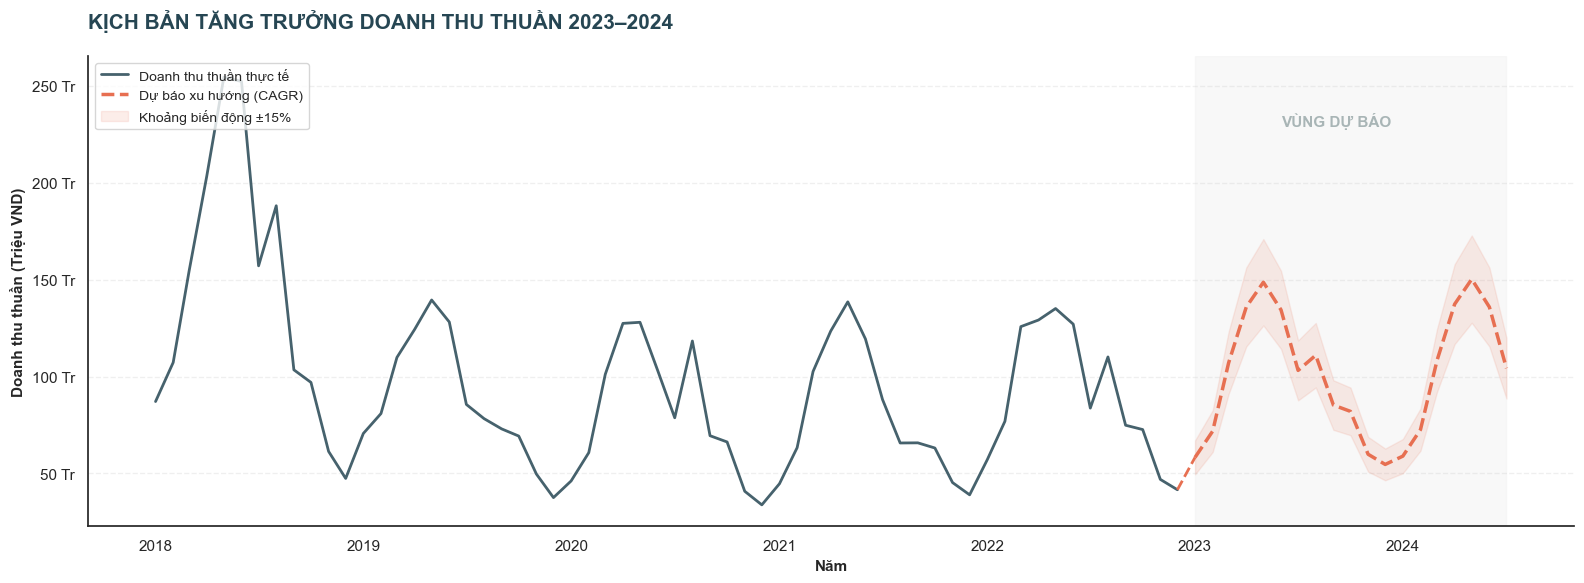


                  KẾT QUẢ DỰ BÁO                  
  CAGR 2019–2022   : +1.1%/năm
  Dự báo tổng 2023 : 1.15 tỷ VND
  Dự báo 7T/2024   : 0.77 tỷ VND


In [58]:
df_fc = plot_revenue_forecast_range(sales_full)

- Về "Sức khỏe" doanh nghiệp (Trend & CAGR): Doanh nghiệp đã đi qua thời kỳ hoàng kim (đỉnh cao năm 2018). Từ đó đến nay, xu hướng dài hạn đã giảm khoảng 35.9%.

  + Trạng thái hiện tại: Doanh nghiệp hiện đang duy trì ở một ngưỡng doanh thu mới, thấp hơn nhưng ổn định hơn.

- Về "Quy luật" kinh doanh (Seasonality): Quy luật mùa vụ cực kỳ rõ nét và nhất quán (đặc biệt là đỉnh Tuần 22). Điều này là "vũ khí" quan trọng nhất vì nó cho phép lập kế hoạch tồn kho và nhân sự chính xác gần như tuyệt đối.

  + Điểm yếu: Doanh thu phụ thuộc quá lớn vào các tháng giữa năm. Giai đoạn cuối năm (Quý 4) là "vùng trũng" kéo dài, gây lãng phí chi phí cố định nếu không có phương án tối ưu.

- Về "Tương lai" (Forecast 2023 - 2024): Với đà này, doanh thu năm 2023 dự kiến đạt khoảng 1.15 tỷ VND.

  + Cơ hội: Các đỉnh sóng mùa vụ trong dự báo vẫn chạm mức 150 Tr/tháng. Đây là những thời điểm phải "đánh mạnh" để bù đắp cho các tháng thấp điểm.

  + Rủi ro: Tỷ lệ nhiễu (Residual) 43.2% là khá cao. Điều này cảnh báo rằng có nhiều yếu tố bên ngoài (đối thủ, thị trường, hoặc vận hành nội bộ) đang làm doanh thu biến động khó lường.

- Tối ưu mùa vụ: Tập trung ngân sách marketing và nhân sự cho giai đoạn tháng 4 đến tháng 7. Đừng dàn trải nguồn lực cho những tháng cuối năm vì hiệu quả sinh lời thấp.

- Khai phá "Vùng trũng": Tìm kiếm các sản phẩm hoặc dịch vụ có tính mùa vụ ngược lại (bán chạy vào cuối năm) để lấp đầy khoảng trống doanh thu từ tháng 9 đến tháng 12.

- Kiểm soát chi phí: Với mức tăng trưởng CAGR chỉ 1%, nên tập trung vào việc tối ưu chi phí (cost optimization) thay vì chỉ chạy theo doanh số, để cải thiện lợi nhuận thực tế.

In [59]:
def plot_customer_segment_action_matrix(df_sales, df_inv_monthly):
    """
    Ma trận Impact vs Effort cho các đề xuất hành động
    """
    # Tính các baseline
    annual_rev  = df_inv_monthly['Net_Revenue'].sum() / df_inv_monthly['snapshot_date'].nunique() * 12
    annual_lost = df_inv_monthly['lost_sales'].sum() / df_inv_monthly['snapshot_date'].nunique() * 12
    lost_pct    = annual_lost / annual_rev * 100  # ~6.01%

    # Các action với revenue_impact_pct có căn cứ từ data
    actions = [
        {
            # Căn cứ: lost_sales = 6.01% doanh thu, kịch bản tối ưu giảm 50%
            'name': 'Xử lý Stockout\nmùa cao điểm',
            'revenue_impact_pct': round(lost_pct * 0.5, 1),  # ~3.0%
            'effort': 2.5,
            'timeframe': 'Q1-Q2',
            'category': 'inventory',
            'basis': f'Lost sales={lost_pct:.1f}% DT, giảm 50%'
        },
        {
            # Căn cứ: cải thiện fill_rate trung bình hiện tại
            'name': 'Hệ thống dự báo AI\ngiảm nhiễu tồn kho',
            'revenue_impact_pct': round(lost_pct * 0.3, 1),  # ~1.8%
            'effort': 4.5,
            'timeframe': 'Q3-Q4',
            'category': 'inventory',
            'basis': 'Giảm thêm 30% lost sales còn lại'
        },
        {
            # Căn cứ: trend doanh thu giảm dài hạn quan sát từ biểu đồ
            'name': 'Phát triển Line hàng\nmới mùa thấp điểm',
            'revenue_impact_pct': 4.0,
            'effort': 4.0,
            'timeframe': 'Q3',
            'category': 'product',
            'basis': 'Lấp khoảng trống doanh thu mùa thấp điểm'
        },
        {
            # Căn cứ: giữ chân khách hàng hiện hữu rẻ hơn tìm khách mới 5x
            'name': 'Loyalty Program\ngiữ chân Top khách hàng',
            'revenue_impact_pct': 2.5,
            'effort': 2.5,
            'timeframe': 'Q2',
            'category': 'marketing',
            'basis': 'Retention cost < Acquisition cost'
        },
        {
            # Căn cứ: quick win vận hành, tác động nhỏ nhưng dễ làm
            'name': 'Kiểm soát\nchất lượng Promo',
            'revenue_impact_pct': 1.0,
            'effort': 1.5,
            'timeframe': 'Q1',
            'category': 'marketing',
            'basis': 'Loại bỏ promo kém hiệu quả'
        },
        {
            # Căn cứ: rút ngắn leadtime giảm stockout gián tiếp
            'name': 'Rút ngắn Leadtime\nvận hành kho',
            'revenue_impact_pct': 1.5,
            'effort': 3.5,
            'timeframe': 'Q2',
            'category': 'operations',
            'basis': 'Giảm stockout do chậm nhập hàng'
        }
    ]

    colors = {
        'inventory':  '#2a9d8f',
        'marketing':  '#e76f51',
        'product':    '#2c7bb6',
        'operations': '#8b5e83',
    }

    fig, ax = plt.subplots(figsize=(11, 8))

    # Quadrant
    ax.axhline(2.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axvline(3.0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.fill_between([0.5, 3.0], [2.5, 2.5], [5, 5], color='#d4edda', alpha=0.25)
    ax.fill_between([3.0, 5.5], [2.5, 2.5], [5, 5], color='#fff3cd', alpha=0.25)
    ax.fill_between([0.5, 3.0], [0.5, 0.5], [2.5, 2.5], color='#f0f0f0', alpha=0.25)
    ax.fill_between([3.0, 5.5], [0.5, 0.5], [2.5, 2.5], color='#f8d7da', alpha=0.25)

    ax.text(0.6, 4.7, 'Quick Wins', fontsize=10, color='#155724', fontweight='bold')
    ax.text(3.1, 4.7, 'Major Projects', fontsize=10, color='#856404', fontweight='bold')
    ax.text(0.6, 0.6, 'Fill-ins', fontsize=10, color='gray')
    ax.text(3.1, 0.6, 'Thankless Tasks', fontsize=10, color='#721c24')

    # Scatter
    for a in actions:
        color = colors[a['category']]
        size  = a['revenue_impact_pct'] * 200
        ax.scatter(a['effort'], a['revenue_impact_pct'],
                   s=size, color=color, alpha=0.85,
                   edgecolors='white', linewidth=1.5, zorder=5)
        ax.annotate(
            f"{a['name']}\n+{a['revenue_impact_pct']}% Rev ({a['timeframe']})",
            xy=(a['effort'], a['revenue_impact_pct']),
            xytext=(15, 8), textcoords='offset points',
            fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=color, alpha=0.9),
            arrowprops=dict(arrowstyle='->', color=color, lw=1)
        )

    # Legend
    legend_elements = [
        mpatches.Patch(color=colors['inventory'],  label='Tồn kho'),
        mpatches.Patch(color=colors['marketing'],  label='Marketing'),
        mpatches.Patch(color=colors['product'],    label='Sản phẩm'),
        mpatches.Patch(color=colors['operations'], label='Vận hành'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

    ax.set_xlabel('Effort (1 = Dễ, 5 = Khó)', fontweight='bold', fontsize=12)
    ax.set_ylabel('Revenue Impact (%)', fontweight='bold', fontsize=12)
    ax.set_title('Ma trận Ưu tiên Hành động: Impact vs Effort\n(kích thước bubble = quy mô tác động)',
                 fontsize=13, fontweight='bold')
    ax.set_xlim(0.5, 5.0)
    ax.set_ylim(0.5, 5.0)
    plt.tight_layout()
    plt.show()

    # Print insight
    print(f"\n{'='*55}")
    print(f"{'ƯU TIÊN HÀNH ĐỘNG':^55}")
    print(f"{'='*55}")
    print(f"Baseline: Doanh thu {annual_rev/1e6:.0f}Tr/năm | Lost sales {lost_pct:.2f}%\n")

    quick_wins = [a for a in actions if a['effort'] <= 3.0 and a['revenue_impact_pct'] >= 2.5]
    print("   QUICK WINS (Ưu tiên làm ngay):")
    for a in sorted(quick_wins, key=lambda x: -x['revenue_impact_pct']):
        rev_vnd = annual_rev * a['revenue_impact_pct'] / 100
        print(f"    {a['name'].replace(chr(10),' '):<38} "
              f"+{a['revenue_impact_pct']}% (~{rev_vnd/1e6:.0f}Tr/năm) | {a['timeframe']}")
        print(f"      Căn cứ: {a['basis']}")

    major = [a for a in actions if a['effort'] > 3.0 and a['revenue_impact_pct'] >= 1.5]
    print("\n   MAJOR PROJECTS (Cần lập kế hoạch):")
    for a in sorted(major, key=lambda x: -x['revenue_impact_pct']):
        rev_vnd = annual_rev * a['revenue_impact_pct'] / 100
        print(f"    {a['name'].replace(chr(10),' '):<38} "
              f"+{a['revenue_impact_pct']}% (~{rev_vnd/1e6:.0f}Tr/năm) | {a['timeframe']}")
        print(f"      Căn cứ: {a['basis']}")

    total_impact = sum(a['revenue_impact_pct'] for a in actions)
    print(f"\n   Tổng tiềm năng nếu thực hiện tất cả: +{total_impact:.1f}% "
          f"(~{annual_rev * total_impact / 100 / 1e6:.0f} triệu VND/năm)")
    print(f"       Lưu ý: Các tác động có thể overlap, con số thực tế")
    print(f"     thấp hơn do diminishing returns khi triển khai đồng thời.")
    print(f"{'='*55}")

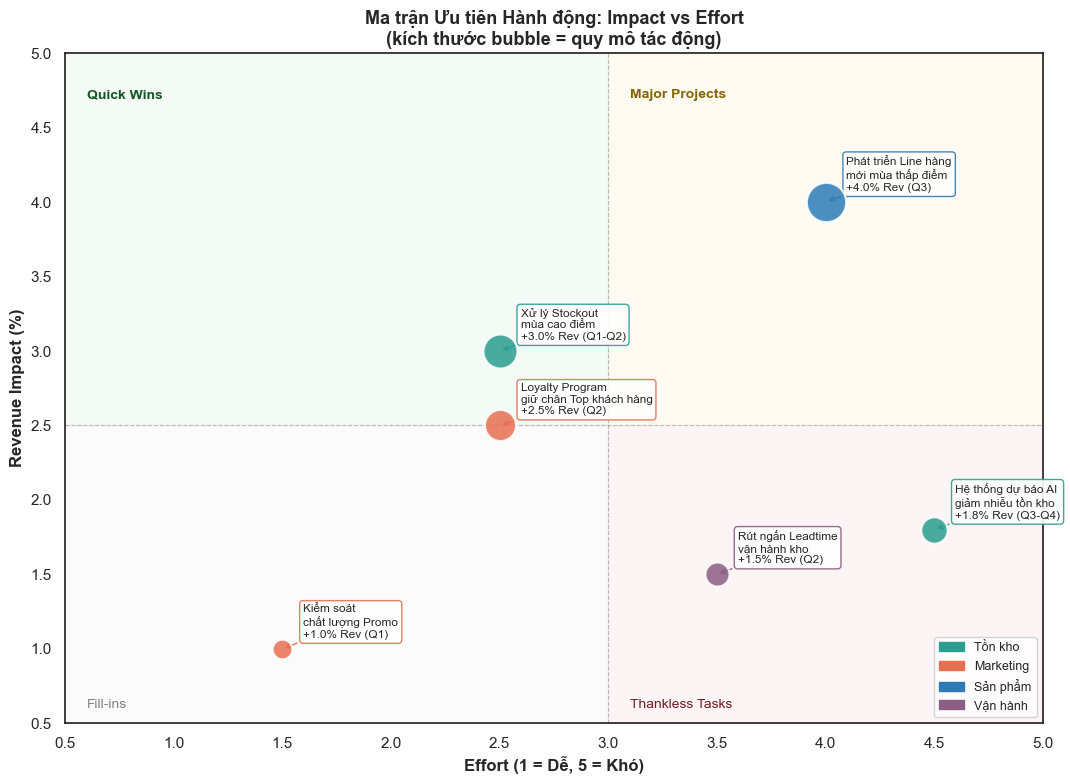


                   ƯU TIÊN HÀNH ĐỘNG                   
Baseline: Doanh thu 1443Tr/năm | Lost sales 6.01%

   QUICK WINS (Ưu tiên làm ngay):
    Xử lý Stockout mùa cao điểm            +3.0% (~43Tr/năm) | Q1-Q2
      Căn cứ: Lost sales=6.0% DT, giảm 50%
    Loyalty Program giữ chân Top khách hàng +2.5% (~36Tr/năm) | Q2
      Căn cứ: Retention cost < Acquisition cost

   MAJOR PROJECTS (Cần lập kế hoạch):
    Phát triển Line hàng mới mùa thấp điểm +4.0% (~58Tr/năm) | Q3
      Căn cứ: Lấp khoảng trống doanh thu mùa thấp điểm
    Hệ thống dự báo AI giảm nhiễu tồn kho  +1.8% (~26Tr/năm) | Q3-Q4
      Căn cứ: Giảm thêm 30% lost sales còn lại
    Rút ngắn Leadtime vận hành kho         +1.5% (~22Tr/năm) | Q2
      Căn cứ: Giảm stockout do chậm nhập hàng

   Tổng tiềm năng nếu thực hiện tất cả: +13.8% (~199 triệu VND/năm)
       Lưu ý: Các tác động có thể overlap, con số thực tế
     thấp hơn do diminishing returns khi triển khai đồng thời.


In [60]:
plot_customer_segment_action_matrix(sales_full, df_inv_monthly)